# NBT small-set preprocessing

This notebook uses the reusable preprocessing pipeline in `src/nbt_pipeline/preprocessing/`.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import pandas as pd

from nbt_pipeline.preprocessing import (
    add_feature_columns,
    blank_like_summary,
    build_preprocessed_dataset,
    cleaning_change_summary,
    clean_dataset,
    column_overview,
    load_nbt_smallset,
    missing_summary,
    procedure_description_mapping_quality,
    time_column_format_summary,
    validate_operation_length_rule,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.2f}".format)

nbt_smallset_df = load_nbt_smallset()
preprocessed_df = build_preprocessed_dataset()
nbt_smallset_df.head()


,TheatreRoom,admission_type,SessionIDdesc,intended_management,actual_proc_1_procedure_code,ProcedureDescription,theatre_notes,ExpectedDurationMins,into_theatre,anaesthetic_start_time,incision,closure,out_of_theatre,operation_end_time,recovery_time,operation_length_mins,sex_national_code,age_at_operation,ASAScore,PriorityLevelCode,anaesthetic_desc,listing_cons_code,theat_surg_1_national_code,theat_anae_1_national_code
0,PLASTIC MINOR 2,11,TH 26 AM P Consultant (Plastic Surgery),2.00,S069,Unspecified other excision of lesion of skin,60mins/day case/LA/ 5mm WLE R abdo scar )(in-situ MM) ....,60.00,00:20:00,00:20:00,00:28:00,00:32:00,09:43:00,00:39:00,00:43:00,19.00,2.00,68.00,1.00,P2,LA (Surgeon),A000012,C4090155,NaN
1,PARKVIEW TH02,11,TH2 (2SD) A Harris (Urology),2.00,M653,Endoscopic resection of prostate NEC,TURP DC GA P3 Xray no Comments = Retention doing ISC....,120.00,00:15:00,00:15:00,00:39:00,00:04:00,NaN,00:47:00,NaN,92.00,1.00,72.00,2.00,P3,LA (Surgeon),C7016369,C7016369,C7042030
2,BRUNEL TH 11,11,TH11(2SD) Mr A Kiszely (Trauma and Orthopaedics),2.00,Z724,Carpal bone NEC,Right Trapeziectomy +/- LRTI 90 mins....,120.00,00:58:00,00:58:00,00:23:00,00:50:00,15:04:00,00:58:00,NaN,60.00,2.00,70.00,2.00,P4,GA,C7136326,C7136326,7038820
3,PLASTIC MINOR 2,11,TH 26 PM P Consultant (Plastic Surgery),2.00,S069,Unspecified other excision of lesion of skin,60mnins/day case/LA/ excision 4mm margin dorsum left hand direct closure (MM? Adnexal tumour?) c+c dorsum left hand...,60.00,00:12:00,00:12:00,00:22:00,00:30:00,14:47:00,00:40:00,00:47:00,28.00,2.00,85.00,2.00,NaN,LA (Surgeon),A000012,C7040583,NaN
4,BRUNEL TH 15,11,TH15 (3SD) H GILBERT (Urology),2.00,M455,Diagnostic endoscopic examination of bladder using rigid cystoscope,Rigid cystoscopy under GA +/- Biopsy DC GA....,48.00,00:51:00,00:51:00,00:06:00,00:17:00,10:20:00,00:18:00,NaN,27.00,2.00,74.00,3.00,P2,GA,C3015366,C3398948,C3492598


## 1. Load the data


In [2]:
data_path = Path("../data/NBT-SmallSet.xlsx")

nbt_smallset_df = pd.read_excel(data_path, sheet_name="Sheet1")


In [3]:
pd.concat([nbt_smallset_df.head(3), nbt_smallset_df.tail(3)])


,TheatreRoom,admission_type,SessionIDdesc,intended_management,actual_proc_1_procedure_code,ProcedureDescription,theatre_notes,ExpectedDurationMins,into_theatre,anaesthetic_start_time,incision,closure,out_of_theatre,operation_end_time,recovery_time,operation_length_mins,sex_national_code,age_at_operation,ASAScore,PriorityLevelCode,anaesthetic_desc,listing_cons_code,theat_surg_1_national_code,theat_anae_1_national_code
0,PLASTIC MINOR 2,11,TH 26 AM P Consultant (Plastic Surgery),2.00,S069,Unspecified other excision of lesion of skin,60mins/day case/LA/ 5mm WLE R abdo scar )(in-situ MM) ....,60.00,00:20:00,00:20:00,00:28:00,00:32:00,09:43:00,00:39:00,00:43:00,19.00,2.00,68.00,1.00,P2,LA (Surgeon),A000012,C4090155,NaN
1,PARKVIEW TH02,11,TH2 (2SD) A Harris (Urology),2.00,M653,Endoscopic resection of prostate NEC,TURP DC GA P3 Xray no Comments = Retention doing ISC....,120.00,00:15:00,00:15:00,00:39:00,00:04:00,NaN,00:47:00,NaN,92.00,1.00,72.00,2.00,P3,LA (Surgeon),C7016369,C7016369,C7042030
2,BRUNEL TH 11,11,TH11(2SD) Mr A Kiszely (Trauma and Orthopaedics),2.00,Z724,Carpal bone NEC,Right Trapeziectomy +/- LRTI 90 mins....,120.00,00:58:00,00:58:00,00:23:00,00:50:00,15:04:00,00:58:00,NaN,60.00,2.00,70.00,2.00,P4,GA,C7136326,C7136326,7038820
14915,PARKVIEW TH02,11,"TH2 (2SD) S,Bolomytis (Urology)",2.00,M455,Diagnostic endoscopic examination of bladder using rigid cystoscope,m45.5 Cystoscopy and bladder biopsies DC....,60.00,00:48:00,00:48:00,00:45:00,00:54:00,NaN,00:00:00,NaN,72.00,1.00,76.00,3.00,P2,GA,C7477113,C7477113,C3467499
14916,PLASTIC MINOR 1,11,TH25 AM P Consultant (Plastic Surgery),2.00,S069,Unspecified other excision of lesion of skin,90mins/day case/LA/ bcc right nasal dorsum side wall excise and local flap/FTSG staff grade PSOP P2 within 2-...,90.00,00:17:00,00:17:00,00:36:00,00:01:00,10:28:00,00:23:00,00:28:00,66.00,1.00,63.00,2.00,P2,LA (Surgeon),A000012,C6156511,NaN
14917,IR LAB 4,12,IR4 Morning / R Consultant (Radiology),2.00,M131,Percutaneous needle biopsy of lesion of kidney,33mm right lower pole tumour being worked up for cryoablation. For histological confirmation....,45.00,00:00:00,00:00:00,00:23:00,00:32:00,10:41:00,00:33:00,NaN,33.00,1.00,72.00,NaN,P2,LA (Surgeon),A000013,C4717339,NaN


## 2. Data dictionary

This section briefly explains the main columns before preprocessing. Some meanings come from NHS Data Dictionary / NHS England sources, while local operational fields are interpreted from the column names and values in this dataset.

| Column | Brief meaning | Source / note |
|---|---|---|
| `TheatreRoom` | Operating theatre room where the case was planned or performed. | Dataset context; related to operating theatre activity. |
| `admission_type` | Code describing the method/type of admission, for example elective waiting list, booked, planned, or emergency admission. | NHS Data Dictionary: Admission Method. |
| `SessionIDdesc` | Text description of the theatre session, often including theatre number, session timing, consultant, or specialty. | Dataset context; related to NHS operating theatre session concepts. |
| `intended_management` | Planned hospital bed use, for example whether the patient is expected to stay overnight or be treated as a day case. | NHS Data Dictionary: Intended Management. |
| `actual_proc_1_procedure_code` | OPCS-4 code for the main procedure/intervention. | NHS England OPCS-4 classification. |
| `ProcedureDescription` | Text description linked to the main OPCS procedure code. | NHS England OPCS-4 classification. |
| `theatre_notes` | Free-text notes entered for the theatre case, sometimes containing procedure details, duration, anaesthetic notes, or special requirements. | Dataset context/local operational notes. |
| `ExpectedDurationMins` | Planned or expected case duration in minutes. | Dataset context. |
| `into_theatre`, `anaesthetic_start_time`, `incision`, `closure`, `out_of_theatre`, `operation_end_time`, `recovery_time` | Theatre pathway timestamps showing when key stages happened. | Dataset context; used to calculate timings and delays. |
| `operation_length_mins` | Recorded operation duration in minutes. | Dataset context. |
| `sex_national_code` | National code for patient sex/gender category, commonly 1 = male and 2 = female in NHS dictionary coding. | NHS Data Dictionary: Person Stated Gender Code / Person Gender Code. |
| `age_at_operation` | Patient age at the time of operation. | Dataset context. |
| `ASAScore` | ASA physical status score, showing patient fitness/comorbidity risk before anaesthesia. | NHS Data Dictionary: ASA Physical Status Classification System Code. |
| `PriorityLevelCode` | Clinical priority code, such as P2, P3, or P4, indicating urgency/timeframe for elective care. | NHS England elective access policy. |
| `anaesthetic_desc` | Description of anaesthetic type, for example general anaesthetic or local anaesthetic. | Dataset context. |
| `listing_cons_code` | Code for the listing consultant. | Dataset context/local staff code. |
| `theat_surg_1_national_code` | Code for the first theatre surgeon. | Dataset context/local or national staff code. |
| `theat_anae_1_national_code` | Code for the first theatre anaesthetist. | Dataset context/local or national staff code. |


## 3. Basic structure


In [4]:
rows, columns = nbt_smallset_df.shape
print(f"Rows: {rows:,}")
print(f"Columns: {columns:,}")


Rows: 14,918
Columns: 24


In [5]:
column_overview = pd.DataFrame({
    "column": nbt_smallset_df.columns,
    "dtype": nbt_smallset_df.dtypes.astype(str).values,
    "non_null": nbt_smallset_df.notna().sum().values,
    "missing": nbt_smallset_df.isna().sum().values,
    "missing_pct": (nbt_smallset_df.isna().mean() * 100).round(2).values,
    "unique_values": nbt_smallset_df.nunique(dropna=True).values,
})

column_overview.sort_values("missing_pct", ascending=False)


,column,dtype,non_null,missing,missing_pct,unique_values
14,recovery_time,object,1768,13150,88.15,60
19,PriorityLevelCode,str,6355,8563,57.40,4
23,theat_anae_1_national_code,object,9512,5406,36.24,323
18,ASAScore,float64,13664,1254,8.41,7
20,anaesthetic_desc,str,14174,744,4.99,7
12,out_of_theatre,object,14321,597,4.00,1193
7,ExpectedDurationMins,float64,14704,214,1.43,189
22,theat_surg_1_national_code,object,14803,115,0.77,390
4,actual_proc_1_procedure_code,str,14828,90,0.60,1038
5,ProcedureDescription,str,14828,90,0.60,1038


### How to read this table

This table gives a quick health check for every column in the dataset.

- `non_null`: how many rows have a real value in that column.
- `missing`: how many rows are empty in that column.
- `missing_pct`: the percentage of rows that are empty. A high value means the column may be less useful or needs cleaning.
- `unique_values`: how many different values appear in that column. This helps us understand whether the column is categorical, repeated, or very detailed.

For example, if a column has high `missing_pct`, we should be careful using it. If it has only a few `unique_values`, it may be useful for grouping or modelling as a category.
\n


In [6]:
nbt_smallset_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 14918 entries, 0 to 14917
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   TheatreRoom                   14918 non-null  str    
 1   admission_type                14916 non-null  object 
 2   SessionIDdesc                 14918 non-null  str    
 3   intended_management           14913 non-null  float64
 4   actual_proc_1_procedure_code  14828 non-null  str    
 5   ProcedureDescription          14828 non-null  str    
 6   theatre_notes                 14842 non-null  str    
 7   ExpectedDurationMins          14704 non-null  float64
 8   into_theatre                  14918 non-null  object 
 9   anaesthetic_start_time        14918 non-null  object 
 10  incision                      14862 non-null  object 
 11  closure                       14845 non-null  object 
 12  out_of_theatre                14321 non-null  object 
 13  operation_en

## 4. Data quality checks


### 4.1 Missing values

This check counts NaN / missing values for every column and calculates the percentage missing. It helps identify columns that may need cleaning or may be too incomplete to use safely.


In [7]:
basic_missing_df = (
    nbt_smallset_df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
basic_missing_df["missing_pct"] = (basic_missing_df["missing_count"] / len(nbt_smallset_df) * 100).round(2)
basic_missing_df.sort_values("missing_pct", ascending=False)


,missing_count,missing_pct
recovery_time,13150,88.15
PriorityLevelCode,8563,57.40
theat_anae_1_national_code,5406,36.24
ASAScore,1254,8.41
anaesthetic_desc,744,4.99
out_of_theatre,597,4.00
ExpectedDurationMins,214,1.43
theat_surg_1_national_code,115,0.77
actual_proc_1_procedure_code,90,0.60
ProcedureDescription,90,0.60


**Result interpretation:** The missing-value summary identifies columns with limited completeness. Variables with high `missing_pct` require caution in later analysis, while columns with low or zero missingness provide more reliable coverage for EDA and modelling preparation.


### 4.2 Duplicate rows

This check looks for full rows that are repeated exactly. Duplicate rows should be reviewed because they can bias counts, summaries, and models if the same case is accidentally included more than once.


In [8]:
duplicate_count = nbt_smallset_df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count:,}")

nbt_smallset_df[nbt_smallset_df.duplicated(keep=False)].sort_values(nbt_smallset_df.columns.tolist()).head(20)


Exact duplicate rows: 6


,TheatreRoom,admission_type,SessionIDdesc,intended_management,actual_proc_1_procedure_code,ProcedureDescription,theatre_notes,ExpectedDurationMins,into_theatre,anaesthetic_start_time,incision,closure,out_of_theatre,operation_end_time,recovery_time,operation_length_mins,sex_national_code,age_at_operation,ASAScore,PriorityLevelCode,anaesthetic_desc,listing_cons_code,theat_surg_1_national_code,theat_anae_1_national_code
5305,CATH LAB 05,24,C Consultant (Cardiology) Elective & Emergency,1.00,K636,Coronary arteriography NEC,83 Direct admission from Echo department with Decompensated HF secondary to severe AS Bilateral Pleural effusion...,54.00,00:35:00,00:35:00,00:51:00,00:06:00,17:29:00,00:13:00,NaN,38.00,1.00,83.00,NaN,NaN,LA (Surgeon),C3289073,A000003,NaN
5382,CATH LAB 05,24,C Consultant (Cardiology) Elective & Emergency,1.00,K636,Coronary arteriography NEC,83 Direct admission from Echo department with Decompensated HF secondary to severe AS Bilateral Pleural effusion...,54.00,00:35:00,00:35:00,00:51:00,00:06:00,17:29:00,00:13:00,NaN,38.00,1.00,83.00,NaN,NaN,LA (Surgeon),C3289073,A000003,NaN
4960,PLASTIC MINOR 2,11,P Consultant (Plastic Surgery),2.00,NaN,NaN,"11:30- P2, Excision biopsy lesion ?MM left back, LA/DC....",60.00,00:54:00,00:54:00,00:01:00,00:10:00,11:13:00,00:11:00,00:13:00,17.00,2.00,31.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
5002,PLASTIC MINOR 2,11,P Consultant (Plastic Surgery),2.00,NaN,NaN,"11:30- P2, Excision biopsy lesion ?MM left back, LA/DC....",60.00,00:54:00,00:54:00,00:01:00,00:10:00,11:13:00,00:11:00,00:13:00,17.00,2.00,31.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
12096,PLASTIC MINOR 2,11,P Consultant (Plastic Surgery),2.00,NaN,NaN,"15:30 - P2, Excision ?Haemangioma ?Bcc ?Amelanotic MM and direct closure leftupper forehead, LA/DC....",60.00,00:29:00,00:29:00,00:29:00,00:55:00,17:00:00,00:55:00,NaN,26.00,2.00,63.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
12116,PLASTIC MINOR 2,11,P Consultant (Plastic Surgery),2.00,NaN,NaN,"15:30 - P2, Excision ?Haemangioma ?Bcc ?Amelanotic MM and direct closure leftupper forehead, LA/DC....",60.00,00:29:00,00:29:00,00:29:00,00:55:00,17:00:00,00:55:00,NaN,26.00,2.00,63.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
4967,PLASTIC MINOR 2,11,TH26 (2SD) P Consultant (Plastic Surgery),2.00,NaN,NaN,"08:30 - Excision ?MM left forarm, LA/DC....",30.00,00:39:00,00:39:00,00:39:00,00:39:00,09:39:00,00:39:00,00:40:00,0.00,2.00,73.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
5045,PLASTIC MINOR 2,11,TH26 (2SD) P Consultant (Plastic Surgery),2.00,NaN,NaN,"08:30 - Excision ?MM left forarm, LA/DC....",30.00,00:39:00,00:39:00,00:39:00,00:39:00,09:39:00,00:39:00,00:40:00,0.00,2.00,73.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
10056,PLASTIC MINOR 2,11,TH26 2SD KPI P Consultant (Plastic Surgery),2.00,NaN,NaN,Excision ?SCC left forearm 30 minutes LA....,30.00,00:15:00,00:15:00,00:18:00,00:38:00,15:46:00,00:40:00,00:46:00,25.00,2.00,85.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
10152,PLASTIC MINOR 2,11,TH26 2SD KPI P Consultant (Plastic Surgery),2.00,NaN,NaN,Excision ?SCC left forearm 30 minutes LA....,30.00,00:15:00,00:15:00,00:18:00,00:38:00,15:46:00,00:40:00,00:46:00,25.00,2.00,85.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN


**Result interpretation:** The duplicate-row check reports whether complete records are repeated. Any duplicated rows should be reviewed before removal, as repeated records may represent either true repeated activity or accidental duplication.


### 4.3 Blank-like text values

This check looks for text values that are not true NaN but still behave like missing information, such as empty strings or single dots. These values may need to be converted to missing values during cleaning.


In [9]:
text_columns = nbt_smallset_df.select_dtypes(include="object").columns

blank_like_summary = []
for column in text_columns:
    cleaned = nbt_smallset_df[column].astype("string").str.strip()
    blank_like_summary.append({
        "column": column,
        "empty_strings": (cleaned == "").sum(),
        "single_dots": (cleaned == ".").sum(),
        "unique_values": cleaned.nunique(dropna=True),
    })

pd.DataFrame(blank_like_summary).sort_values(["single_dots", "empty_strings"], ascending=False)


C:\Users\Alaa\AppData\Local\Temp\ipykernel_42668\2297323768.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = nbt_smallset_df.select_dtypes(include="object").columns


,column,empty_strings,single_dots,unique_values
5,theatre_notes,0,2488,9765
0,TheatreRoom,0,0,45
1,admission_type,0,0,16
2,SessionIDdesc,0,0,2281
3,actual_proc_1_procedure_code,0,0,1038
4,ProcedureDescription,0,0,1038
6,into_theatre,0,0,69
7,anaesthetic_start_time,0,0,69
8,incision,0,0,67
9,closure,0,0,69


**Result interpretation:** This check identifies text values that behave like missing data but are not stored as `NaN`, such as empty strings or single dots. These values should be documented and converted only where the meaning is unambiguous.


## 5. Numeric variable inspection


Before inspecting variables, it is important to use the meaning of the column, not only the pandas data type. Some columns are stored as numbers but actually represent categories or codes. For example, ASAScore, sex_national_code, admission_type, and intended_management are coded variables, so they are inspected in the categorical/coded section rather than using numeric averages.


### 5.1 Summary statistics

This table summarises the true numeric measurement columns using count, mean, standard deviation, minimum, quartiles, and maximum. These checks are useful for continuous measurements such as planned duration, actual operation length, and patient age.


In [10]:
numeric_columns = [
    "ExpectedDurationMins",
    "operation_length_mins",
    "age_at_operation",
]

nbt_smallset_df[numeric_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
ExpectedDurationMins,14704.00,98.28,88.53,0.00,60.00,60.00,120.00,1415.00
operation_length_mins,14845.00,97.89,92.50,0.00,39.00,70.00,124.00,1017.00
age_at_operation,14872.00,57.07,19.59,16.00,40.00,59.00,73.00,107.00


**Result interpretation:** The numeric summary describes the range and spread of the main continuous variables. `ExpectedDurationMins` and `operation_length_mins` support planned-versus-actual theatre-time analysis, while `age_at_operation` describes the patient population and helps identify implausible values.


### 5.2 Suspicious numeric values

This check counts values that may be impossible or suspicious for true numeric columns, such as zero duration, age equal to zero, negative age, or age above 125.


In [11]:
numeric_quality_checks = pd.DataFrame({
    "zero_expected_duration": [(nbt_smallset_df["ExpectedDurationMins"] == 0).sum()],
    "zero_operation_length": [(nbt_smallset_df["operation_length_mins"] == 0).sum()],
    "age_zero": [(nbt_smallset_df["age_at_operation"] == 0).sum()],
    "age_negative": [(nbt_smallset_df["age_at_operation"] < 0).sum()],
    "age_over_125": [(nbt_smallset_df["age_at_operation"] > 125).sum()],
})

numeric_quality_checks.T.rename(columns={0: "row_count"})


,row_count
zero_expected_duration,62
zero_operation_length,9
age_zero,0
age_negative,0
age_over_125,0


**Result interpretation:** The suspicious-value check highlights values that may be impossible or unsafe for analysis. Zero or negative durations and implausible age values should be reviewed and converted to missing values where they clearly represent data-quality issues.


### 5.3 Planned versus actual duration in minutes

This creates duration_error_mins, which compares the recorded operation length with the expected duration. Positive values mean the case took longer than planned; negative values mean it finished faster than planned. Median is included because duration data often has outliers, so the median can describe the typical case better than the mean.


In [12]:
duration_df = nbt_smallset_df.copy()
duration_df["duration_error_mins"] = duration_df["operation_length_mins"] - duration_df["ExpectedDurationMins"]

duration_summary = duration_df[["ExpectedDurationMins", "operation_length_mins", "duration_error_mins"]].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max",
]).T

duration_summary


,count,mean,median,std,min,max
ExpectedDurationMins,14704.00,98.28,60.00,88.53,0.00,1415.00
operation_length_mins,14845.00,97.89,70.00,92.50,0.00,1017.00
duration_error_mins,14632.00,-0.15,-8.00,69.13,-1399.00,970.00


**Result interpretation:** `duration_error_mins` compares actual operation length with expected duration. Positive values indicate cases longer than planned, while negative values indicate shorter-than-planned cases. The median values suggest typical cases finish slightly below the planned duration, although extreme minimum and maximum errors indicate outliers requiring review.


### 5.4 Largest duration overruns

This table shows the operations with the biggest positive duration_error_mins. In simple words, these are the cases where the actual operation length was much longer than the expected duration.

Formula: duration_error_mins = operation_length_mins - ExpectedDurationMins


In [13]:
duration_df[
    ["TheatreRoom", "ProcedureDescription", "ExpectedDurationMins", "operation_length_mins", "duration_error_mins"]
].sort_values("duration_error_mins", ascending=False).head(10)


,TheatreRoom,ProcedureDescription,ExpectedDurationMins,operation_length_mins,duration_error_mins
5582,IR LAB 3,Open embolectomy of cerebral artery,0.00,970.00,970.00
8103,BRUNEL TH 06,Unspecified opening of cranium,150.00,1017.00,867.00
9121,BRUNEL TH 07,Posterior fusion of joint of cervical spine NEC,180.00,971.00,791.00
8273,GYNAE TH 01,Elective lower uterine segment caesarean delivery,60.00,790.00,730.00
2317,BRUNEL TH 06,Other specified extirpation of lesion of meninges of brain,150.00,779.00,629.00
6969,BRUNEL TH 01,Debridement of burnt skin of head or neck,60.00,680.00,620.00
9522,BRUNEL TH 04,Shaft of tibia NEC,90.00,655.00,565.00
13037,BRUNEL TH 04,Left sided operation,60.00,586.00,526.00
13448,BRUNEL TH 09,Primary total prosthetic replacement of hip joint using cement,120.00,642.00,522.00
13504,BRUNEL TH 09,Primary total prosthetic replacement of hip joint using cement,120.00,642.00,522.00


**Result interpretation:** The largest positive duration errors identify cases that substantially exceeded their planned duration. These records may represent complex procedures, underestimated planned durations, or data-quality issues, so they should be inspected before modelling rather than removed automatically.


## 6. Categorical and coded variable inspection


### 6.1 Categorical overview

This table checks categorical and coded columns using unique values, missing counts, and missing percentages. It helps identify columns with many categories, such as procedure descriptions, and columns with high missingness, such as priority level or anaesthetist code.


In [14]:
categorical_columns = [
    "TheatreRoom",
    "admission_type",
    "intended_management",
    "sex_national_code",
    "ASAScore",
    "SessionIDdesc",
    "actual_proc_1_procedure_code",
    "ProcedureDescription",
    "PriorityLevelCode",
    "anaesthetic_desc",
    "listing_cons_code",
    "theat_surg_1_national_code",
    "theat_anae_1_national_code",
]

pd.DataFrame({
    "unique_values": nbt_smallset_df[categorical_columns].nunique(dropna=True),
    "missing_count": nbt_smallset_df[categorical_columns].isna().sum(),
    "missing_pct": (nbt_smallset_df[categorical_columns].isna().mean() * 100).round(2),
}).sort_values("unique_values", ascending=False)


,unique_values,missing_count,missing_pct
SessionIDdesc,2288,0,0.00
actual_proc_1_procedure_code,1038,90,0.60
ProcedureDescription,1038,90,0.60
theat_surg_1_national_code,390,115,0.77
theat_anae_1_national_code,323,5406,36.24
listing_cons_code,283,77,0.52
TheatreRoom,45,0,0.00
admission_type,16,2,0.01
ASAScore,7,1254,8.41
anaesthetic_desc,7,744,4.99


**Result interpretation:** The categorical overview shows a mix of low-cardinality operational fields and high-cardinality text/code fields. `TheatreRoom` is suitable for location-based analysis, while fields such as `SessionIDdesc`, `ProcedureDescription`, and `actual_proc_1_procedure_code` require grouping or feature extraction before modelling.


### 6.2 Coded categorical variables

Some columns look numeric but are actually categories or ordered codes. For these columns, value counts are more useful than mean or standard deviation.


### 6.2.1 Meaning of key coded variables

The table below explains the main coded variables used in this dataset. These meanings are based on NHS Data Dictionary / NHS England sources where available, with project labels used to keep the codes readable.

| Column | Codes / meaning |
|---|---|
| admission_type | 11 = elective waiting list; 12 = elective booked; 13 = elective planned; 21-25 and 2A-2D = emergency admission routes; 31-32 = maternity admission; 81-83 = other admission/transfer/birth routes; 98 = not applicable. |
| intended_management | 1 = inpatient; 2 = day case; 3 = regular day attender; 4 = regular night attender; 5 = mother and baby; 8 = not applicable; 9 = not known. |
| sex_national_code | 1 = male; 2 = female. Other NHS dictionary versions may also include 9 or X for indeterminate/not known, but this dataset mainly contains 1 and 2. |
| ASAScore | 1-6 ASA physical status category. 1 is healthiest; higher values mean greater physical/anaesthetic risk; 6 is brain-dead organ donor. |
| PriorityLevelCode | P1 = highest/most urgent priority; P2 = high priority; P3 = medium priority; P4 = routine or lower priority. |

These columns should be analysed using counts and validity checks, not numeric averages.

Detailed source entries for these code meanings are listed in the References section at the end of the notebook.


### 6.2.2 Code frequency counts

This code counts how often each code or category appears in the selected coded variables. This is better than calculating averages because these values represent groups, not continuous measurements.


In [15]:
coded_category_columns = [
    "admission_type",
    "intended_management",
    "sex_national_code",
    "ASAScore",
    "PriorityLevelCode",
]

for column in coded_category_columns:
    print(f"Top values for {column}")
    display(nbt_smallset_df[column].value_counts(dropna=False).head(10).to_frame("count"))


Top values for admission_type


,count
admission_type,
11,7780
21,2480
12,1592
13,975
31,714
22,438
2D,281
2A,267
24,233


Top values for intended_management


,count
intended_management,
1.00,7599
2.00,7108
8.00,169
3.00,31
5.00,5
NaN,5
4.00,1


Top values for sex_national_code


,count
sex_national_code,
2.00,7825
1.00,7047
NaN,46


Top values for ASAScore


,count
ASAScore,
2.00,6219
3.00,4241
1.00,2424
NaN,1254
4.00,723
5.00,35
6.00,21
0.00,1


Top values for PriorityLevelCode


,count
PriorityLevelCode,
NaN,8563
P2,3714
P3,1521
P4,1119
P1,1


**Result interpretation:** The coded-category summary shows that elective waiting-list activity is the largest admission route, with emergency routes also represented. `intended_management` is mainly split between inpatient and day-case activity. `PriorityLevelCode` has substantial missingness and should not be interpreted as a recorded priority category when blank.


### 6.2.3 Main procedure code inspection

`actual_proc_1_procedure_code` is a coded categorical column. It contains the main OPCS procedure code for the operation. Even though the codes contain numbers, they are not measurements, so we inspect them using missing values, unique counts, and frequency counts.

This is useful because procedure type is likely to affect operation duration, theatre use, and later modelling.


In [16]:
procedure_code_summary = pd.DataFrame(
    {
        "column": ["actual_proc_1_procedure_code"],
        "missing_count": [nbt_smallset_df["actual_proc_1_procedure_code"].isna().sum()],
        "missing_pct": [(nbt_smallset_df["actual_proc_1_procedure_code"].isna().mean() * 100).round(2)],
        "unique_values": [nbt_smallset_df["actual_proc_1_procedure_code"].nunique(dropna=True)],
    }
)

procedure_code_summary


,column,missing_count,missing_pct,unique_values
0,actual_proc_1_procedure_code,90,0.60,1038


**Result interpretation:** The procedure-code field is highly complete, with only 90 missing values (0.60%) and 1,038 unique codes. This level of detail is useful for procedure-type analysis, but the high cardinality supports deriving broader procedure groups for EDA and modelling.


The next table shows the most common procedure codes together with their procedure descriptions. This is easier to interpret than looking at the code alone.


In [17]:
top_procedure_codes = (
    nbt_smallset_df[
        ["actual_proc_1_procedure_code", "ProcedureDescription"]
    ]
    .value_counts(dropna=False)
    .head(20)
    .reset_index(name="count")
)

top_procedure_codes


,actual_proc_1_procedure_code,ProcedureDescription,count
0,S069,Unspecified other excision of lesion of skin,1423
1,R172,Elective lower uterine segment caesarean delivery,633
2,Y808,Other specified general anaesthetic,326
3,K636,Coronary arteriography NEC,278
4,R182,Lower uterine segment caesarean delivery NEC,259
5,M162,Maintenance of drainage tube of kidney,223
6,S571,Debridement of skin NEC,215
7,J183,Total cholecystectomy NEC,181
8,L711,Percutaneous transluminal angioplasty of artery,178
9,M611,Total excision of prostate and capsule of prostate,173


The next check tests whether non-missing procedure codes follow the expected stored format in this dataset: one letter followed by three digits, for example `S069`. This is a format check, not full official OPCS validation.


In [18]:
procedure_code_text = nbt_smallset_df["actual_proc_1_procedure_code"].astype("string").str.strip().str.upper()

procedure_code_format_quality = pd.DataFrame(
    {
        "total_rows": [len(nbt_smallset_df)],
        "missing_codes": [procedure_code_text.isna().sum()],
        "valid_format_codes": [procedure_code_text.str.fullmatch(r"[A-Z]\d{3}").fillna(False).sum()],
        "invalid_format_codes": [
            (~procedure_code_text.str.fullmatch(r"[A-Z]\d{3}").fillna(False) & procedure_code_text.notna()).sum()
        ],
    }
)

procedure_code_length_counts = (
    procedure_code_text
    .dropna()
    .str.len()
    .value_counts()
    .sort_index()
    .rename_axis("code_length")
    .reset_index(name="count")
)

invalid_procedure_code_examples = (
    nbt_smallset_df.loc[
        ~procedure_code_text.str.fullmatch(r"[A-Z]\d{3}").fillna(False) & procedure_code_text.notna(),
        ["actual_proc_1_procedure_code", "ProcedureDescription"],
    ]
    .drop_duplicates()
    .head(20)
)

print("Procedure code format quality")
display(procedure_code_format_quality)

print("Procedure code length counts")
display(procedure_code_length_counts)

print("Invalid-format procedure code examples")
display(invalid_procedure_code_examples)


Procedure code format quality


,total_rows,missing_codes,valid_format_codes,invalid_format_codes
0,14918,90,14828,0


Procedure code length counts


,code_length,count
0,4,14828


Invalid-format procedure code examples


,actual_proc_1_procedure_code,ProcedureDescription


**Result interpretation:** The procedure-code format check shows that all non-missing codes follow the expected stored pattern of one letter and three digits. This supports structural grouping, although it does not confirm official validity against a full OPCS dictionary.


This final check looks for procedure codes that appear with more than one description. A code may have several descriptions because of spelling, punctuation, or local wording differences. These are not automatically wrong, but they should be reviewed before grouping procedures.


In [19]:
procedure_description_consistency = (
    nbt_smallset_df
    .dropna(subset=["actual_proc_1_procedure_code"])
    .groupby("actual_proc_1_procedure_code")["ProcedureDescription"]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .to_frame("unique_descriptions")
)

procedure_description_consistency.head(20)


,unique_descriptions
actual_proc_1_procedure_code,
A012,1
A021,1
A022,1
A023,1
A024,1
A025,1
A028,1
A042,1
A051,1


The previous check looks only in one direction: whether one procedure code has multiple descriptions. The next check looks in both directions. It checks whether one code maps to many descriptions, and whether one description maps to many codes. This is useful because both patterns can create ambiguity before modelling.


In [20]:
procedure_mapping_quality = procedure_description_mapping_quality(nbt_smallset_df)

codes_with_multiple_descriptions = procedure_mapping_quality["codes_with_multiple_descriptions"]
descriptions_with_multiple_codes = procedure_mapping_quality["descriptions_with_multiple_codes"]

print("Procedure codes with multiple descriptions")
display(codes_with_multiple_descriptions.head(20))

print("Procedure descriptions with multiple codes")
display(descriptions_with_multiple_codes.head(20))


Procedure codes with multiple descriptions


,procedure_code,unique_descriptions,row_count,descriptions


Procedure descriptions with multiple codes


,procedure_description,unique_codes,row_count,codes


In [21]:
procedure_mapping_issue_summary = pd.DataFrame(
    {
        "quality_check": [
            "codes_with_multiple_descriptions",
            "descriptions_with_multiple_codes",
        ],
        "affected_unique_values": [
            len(codes_with_multiple_descriptions),
            len(descriptions_with_multiple_codes),
        ],
    }
)

procedure_mapping_issue_summary


,quality_check,affected_unique_values
0,codes_with_multiple_descriptions,0
1,descriptions_with_multiple_codes,0


**Result interpretation:** The code-description mapping check found no internal ambiguity: no procedure code maps to multiple descriptions and no description maps to multiple codes. This indicates consistent coding within this dataset, while retaining reusable checks for future datasets.


This check focuses only on rows where `actual_proc_1_procedure_code` is missing. It tests whether `ProcedureDescription` is available in those rows and could be used to recover the missing code.


In [22]:
missing_procedure_code = nbt_smallset_df["actual_proc_1_procedure_code"].isna()

procedure_missing_recovery_check = pd.DataFrame(
    {
        "missing_procedure_code_rows": [missing_procedure_code.sum()],
        "procedure_description_missing": [
            nbt_smallset_df.loc[missing_procedure_code, "ProcedureDescription"].isna().sum()
        ],
        "procedure_description_present": [
            nbt_smallset_df.loc[missing_procedure_code, "ProcedureDescription"].notna().sum()
        ],
    }
)

procedure_missing_recovery_check


,missing_procedure_code_rows,procedure_description_missing,procedure_description_present
0,90,90,0


In [23]:
nbt_smallset_df.loc[
    missing_procedure_code,
    ["actual_proc_1_procedure_code", "ProcedureDescription"],
].value_counts(dropna=False).reset_index(name="count")


,actual_proc_1_procedure_code,ProcedureDescription,count
0,NaN,NaN,90


**Result interpretation:** Missing procedure-code records also lack procedure descriptions, so `ProcedureDescription` cannot be used to recover those missing codes. These records should remain missing unless a validated external coding source becomes available.


**Result interpretation:** Overall, the procedure-code field is suitable for analysis: it is highly complete, consistently formatted, and internally consistent with the description field. The main limitation is high cardinality, making broader features such as `procedure_code_chapter` and `procedure_code_group` more stable for EDA and modelling.


### 6.2.4 Staff code inspection

`listing_cons_code`, `theat_surg_1_national_code`, and `theat_anae_1_national_code` are staff/code identifier columns. They should be treated as categorical IDs, not numeric variables.

This inspection checks how complete they are and how many different staff codes appear. This matters because high-cardinality staff codes can be useful for workload analysis, but they may be difficult to use directly in modelling.


In [24]:
staff_code_columns = [
    "listing_cons_code",
    "theat_surg_1_national_code",
    "theat_anae_1_national_code",
]

staff_code_summary = pd.DataFrame(
    {
        "unique_values": nbt_smallset_df[staff_code_columns].nunique(dropna=True),
        "missing_count": nbt_smallset_df[staff_code_columns].isna().sum(),
        "missing_pct": (nbt_smallset_df[staff_code_columns].isna().mean() * 100).round(2),
    }
).sort_values("missing_pct", ascending=False)

staff_code_summary


,unique_values,missing_count,missing_pct
theat_anae_1_national_code,323,5406,36.24
theat_surg_1_national_code,390,115,0.77
listing_cons_code,283,77,0.52


The next output shows the most common values in each staff-code column. This is useful for identifying whether a small number of staff codes dominate the dataset or whether cases are spread across many codes.


In [25]:
for column in staff_code_columns:
    print(f"Top values for {column}")
    display(nbt_smallset_df[column].value_counts(dropna=False).head(10).to_frame("count"))


Top values for listing_cons_code


,count
listing_cons_code,
A000012,2172
A000013,1949
A000001,1405
A000010,878
A000015,728
A000003,205
C3015366,136
C3613441,107
A000018,103


Top values for theat_surg_1_national_code


,count
theat_surg_1_national_code,
C3325111,451
C4406129,390
C6053636,285
X000001,283
C6102738,277
C6106690,264
C4717339,223
A000003,204
C6156511,181


Top values for theat_anae_1_national_code


,count
theat_anae_1_national_code,
NaN,5406
walt03s,199
C3549672,148
4693819,148
C3486959,146
C6050872,130
C4306913,127
NB01049,127
C4018748,123


**Result interpretation:** The staff-code columns are categorical identifiers. `listing_cons_code` and `theat_surg_1_national_code` are mostly complete, while `theat_anae_1_national_code` has substantial missingness and should be used cautiously in later analysis.


### 6.3 Coded category validity checks

For coded variables, we check whether the recorded codes fall inside the expected code lists. This is different from calculating averages. It helps find unexpected codes that may need recoding, investigation, or conversion to missing values.


In [26]:
from nbt_pipeline.preprocessing.codes import coded_value_quality

coded_value_quality(nbt_smallset_df)


,column,missing_count,invalid_count,invalid_values,valid_values
0,admission_type,2,0,,"11, 12, 13, 21, 22, 23, 24, 25, 2A, 2B, 2C, 2D, 31, 32, 81, 82, 83, 98"
1,intended_management,5,0,,"1, 2, 3, 4, 5, 8, 9"
2,sex_national_code,46,0,,"1, 2"
3,ASAScore,1254,1,0,"1, 2, 3, 4, 5, 6"
4,PriorityLevelCode,8563,0,,"P1, P2, P3, P4"


**Result interpretation:** Most coded columns contain only expected recorded values. The main coded-quality issue is missingness, particularly in `PriorityLevelCode`; `ASAScore` contains one invalid value (`0`), which should be converted to missing during cleaning.


### 6.4 Most common text categories

This output shows the most frequent values for selected text columns. It helps identify the busiest theatre rooms, most common procedures, and most common anaesthetic descriptions.


In [27]:
for column in ["TheatreRoom", "ProcedureDescription", "anaesthetic_desc"]:
    print(f"Top values for {column}")
    display(nbt_smallset_df[column].value_counts(dropna=False).head(10).to_frame("count"))


Top values for TheatreRoom


,count
TheatreRoom,
BRUNEL TH 05,706
PLASTIC MINOR 1,651
IR LAB 1,631
GYNAE TH 02,621
IR LAB 2,551
CATH LAB 05,524
PLASTIC MINOR 2,523
BRUNEL TH 03,520
BRUNEL TH 06,516


Top values for ProcedureDescription


,count
ProcedureDescription,
Unspecified other excision of lesion of skin,1423
Elective lower uterine segment caesarean delivery,633
Other specified general anaesthetic,326
Coronary arteriography NEC,278
Lower uterine segment caesarean delivery NEC,259
Maintenance of drainage tube of kidney,223
Debridement of skin NEC,215
Total cholecystectomy NEC,181
Percutaneous transluminal angioplasty of artery,178


Top values for anaesthetic_desc


,count
anaesthetic_desc,
GA,8192
LA (Surgeon),4113
NaN,744
Neuraxial Block,655
No Anaesthetic,460
Sedation,307
GA and Regional,307
Regional Only,140


The next check focuses on `anaesthetic_desc`. This column is a small text category rather than a numeric value, so we inspect missingness, the number of categories, and the full list of observed values.


In [28]:
anaesthetic_quality_summary = pd.DataFrame(
    {
        "column": ["anaesthetic_desc"],
        "missing_count": [nbt_smallset_df["anaesthetic_desc"].isna().sum()],
        "missing_pct": [(nbt_smallset_df["anaesthetic_desc"].isna().mean() * 100).round(2)],
        "unique_values": [nbt_smallset_df["anaesthetic_desc"].nunique(dropna=True)],
    }
)

anaesthetic_values = (
    nbt_smallset_df["anaesthetic_desc"]
    .astype("string")
    .fillna("Missing")
    .value_counts()
    .rename_axis("anaesthetic_desc")
    .reset_index(name="count")
)

print("Anaesthetic description quality summary")
display(anaesthetic_quality_summary)

print("All observed anaesthetic descriptions")
display(anaesthetic_values)


Anaesthetic description quality summary


,column,missing_count,missing_pct,unique_values
0,anaesthetic_desc,744,4.99,7


All observed anaesthetic descriptions


,anaesthetic_desc,count
0,GA,8192
1,LA (Surgeon),4113
2,Missing,744
3,Neuraxial Block,655
4,No Anaesthetic,460
5,Sedation,307
6,GA and Regional,307
7,Regional Only,140


**Result interpretation:** `anaesthetic_desc` is a useful categorical variable with a small number of recorded categories. `GA` and `LA (Surgeon)` dominate the distribution, while less frequent categories should be retained for EDA but interpreted cautiously due to smaller case counts.


**Result interpretation:** The text-category counts identify dominant operational categories. High-volume theatre rooms, common procedure descriptions, and common anaesthetic types may strongly influence aggregate duration summaries, so grouped analyses should account for category size.


## 7. Feature extraction

This section creates new analysis features from columns that contain useful information inside codes or structured text. The goal is not to delete or overwrite the original columns. Instead, the original values are kept and extra features are added to make later EDA and modelling more stable and interpretable.


### 7.1 Procedure code feature extraction

The full `actual_proc_1_procedure_code` is the exact OPCS-4 procedure code, and it should be kept because it identifies the specific operation. However, the column has 1,038 unique values, so using the full code directly can create many small groups. To support more stable EDA and modelling, broader procedure-code features are extracted from the code structure. OPCS-4 is the NHS classification used for procedures and interventions, with official code files published through NHS clinical-classification sources (NHS England Digital, n.d.; NHS England, n.d.b).

| New column | What it shows | Example from `S069` |
|---|---|---|
| `procedure_code_chapter` | First letter of the procedure code; broadest grouping. | `S` |
| `procedure_code_group` | First letter plus first digit; broader procedure family. | `S0` |

The quality checks for code format and code-description mapping are kept in Section 6 because they are validation checks, not modelling features. The final extracted dataset keeps the useful grouping columns while retaining the original full procedure code and description for detailed review.


In [29]:
procedure_feature_columns = [
    "actual_proc_1_procedure_code",
    "ProcedureDescription",
    "procedure_code_chapter",
    "procedure_code_group",
]

procedure_feature_df = add_feature_columns(nbt_smallset_df)
procedure_feature_df[procedure_feature_columns].head(15)


,actual_proc_1_procedure_code,ProcedureDescription,procedure_code_chapter,procedure_code_group
0,S069,Unspecified other excision of lesion of skin,S,S0
1,M653,Endoscopic resection of prostate NEC,M,M6
2,Z724,Carpal bone NEC,Z,Z7
3,S069,Unspecified other excision of lesion of skin,S,S0
4,M455,Diagnostic endoscopic examination of bladder using rigid cystoscope,M,M4
5,Z779,Tibia NEC,Z,Z7
6,G215,Insertion of stent into oesophagus NEC,G,G2
7,T962,Excision of lesion of soft tissue NEC,T,T9
8,A642,Primary repair of peripheral nerve NEC,A,A6
9,Y808,Other specified general anaesthetic,Y,Y8


In [30]:
print("Procedure-code chapter counts")
display(
    procedure_feature_df["procedure_code_chapter"]
    .value_counts(dropna=False)
    .head(15)
    .to_frame("count")
)

print("Procedure-code group counts")
display(
    procedure_feature_df["procedure_code_group"]
    .value_counts(dropna=False)
    .head(20)
    .to_frame("count")
)


Procedure-code chapter counts


,count
procedure_code_chapter,
S,2256
M,1723
W,1552
R,1110
L,1021
T,888
Y,790
Q,739
A,733


Procedure-code group counts


,count
procedure_code_group,
S0,1437
R1,899
Q1,511
W2,503
M4,459
K6,449
S5,429
M1,390
L7,383


**Result interpretation:** The extracted procedure-code features reduce the granularity of the original procedure code while preserving the full code. `procedure_code_chapter` and `procedure_code_group` provide broader categories for comparing duration, overrun, and underrun patterns across procedure families.


### 7.2 Session description feature extraction

`SessionIDdesc` contains several useful pieces of information inside one text column. We extract these using regular expressions in the reusable preprocessing pipeline, not manually in the notebook.

The new columns show:

| New column | What it shows | Example |
|---|---|---|
| `session_theatre_code` | The theatre or session code at the start of the text. | `TH26`, `TH2`, `IR1` |
| `session_code_prefix` | The letter prefix from the session code. | `TH`, `TTH`, `IR`, `CT` |
| `session_list_type` | The list/session marker written in the description. This may show the type of theatre list. | `AM`, `PM`, `EVE`, `2SD`, `3SD`, `PM/EVE` |
| `session_time_band` | A simpler time group extracted from the text. | `AM`, `PM`, `EVE` |
| `session_consultant` | The consultant or list holder name/text after removing theatre code, list marker, and specialty. | `A Harris`, `Mr A Kiszely`, `P Consultant` |
| `session_specialty` | The clinical specialty normalised into a cleaner label. | `Urology`, `Plastic surgery`, `T&O` |

This step is useful because it turns one messy text column into structured columns that can be used for grouping, analysis, and modelling.


In [31]:
from importlib import reload

from nbt_pipeline.preprocessing import build_preprocessed_dataset
import nbt_pipeline.preprocessing.session as session_module
import nbt_pipeline.preprocessing.specialty as specialty_module

reload(session_module)
reload(specialty_module)

if "preprocessed_df" not in globals():
    preprocessed_df = build_preprocessed_dataset()

session_df = session_module.add_session_description_features(preprocessed_df)
session_df = specialty_module.add_specialty_column(session_df)

session_feature_columns = [
    "SessionIDdesc",
    "session_theatre_code",
    "session_code_prefix",
    "session_list_type",
    "session_time_band",
    "session_consultant",
    "session_specialty",
]

session_df[session_feature_columns].head(15)


,SessionIDdesc,session_theatre_code,session_code_prefix,session_list_type,session_time_band,session_consultant,session_specialty
0,TH 26 AM P Consultant (Plastic Surgery),TH26,TH,AM,AM,P Consultant,Plastic surgery
1,TH2 (2SD) A Harris (Urology),TH2,TH,2SD,NaN,A Harris,Urology
2,TH11(2SD) Mr A Kiszely (Trauma and Orthopaedics),TH11,TH,2SD,NaN,Mr A Kiszely,T&O
3,TH 26 PM P Consultant (Plastic Surgery),TH26,TH,PM,PM,P Consultant,Plastic surgery
4,TH15 (3SD) H GILBERT (Urology),TH15,TH,3SD,NaN,H GILBERT,Urology
5,TH23 (3SD) Mr J Murray (Trauma and Orthopaedics),TH23,TH,3SD,NaN,Mr J Murray,T&O
6,IR1 Morning / R Consultant (Radiology),IR1,IR,AM,AM,R Consultant,Radiology
7,TH11 (EVE) Mr T Chapman (Plastic Surgery),TH11,TH,EVE,EVE,Mr T Chapman,Plastic surgery
8,TH 2 (2SD) P Consultant (Plastic Surgery),TH2,TH,2SD,NaN,P Consultant,Plastic surgery
9,TH12 (2SD) F.Boriani (Plastic Surgery),TH12,TH,2SD,NaN,F.Boriani,Plastic surgery


**Result interpretation:** The extracted session fields retain the original `SessionIDdesc` while separating structured components where possible. Missing extracted values indicate that the relevant pattern was not clearly present in the source text.


### 7.3 Quality check for extracted session columns

After creating new columns from `SessionIDdesc`, we check them again. This tells us which extracted features are complete enough to trust and which ones have many missing values.


In [32]:
from importlib import reload

import nbt_pipeline.preprocessing.session as session_module
import nbt_pipeline.preprocessing.specialty as specialty_module

reload(session_module)
reload(specialty_module)

if "preprocessed_df" not in globals():
    preprocessed_df = build_preprocessed_dataset()

session_df = session_module.add_session_description_features(preprocessed_df)
session_df = specialty_module.add_specialty_column(session_df)

session_extracted_columns = [
    "session_theatre_code",
    "session_code_prefix",
    "session_list_type",
    "session_time_band",
    "session_consultant",
    "session_specialty",
]

pd.DataFrame(
    {
        "column": session_extracted_columns,
        "non_null": [session_df[column].notna().sum() for column in session_extracted_columns],
        "missing": [session_df[column].isna().sum() for column in session_extracted_columns],
        "missing_pct": [session_df[column].isna().mean() * 100 for column in session_extracted_columns],
        "unique_values": [session_df[column].nunique(dropna=True) for column in session_extracted_columns],
    }
)


,column,non_null,missing,missing_pct,unique_values
0,session_theatre_code,13806,1112,7.45,36
1,session_code_prefix,13806,1112,7.45,4
2,session_list_type,11601,3317,22.23,6
3,session_time_band,4915,10003,67.05,3
4,session_consultant,14911,7,0.05,552
5,session_specialty,14918,0,0.00,269


**Result interpretation:** Missingness in extracted session fields reflects how consistently the information is recorded in `SessionIDdesc`. Columns with low missingness are stronger candidates for analysis, while high-missingness fields require cautious interpretation.


### 7.4 Comparing session consultant with staff codes

`session_consultant` is extracted from the text in `SessionIDdesc`, while `listing_cons_code`, `theat_surg_1_national_code`, and `theat_anae_1_national_code` are coded staff identifiers from the dataset.

This check does not prove that the columns identify the same person, because one column contains names/text and the others contain codes. However, it helps inspect whether the extracted consultant text is related to the staff-code fields and whether it may duplicate information already present elsewhere.


In [33]:
staff_code_columns = [
    "listing_cons_code",
    "theat_surg_1_national_code",
    "theat_anae_1_national_code",
]

session_staff_mapping = (
    session_df
    .dropna(subset=["session_consultant"])
    .groupby("session_consultant")
    .agg(
        row_count=("SessionIDdesc", "size"),
        unique_listing_cons_codes=("listing_cons_code", lambda s: s.dropna().nunique()),
        unique_surgeon_codes=("theat_surg_1_national_code", lambda s: s.dropna().nunique()),
        unique_anaesthetist_codes=("theat_anae_1_national_code", lambda s: s.dropna().nunique()),
    )
    .reset_index()
    .sort_values("row_count", ascending=False)
)

session_staff_mapping.head(20)


,session_consultant,row_count,unique_listing_cons_codes,unique_surgeon_codes,unique_anaesthetist_codes
443,P Consultant,2127,27,77,121
468,R Consultant,1536,10,148,89
38,A Consultant,1356,21,181,190
521,T Consultant,824,22,58,117
436,O Consultant,692,11,34,86
102,C Consultant Elective &,660,12,41,2
164,ELECTIVE O Consultant,363,19,10,56
470,R Consultant Emergeny,224,1,75,17
93,All Day / R Consultant,133,2,68,48
111,C Wong,106,1,10,30


The next table focuses on consultant text values that map to multiple staff codes. These are the cases most worth reviewing because they may represent team labels, generic labels, spelling variation, or real differences between list holder, listing consultant, and operating surgeon.


In [34]:
session_staff_many_mappings = session_staff_mapping[
    (session_staff_mapping["row_count"] >= 5)
    & (
        (session_staff_mapping["unique_listing_cons_codes"] > 1)
        | (session_staff_mapping["unique_surgeon_codes"] > 1)
        | (session_staff_mapping["unique_anaesthetist_codes"] > 1)
    )
].sort_values(
    ["unique_surgeon_codes", "unique_listing_cons_codes", "row_count"],
    ascending=False,
)

session_staff_many_mappings.head(20)


,session_consultant,row_count,unique_listing_cons_codes,unique_surgeon_codes,unique_anaesthetist_codes
38,A Consultant,1356,21,181,190
468,R Consultant,1536,10,148,89
443,P Consultant,2127,27,77,121
470,R Consultant Emergeny,224,1,75,17
93,All Day / R Consultant,133,2,68,48
521,T Consultant,824,22,58,117
102,C Consultant Elective &,660,12,41,2
436,O Consultant,692,11,34,86
115,Consultant,54,9,29,12
39,A Consultant FLEXI THEATRE,54,3,28,24


**Result interpretation:** The extracted `session_consultant` field does not reliably map to a single staff-code column. Generic values such as `P Consultant` or `R Consultant` appear to represent session labels rather than unique individual staff members.


### 7.5 Session theatre-code prefix counts

This checks how often each session code prefix appears. For example, TH usually refers to theatre sessions, IR refers to interventional radiology sessions, and CT appears rarely in this dataset. The rare TTH prefix is kept unchanged here because this is still the inspection stage.


In [35]:
from importlib import reload

import nbt_pipeline.preprocessing.session as session_module

reload(session_module)

if "preprocessed_df" not in globals():
    preprocessed_df = build_preprocessed_dataset()

session_df = session_module.add_session_description_features(preprocessed_df)
session_df["session_code_prefix"].value_counts(dropna=False).to_frame("count")


,count
session_code_prefix,
TH,11891
IR,1911
NaN,1112
CT,2
TTH,2


**Result interpretation:** The session prefix counts distinguish standard theatre sessions from other session types such as IR or CT. Rare values such as `TTH` should be documented as potential typing inconsistencies before any standardisation is applied.


### 7.6 Possible session prefix data-quality issues

This small check highlights rare prefixes that may need review before final cleaning. At this stage, we do not change them; we only identify them.


In [36]:
expected_session_prefixes = {"TH", "IR", "CT"}

unexpected_prefixes = (
    session_df.loc[
        session_df["session_code_prefix"].notna()
        & ~session_df["session_code_prefix"].isin(expected_session_prefixes),
        ["SessionIDdesc", "session_theatre_code", "session_code_prefix"],
    ]
    .drop_duplicates()
    .sort_values(["session_code_prefix", "session_theatre_code"])
)

unexpected_prefixes


,SessionIDdesc,session_theatre_code,session_code_prefix
7801,TTH2 AM G Consultant (Gynaecology),TTH2,TTH


**Result interpretation:** The prefix-quality check identifies unexpected extracted session prefixes. Rare values such as `TTH` should be reviewed as possible inconsistencies, but any correction should be applied only after confirming the intended meaning.


### 7.7 TheatreRoom feature extraction

TheatreRoom is already useful as a category, but the text also contains smaller pieces of information. We extract these into simple features so the data can be grouped by theatre area or room type.

| New column | What it shows | Example |
|---|---|---|
| theatre_area | Broad theatre area or unit. | BRUNEL, IR LAB, PLASTIC MINOR |
| theatre_room_number | Room number at the end of the text, if present. | 01, 02, 11 |
| theatre_is_ir | Whether the theatre room is an IR lab. | True or False |


In [37]:
from nbt_pipeline.preprocessing.session import add_session_description_features
from nbt_pipeline.preprocessing.theatre import add_theatre_room_features

if "preprocessed_df" not in globals():
    preprocessed_df = build_preprocessed_dataset()

theatre_df = add_session_description_features(preprocessed_df)
theatre_df = add_theatre_room_features(theatre_df)

theatre_feature_columns = [
    "TheatreRoom",
    "theatre_area",
    "theatre_room_prefix",
    "theatre_room_number",
    "theatre_is_ir",
]

theatre_df[theatre_feature_columns].head(20)


,TheatreRoom,theatre_area,theatre_room_prefix,theatre_room_number,theatre_is_ir
0,PLASTIC MINOR 2,PLASTIC MINOR,MINOR,02,False
1,PARKVIEW TH02,PARKVIEW,TH,02,False
2,BRUNEL TH 11,BRUNEL,TH,11,False
3,PLASTIC MINOR 2,PLASTIC MINOR,MINOR,02,False
4,BRUNEL TH 15,BRUNEL,TH,15,False
5,BRUNEL TH 23,BRUNEL,TH,23,False
6,IR LAB 1,IR LAB,IR LAB,01,True
7,BRUNEL TH 11,BRUNEL,TH,11,False
8,BRUNEL TH 02,BRUNEL,TH,02,False
9,BRUNEL TH 12,BRUNEL,TH,12,False


**Result interpretation:** The extracted TheatreRoom fields support location-based analysis by separating broader theatre area, local room number, and IR-location indicators. The original `TheatreRoom` field remains necessary for exact room identity.


### 7.8 Quality check for extracted theatre columns

After extracting features from TheatreRoom, we check missing values and unique values to see whether the new fields are reliable.


In [38]:
theatre_extracted_columns = [
    "theatre_area",
    "theatre_room_prefix",
    "theatre_room_number",
    "theatre_is_ir",
]

pd.DataFrame({
    "non_null": theatre_df[theatre_extracted_columns].notna().sum(),
    "missing": theatre_df[theatre_extracted_columns].isna().sum(),
    "missing_pct": (theatre_df[theatre_extracted_columns].isna().mean() * 100).round(2),
    "unique_values": theatre_df[theatre_extracted_columns].nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)


,non_null,missing,missing_pct,unique_values
theatre_room_number,14531,387,2.59,25
theatre_area,14918,0,0.00,13
theatre_room_prefix,14918,0,0.00,10
theatre_is_ir,14918,0,0.00,2


**Result interpretation:** Missing room numbers are not always data-quality errors. Named locations such as `MOBILE IR`, `PACING ROOM`, and `HYBRID THEATRE` may not contain numeric room identifiers and should be treated as valid location labels.


### 7.9 Theatre area counts

Before looking at individual rooms, this table shows how many cases are recorded in each extracted theatre area. This helps identify the main areas in the dataset and shows whether the data is concentrated in a small number of locations.


In [39]:
theatre_area_counts = (
    theatre_df["theatre_area"]
    .value_counts(dropna=False)
    .rename_axis("theatre_area")
    .reset_index(name="cases")
)

theatre_area_counts["case_pct"] = (
    theatre_area_counts["cases"] / len(theatre_df) * 100
).round(2)

theatre_area_counts


,theatre_area,cases,case_pct
0,BRUNEL,7846,52.59
1,IR LAB,1915,12.84
2,PLASTIC MINOR,1629,10.92
3,GYNAE,1132,7.59
4,COTSWOLD,808,5.42
5,PARKVIEW,535,3.59
6,CATH LAB,524,3.51
7,HYBRID THEATRE,216,1.45
8,PACING ROOM,160,1.07
9,IF FLUORO,135,0.90


**Result interpretation:** Theatre-area counts show where case volume is concentrated. High-volume areas will have more stable summary statistics and greater influence on overall operational patterns, while smaller areas require cautious interpretation.


### 7.10 Theatre room prefix counts

This table shows the extracted room prefix from `TheatreRoom`. The prefix helps separate standard theatre rooms (`TH`) from other types of theatre locations, such as interventional radiology labs, cath labs, minor procedure rooms, and named locations.


In [40]:
theatre_prefix_counts = (
    theatre_df["theatre_room_prefix"]
    .value_counts(dropna=False)
    .rename_axis("theatre_room_prefix")
    .reset_index(name="cases")
)

theatre_prefix_counts["case_pct"] = (
    theatre_prefix_counts["cases"] / len(theatre_df) * 100
).round(2)

theatre_prefix_counts


,theatre_room_prefix,cases,case_pct
0,TH,10321,69.18
1,IR LAB,1915,12.84
2,MINOR,1629,10.92
3,CATH LAB,524,3.51
4,HYBRID THEATRE,216,1.45
5,PACING ROOM,160,1.07
6,FLUORO,135,0.90
7,MOBILE IR,11,0.07
8,THEATRE,4,0.03
9,CT ROOM,3,0.02


**Result interpretation:** The prefix distribution confirms that `TH` is the dominant room type, while prefixes such as `IR LAB`, `CATH LAB`, `MINOR`, `MOBILE IR`, and `HYBRID THEATRE` capture distinct operational locations. Prefix should therefore be analysed separately from theatre area and room number.


### 7.11 Theatre rooms within each theatre area

This table lists the rooms found within each extracted theatre area. It helps check that the room extraction is meaningful and shows why room number alone is not enough.


In [41]:
area_room_summary = (
    theatre_df
    .dropna(subset=["theatre_area"])
    .groupby(["theatre_area", "theatre_room_prefix"], dropna=False)
    .agg(
        room_numbers=(
            "theatre_room_number",
            lambda s: ", ".join(sorted(s.dropna().astype(str).unique())),
        ),
        theatre_room_values=(
            "TheatreRoom",
            lambda s: ", ".join(sorted(s.dropna().astype(str).unique())),
        ),
        cases=("TheatreRoom", "size"),
    )
    .reset_index()
    .sort_values(["theatre_area", "theatre_room_prefix"])
)

area_room_summary


,theatre_area,theatre_room_prefix,room_numbers,theatre_room_values,cases
0,BRUNEL,TH,"01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24","BRUNEL TH 01, BRUNEL TH 02, BRUNEL TH 03, BRUNEL TH 04, BRUNEL TH 05, BRUNEL TH 06, BRUNEL TH 07, BRUNEL TH 08, BRUN...",7846
1,CATH LAB,CATH LAB,05,CATH LAB 05,524
2,COTSWOLD,TH,"01, 02","COTSWOLD TH01, COTSWOLD TH02",808
3,CT ROOM,CT ROOM,01,CT ROOM 01,3
4,GYNAE,TH,"01, 02, B","GYNAE TH 01, GYNAE TH 02, GYNAE TH B",1132
5,HYBRID THEATRE,HYBRID THEATRE,,HYBRID THEATRE,216
6,IF FLUORO,FLUORO,02,IF FLUORO 02,135
7,IR LAB,IR LAB,"01, 02, 03, 04","IR LAB 1, IR LAB 2, IR LAB 3, IR LAB 4",1915
8,MOBILE IR,MOBILE IR,,MOBILE IR,11
9,PACING ROOM,PACING ROOM,,PACING ROOM,160


**Result interpretation:** Theatre areas contain different room sets. Since room numbers such as `01` can occur in multiple areas, exact room analysis should use either the full `TheatreRoom` value or a combined area-room identifier.


### 7.12 Comparing TheatreRoom with session theatre code

TheatreRoom and session_theatre_code contain related information, but they are not exactly the same. The room number alone, such as 01 or 02, is not enough to identify a theatre room because different areas can have the same room number.

For example, BRUNEL TH 01, COTSWOLD TH01, PARKVIEW TH01, and GYNAE TH 01 may all contain room number 01, but they belong to different theatre areas. Therefore, the safest exact theatre identifier is still the original TheatreRoom column. The extracted theatre_area and theatre_room_number columns are useful for grouping and checking patterns.


In [42]:
theatre_session_match = (
    theatre_df
    .groupby(["TheatreRoom", "theatre_area", "theatre_room_prefix", "theatre_room_number"], dropna=False)["session_theatre_code"]
    .agg(
        row_count="size",
        unique_session_codes=lambda s: s.dropna().nunique(),
        most_common_session_code=lambda s: s.value_counts(dropna=True).index[0] if s.dropna().size else pd.NA,
        most_common_count=lambda s: s.value_counts(dropna=True).iloc[0] if s.dropna().size else 0,
        missing_session_code=lambda s: s.isna().sum(),
    )
    .reset_index()
)

theatre_session_match["most_common_pct"] = (
    theatre_session_match["most_common_count"] / theatre_session_match["row_count"] * 100
).round(1)

theatre_session_match.sort_values(
    ["most_common_pct", "row_count"],
    ascending=[False, False],
).head(20)


,TheatreRoom,theatre_area,theatre_room_prefix,theatre_room_number,row_count,unique_session_codes,most_common_session_code,most_common_count,missing_session_code,most_common_pct
4,BRUNEL TH 05,BRUNEL,TH,05,706,1,TH5,706,0,100.00
33,IR LAB 1,IR LAB,IR LAB,01,631,1,IR1,631,0,100.00
2,BRUNEL TH 03,BRUNEL,TH,03,520,1,TH3,520,0,100.00
5,BRUNEL TH 06,BRUNEL,TH,06,516,1,TH6,516,0,100.00
1,BRUNEL TH 02,BRUNEL,TH,02,469,1,TH2,469,0,100.00
14,BRUNEL TH 15,BRUNEL,TH,15,464,1,TH15,464,0,100.00
12,BRUNEL TH 13,BRUNEL,TH,13,272,1,TH13,272,0,100.00
22,BRUNEL TH 23,BRUNEL,TH,23,268,1,TH23,268,0,100.00
20,BRUNEL TH 21,BRUNEL,TH,21,262,1,TH21,262,0,100.00
21,BRUNEL TH 22,BRUNEL,TH,22,256,1,TH22,256,0,100.00


**Result interpretation:** Many `TheatreRoom` values map strongly to one `session_theatre_code`, supporting the extraction. However, room numbers are reused across areas, so `theatre_room_number` alone is not a unique room identifier.


### 7.13 Same room number in different theatre areas

This check shows why theatre_room_number alone is not enough. The same number can appear in multiple theatre areas.


In [43]:
theatre_df[
    theatre_df["theatre_room_number"].isin(["01", "02"])
][["TheatreRoom", "theatre_area", "theatre_room_prefix", "theatre_room_number", "session_theatre_code"]].drop_duplicates().sort_values(
    ["theatre_room_number", "theatre_area", "theatre_room_prefix", "TheatreRoom"]
)


,TheatreRoom,theatre_area,theatre_room_prefix,theatre_room_number,session_theatre_code
105,BRUNEL TH 01,BRUNEL,TH,01,TH1
13788,BRUNEL TH 01,BRUNEL,TH,01,NaN
173,COTSWOLD TH01,COTSWOLD,TH,01,TH1
1905,COTSWOLD TH01,COTSWOLD,TH,01,TH2
4655,COTSWOLD TH01,COTSWOLD,TH,01,NaN
6482,CT ROOM 01,CT ROOM,CT ROOM,01,CT1
12362,CT ROOM 01,CT ROOM,CT ROOM,01,NaN
47,GYNAE TH 01,GYNAE,TH,01,TH1
1858,GYNAE TH 01,GYNAE,TH,01,NaN
9606,GYNAE TH 01,GYNAE,TH,01,TH01


**Result interpretation:** Room numbers such as `01` and `02` appear across multiple theatre areas. This confirms that area and room number should be analysed together, or the original `TheatreRoom` column should be retained for exact room-level analysis.


### 7.14 Theatre flow feature engineering

The timing inspection in Section 8 showed that the theatre time columns can be used carefully to reconstruct a likely theatre timeline. Based on that validated logic, the preprocessing pipeline creates additional theatre-flow features.

These features do not replace the raw time columns. They split the theatre journey into smaller parts so later EDA can ask where time is being used: before incision, during surgery, after closure, after operation end, or across the whole theatre occupancy period.

| New column | What it means | Why it may be useful |
|---|---|---|
| `operation_start_hour` | The inferred hour when the operation started. | Checks whether start time is associated with delay or overrun. |
| `operation_start_hour_band` | The inferred start hour grouped as a one-hour label. | Easier to use in charts and grouped EDA. |
| `post_operation_theatre_time_mins` | Time from operation end to leaving theatre. | May show transfer, exit, recovery-flow, or theatre-turnaround pressure. |
| `theatre_occupancy_mins` | Total time from entering theatre to leaving theatre. | Represents actual theatre-room occupancy, not only surgical duration. |
| `theatre_to_anaesthetic_start_mins` | Time from entering theatre to anaesthetic start. | May show setup or waiting time before anaesthesia. |
| `anaesthetic_to_incision_mins` | Time from anaesthetic start to incision. | May show preparation/anaesthetic time before surgery begins. |
| `incision_to_closure_mins` | Time from incision to closure. | Closer to core surgical time. |
| `closure_to_operation_end_mins` | Time from closure to recorded operation end. | May show final theatre steps after closure. |

Because these features rely on inferred timing, they should be interpreted alongside `operation_length_rule_valid` and `time_sequence_valid`.


In [44]:
theatre_flow_columns = [
    "operation_start_hour",
    "operation_start_hour_band",
    "post_operation_theatre_time_mins",
    "theatre_occupancy_mins",
    "theatre_to_anaesthetic_start_mins",
    "anaesthetic_to_incision_mins",
    "incision_to_closure_mins",
    "closure_to_operation_end_mins",
    "operation_length_rule_valid",
    "time_sequence_valid",
]

flow_feature_df = add_feature_columns(nbt_smallset_df)
flow_feature_df[theatre_flow_columns].head(10)


,operation_start_hour,operation_start_hour_band,post_operation_theatre_time_mins,theatre_occupancy_mins,theatre_to_anaesthetic_start_mins,anaesthetic_to_incision_mins,incision_to_closure_mins,closure_to_operation_end_mins,operation_length_rule_valid,time_sequence_valid
0,9.00,09:00-09:59,4.00,23.00,0.00,8.00,4.00,7.00,True,True
1,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
2,13.00,13:00-13:59,6.00,66.00,0.00,25.00,27.00,8.00,True,True
3,14.00,14:00-14:59,7.00,35.00,0.00,10.00,8.00,10.00,True,True
4,9.00,09:00-09:59,2.00,29.00,0.00,15.00,11.00,1.00,True,True
5,9.00,09:00-09:59,11.00,221.00,0.00,38.00,NaN,187.00,True,True
6,13.00,13:00-13:59,24.00,43.00,0.00,5.00,10.00,4.00,True,True
7,18.00,18:00-18:59,7.00,27.00,NaN,NaN,NaN,NaN,True,False
8,10.00,10:00-10:59,7.00,77.00,0.00,24.00,34.00,12.00,True,True
9,14.00,14:00-14:59,3.00,61.00,0.00,23.00,21.00,14.00,True,True


**Result interpretation:** The engineered theatre-flow variables provide an inferred view of the patient journey through theatre while preserving the original timing fields. `operation_start_hour_band` supports time-of-day analysis, and variables such as `theatre_occupancy_mins`, `post_operation_theatre_time_mins`, and the stage-duration fields separate preparation, surgical, and post-operation theatre time.

These variables should be interpreted as reconstructed operational features rather than official timestamps. Missing values mainly indicate incomplete timing data or rows where the inferred sequence could not be validated, so they should be reviewed alongside `operation_length_rule_valid` and `time_sequence_valid`.


### 7.15 Planned-versus-actual duration status features

The previous duration features compare the recorded operation length with the expected planned duration. A simple positive difference means the case took longer than planned, and a negative difference means it finished earlier than planned. However, for scheduling analysis, a difference of one or two minutes should not automatically be treated as a meaningful operational overrun.

Published operating-theatre literature commonly evaluates case-duration accuracy using a tolerance around the planned or predicted duration rather than treating every small difference as equally important. One review notes that accurate case-duration estimates are often assessed using a threshold such as 15 minutes, while also warning that definitions vary between organisations (Fixler and Wright, 2013). A case-duration prediction study used a 10% tolerance threshold, with a minimum practical threshold of 10 minutes for shorter cases (Bartek et al., 2019). NHS England also recommends analysing booked versus actual utilisation, late starts, turnaround and overruns as part of local theatre improvement, rather than relying on one isolated metric (NHS England, 2025).

For this project, the preprocessing pipeline creates a working EDA rule: a meaningful overrun or underrun must be larger than `max(10 minutes, 10% of ExpectedDurationMins)`. This rule can be changed later if the supervisor or NBT team recommends a local threshold.


In [45]:
duration_status_columns = [
    "ExpectedDurationMins",
    "operation_length_mins",
    "duration_error_mins",
    "duration_tolerance_mins",
    "overrun_minutes",
    "underrun_minutes",
    "meaningful_overrun_flag",
    "meaningful_underrun_flag",
    "duration_status",
]

duration_feature_df = add_feature_columns(nbt_smallset_df)
duration_feature_df[duration_status_columns].head(10)


,ExpectedDurationMins,operation_length_mins,duration_error_mins,duration_tolerance_mins,overrun_minutes,underrun_minutes,meaningful_overrun_flag,meaningful_underrun_flag,duration_status
0,60.00,19.00,-41.00,10.00,0.00,41.00,False,True,meaningful_underrun
1,120.00,92.00,-28.00,12.00,0.00,28.00,False,True,meaningful_underrun
2,120.00,60.00,-60.00,12.00,0.00,60.00,False,True,meaningful_underrun
3,60.00,28.00,-32.00,10.00,0.00,32.00,False,True,meaningful_underrun
4,48.00,27.00,-21.00,10.00,0.00,21.00,False,True,meaningful_underrun
5,240.00,210.00,-30.00,24.00,0.00,30.00,False,True,meaningful_underrun
6,60.00,19.00,-41.00,10.00,0.00,41.00,False,True,meaningful_underrun
7,60.00,20.00,-40.00,10.00,0.00,40.00,False,True,meaningful_underrun
8,60.00,70.00,10.00,10.00,10.00,0.00,False,False,within_tolerance
9,90.00,58.00,-32.00,10.00,0.00,32.00,False,True,meaningful_underrun


In [46]:
duration_status_summary = (
    duration_feature_df["duration_status"]
    .value_counts(dropna=False)
    .rename_axis("duration_status")
    .reset_index(name="cases")
)
duration_status_summary["case_pct"] = (
    duration_status_summary["cases"] / len(duration_feature_df) * 100
).round(2)
duration_status_summary


,duration_status,cases,case_pct
0,meaningful_underrun,6612,44.32
1,meaningful_overrun,4620,30.97
2,within_tolerance,3400,22.79
3,missing_duration,286,1.92


**Result interpretation:** These variables define planned-versus-actual performance before the EDA stage. `duration_error_mins`, `overrun_minutes`, and `underrun_minutes` retain the exact timing difference, while `duration_tolerance_mins` provides a working threshold for identifying operationally meaningful variation.

`duration_status` is used as the main grouped EDA variable because it classifies cases as `meaningful_overrun`, `meaningful_underrun`, `within_tolerance`, or `missing_duration`. This threshold is an analytical working definition and should be confirmed with the supervisor or NBT team before being treated as an official operational rule.


## 8. Time column inspection and duration validation

This section checks whether the theatre timing fields can be trusted for analysis. The aim is not to overwrite the raw data, but to understand how the times are represented, whether the recorded `operation_length_mins` is consistent with the timing fields, and which rows should be flagged for later review.

This section also supports the theatre-flow features introduced in Section 7.14. Those features, such as `operation_start_hour_band`, `theatre_occupancy_mins`, and `post_operation_theatre_time_mins`, are inferred from the timing logic validated here. Therefore, Section 8 acts as the evidence section: it explains why the engineered time features are useful, why some values remain missing, and why the validation flags should be used when interpreting them.


### 8.1 Raw time column sample

First, inspect the raw values exactly as they appear in the dataset. This is important because several columns look like times, but they may not all represent full clock times.


In [47]:
time_columns = [
    "into_theatre",
    "anaesthetic_start_time",
    "incision",
    "closure",
    "out_of_theatre",
    "operation_end_time",
    "recovery_time",
]

duration_columns = ["ExpectedDurationMins", "operation_length_mins"]

nbt_smallset_df[duration_columns + time_columns].head(12)


,ExpectedDurationMins,operation_length_mins,into_theatre,anaesthetic_start_time,incision,closure,out_of_theatre,operation_end_time,recovery_time
0,60.00,19.00,00:20:00,00:20:00,00:28:00,00:32:00,09:43:00,00:39:00,00:43:00
1,120.00,92.00,00:15:00,00:15:00,00:39:00,00:04:00,NaN,00:47:00,NaN
2,120.00,60.00,00:58:00,00:58:00,00:23:00,00:50:00,15:04:00,00:58:00,NaN
3,60.00,28.00,00:12:00,00:12:00,00:22:00,00:30:00,14:47:00,00:40:00,00:47:00
4,48.00,27.00,00:51:00,00:51:00,00:06:00,00:17:00,10:20:00,00:18:00,NaN
5,240.00,210.00,00:01:00,00:01:00,00:39:00,00:24:00,12:42:00,00:31:00,NaN
6,60.00,19.00,00:30:00,00:30:00,00:35:00,00:45:00,14:13:00,00:49:00,NaN
7,60.00,20.00,00:58:00,00:58:00,00:45:00,00:06:00,19:25:00,00:18:00,NaN
8,60.00,70.00,00:47:00,00:47:00,00:11:00,00:45:00,12:04:00,00:57:00,NaN
9,90.00,58.00,00:00:00,00:00:00,00:23:00,00:44:00,15:01:00,00:58:00,NaN


**Result interpretation:** The raw timing sample indicates mixed time representation. `out_of_theatre` appears as a standard clock-time anchor, while fields such as `into_theatre`, `incision`, `closure`, and `operation_end_time` often appear to store minute-of-hour values that require reconstruction.


### 8.2 Missing values in time columns

This checks which timing fields are complete and which ones may be less reliable.


In [48]:
time_data = nbt_smallset_df[duration_columns + time_columns]
time_missing_summary = time_data.isna().sum().rename("missing_count").to_frame()
time_missing_summary["missing_pct"] = (time_missing_summary["missing_count"] / len(time_data) * 100).round(2)
time_missing_summary.sort_values("missing_pct", ascending=False)


,missing_count,missing_pct
recovery_time,13150,88.15
out_of_theatre,597,4.00
ExpectedDurationMins,214,1.43
operation_length_mins,73,0.49
closure,73,0.49
incision,56,0.38
operation_end_time,41,0.27
anaesthetic_start_time,0,0.00
into_theatre,0,0.00


**Result interpretation:** Most timing fields are highly complete, with low missingness in `incision`, `closure`, `operation_end_time`, and `out_of_theatre`. `recovery_time` is largely missing and should not be used as a core feature unless its absence is given a clear operational meaning.


### 8.3 Time-format inspection

This check counts how many values look like `00:xx:00` compared with values that have a real hour. It helps show whether the columns are stored consistently.


In [49]:
time_format_summary = time_column_format_summary(nbt_smallset_df)
time_format_summary


,column,non_null,missing,missing_pct,hour_0_values,hour_1_or_more_values,unique_values
0,into_theatre,14918,0,0.00,14918,0,69
1,anaesthetic_start_time,14918,0,0.00,14918,0,69
2,incision,14862,56,0.38,14862,0,67
3,closure,14845,73,0.49,14845,0,69
4,out_of_theatre,14321,597,4.00,85,14236,1193
5,operation_end_time,14877,41,0.27,14877,0,67
6,recovery_time,1768,13150,88.15,1768,0,60


**Result interpretation:** The format summary confirms that the timing fields are not represented uniformly. `out_of_theatre` behaves as the main clock-time anchor, while the other event fields mostly contain hour `00`, supporting the need for the reconstruction logic used in later validation.


### 8.4 Validate the recorded operation length

From manual examples, the recorded `operation_length_mins` appears to follow this rule:

`operation_length_mins = operation_end_time - into_theatre`

Because the hour is missing from several event columns, the validation uses `out_of_theatre` as an anchor and checks whether the minute part of `into_theatre` is compatible with the recorded duration.


In [50]:
time_validation_df = validate_operation_length_rule(nbt_smallset_df)

time_validation_summary = pd.DataFrame({
    "rows_checked": [time_validation_df["operation_length_rule_valid"].notna().sum()],
    "duration_rule_valid": [time_validation_df["operation_length_rule_valid"].sum()],
    "duration_rule_invalid": [(~time_validation_df["operation_length_rule_valid"]).sum()],
    "duration_rule_valid_pct": [round(time_validation_df["operation_length_rule_valid"].mean() * 100, 2)],
    "full_sequence_valid": [time_validation_df["time_sequence_valid"].sum()],
    "full_sequence_valid_pct": [round(time_validation_df["time_sequence_valid"].mean() * 100, 2)],
})

time_validation_summary


,rows_checked,duration_rule_valid,duration_rule_invalid,duration_rule_valid_pct,full_sequence_valid,full_sequence_valid_pct
0,14918,14288,630,95.78,14173,95.01


**Result interpretation:** The validation results support the reconstructed timing approach for most records. Approximately 95.78% of rows are compatible with the recorded operation-length rule, and approximately 95.01% also follow a logical event sequence. Remaining records should be flagged rather than removed automatically.


### 8.5 Example reconstructed timelines

These examples show how the rule works in real rows. The inferred columns are not replacing the raw data; they are only used to understand and validate the timing pattern.


In [51]:
example_columns = [
    "ExpectedDurationMins",
    "operation_length_mins",
    "into_theatre",
    "into_theatre_inferred",
    "anaesthetic_start_time",
    "anaesthetic_start_time_inferred",
    "incision",
    "incision_inferred",
    "closure",
    "closure_inferred",
    "operation_end_time",
    "operation_end_time_inferred",
    "out_of_theatre",
    "operation_length_rule_valid",
    "time_sequence_valid",
]

time_validation_df.loc[
    time_validation_df["operation_length_rule_valid"],
    example_columns,
].head(10)


,ExpectedDurationMins,operation_length_mins,into_theatre,into_theatre_inferred,anaesthetic_start_time,anaesthetic_start_time_inferred,incision,incision_inferred,closure,closure_inferred,operation_end_time,operation_end_time_inferred,out_of_theatre,operation_length_rule_valid,time_sequence_valid
0,60.00,19.00,00:20:00,09:20,00:20:00,09:20,00:28:00,09:28,00:32:00,09:32,00:39:00,09:39,09:43:00,True,True
2,120.00,60.00,00:58:00,13:58,00:58:00,13:58,00:23:00,14:23,00:50:00,14:50,00:58:00,14:58,15:04:00,True,True
3,60.00,28.00,00:12:00,14:12,00:12:00,14:12,00:22:00,14:22,00:30:00,14:30,00:40:00,14:40,14:47:00,True,True
4,48.00,27.00,00:51:00,09:51,00:51:00,09:51,00:06:00,10:06,00:17:00,10:17,00:18:00,10:18,10:20:00,True,True
5,240.00,210.00,00:01:00,09:01,00:01:00,09:01,00:39:00,09:39,00:24:00,09:24,00:31:00,12:31,12:42:00,True,True
6,60.00,19.00,00:30:00,13:30,00:30:00,13:30,00:35:00,13:35,00:45:00,13:45,00:49:00,13:49,14:13:00,True,True
7,60.00,20.00,00:58:00,18:58,00:58:00,18:58,00:45:00,NaN,00:06:00,19:06,00:18:00,19:18,19:25:00,True,False
8,60.00,70.00,00:47:00,10:47,00:47:00,10:47,00:11:00,11:11,00:45:00,11:45,00:57:00,11:57,12:04:00,True,True
9,90.00,58.00,00:00:00,14:00,00:00:00,14:00,00:23:00,14:23,00:44:00,14:44,00:58:00,14:58,15:01:00,True,True
10,30.00,41.00,00:24:00,16:24,00:24:00,16:24,00:53:00,16:53,00:59:00,16:59,00:05:00,17:05,17:07:00,True,True


**Result interpretation:** The reconstructed examples illustrate how the timing rule produces plausible operation durations. Checked cases align with recorded durations after inferring the missing hour from `out_of_theatre`, supporting the interpretation of non-anchor timing fields as minute-of-hour values.


### 8.6 Suspicious time rows

This section inspects rows where the inferred duration rule does not fit cleanly. The goal is to understand the type of issue, not to delete or overwrite the original data.


In [52]:
def describe_time_failure(row):
    if pd.isna(row["operation_length_mins"]):
        return "missing operation_length_mins"
    if pd.isna(row["out_of_theatre"]):
        return "missing out_of_theatre anchor"
    if pd.isna(row["into_theatre"]) or pd.isna(row["operation_end_time"]):
        return "missing key event time"
    return "duration does not match inferred timeline"


invalid_time_rows = time_validation_df.loc[
    ~time_validation_df["operation_length_rule_valid"]
].copy()

invalid_time_rows["time_failure_reason"] = invalid_time_rows.apply(
    describe_time_failure,
    axis=1,
)

invalid_time_rows["time_failure_reason"].value_counts().rename_axis(
    "failure_reason"
).reset_index(name="row_count")


,failure_reason,row_count
0,missing out_of_theatre anchor,557
1,missing operation_length_mins,73


**Result interpretation:** The suspicious-row summary separates validation failures into interpretable categories. Missing `out_of_theatre` prevents reconstruction of the clock-time anchor, while missing `operation_length_mins` prevents comparison with the recorded duration.


In [53]:
invalid_example_columns = ["time_failure_reason"] + example_columns

invalid_time_rows[invalid_example_columns].head(10)


,time_failure_reason,ExpectedDurationMins,operation_length_mins,into_theatre,into_theatre_inferred,anaesthetic_start_time,anaesthetic_start_time_inferred,incision,incision_inferred,closure,closure_inferred,operation_end_time,operation_end_time_inferred,out_of_theatre,operation_length_rule_valid,time_sequence_valid
1,missing out_of_theatre anchor,120.00,92.00,00:15:00,NaN,00:15:00,NaN,00:39:00,NaN,00:04:00,NaN,00:47:00,NaN,NaN,False,False
24,missing out_of_theatre anchor,60.00,77.00,00:52:00,NaN,00:52:00,NaN,00:44:00,NaN,00:05:00,NaN,00:09:00,NaN,NaN,False,False
68,missing out_of_theatre anchor,120.00,97.00,00:25:00,NaN,00:25:00,NaN,00:43:00,NaN,00:51:00,NaN,00:02:00,NaN,NaN,False,False
118,missing operation_length_mins,90.00,NaN,00:12:00,NaN,00:12:00,NaN,00:54:00,NaN,00:13:00,NaN,NaN,NaN,NaN,False,False
127,missing operation_length_mins,NaN,NaN,00:44:00,NaN,00:44:00,NaN,00:10:00,NaN,00:31:00,NaN,00:00:00,01:00,01:20:00,False,False
179,missing operation_length_mins,90.00,NaN,00:12:00,NaN,00:12:00,NaN,00:54:00,NaN,00:13:00,NaN,NaN,NaN,NaN,False,False
210,missing operation_length_mins,15.00,NaN,00:00:00,NaN,00:00:00,NaN,00:09:00,NaN,NaN,NaN,NaN,NaN,NaN,False,False
232,missing out_of_theatre anchor,180.00,402.00,00:35:00,NaN,00:35:00,NaN,00:45:00,NaN,00:13:00,NaN,00:17:00,NaN,NaN,False,False
272,missing out_of_theatre anchor,180.00,182.00,00:50:00,NaN,00:50:00,NaN,00:30:00,NaN,00:50:00,NaN,00:52:00,NaN,NaN,False,False
300,missing operation_length_mins,60.00,NaN,00:07:00,NaN,00:07:00,NaN,00:46:00,NaN,NaN,NaN,NaN,NaN,NaN,False,False


**Result interpretation:** Failed validation rows do not automatically indicate incorrect records. Many lack key fields required for reconstruction, while others may represent true timing inconsistencies or unusual cases. These rows should remain in the dataset with validation flags available for sensitivity analysis.


## 9. Create cleaned analysis dataset

The previous sections inspected the raw dataset and identified missing values, suspicious numeric values, coded-category issues, extracted session/theatre features, theatre-flow time features, planned-versus-actual duration status features, and time-validation flags. The next step is to create a separate cleaned copy for analysis.

The raw dataframe, `nbt_smallset_df`, is not overwritten. Instead, this section creates `analysis_df`, which is the safer dataframe to use for later EDA and modelling preparation. This keeps the project reproducible because we can always compare the cleaned data back to the original raw values.



### 9.1 Apply deterministic cleaning rules

This step applies only rules that are clear and explainable. Obvious invalid values are converted to missing values (`NaN`), but uncertain values are not guessed or replaced. Imputation, such as filling missing values with the mean, median, mode, or `Unknown`, should be decided later during modelling.

Cleaning rules used here:

- blank text strings are converted to `NaN`
- impossible ages, such as age `<= 0` or age `> 125`, are converted to `NaN`
- impossible duration values, such as `<= 0`, are converted to `NaN`
- unexpected values in known coded columns are converted to `NaN`
- invalid-format procedure codes are converted to `NaN` after the Section 6 format check
- theatre-flow features are created from the validated inferred timeline
- planned-versus-actual duration status features are created before EDA
- original raw columns are preserved in `nbt_smallset_df`



In [54]:
cleaned_base_df = clean_dataset(nbt_smallset_df)
analysis_df = add_feature_columns(cleaned_base_df)

print(f"Raw dataframe shape: {nbt_smallset_df.shape}")
print(f"Cleaned analysis dataframe shape: {analysis_df.shape}")


Raw dataframe shape: (14918, 24)
Cleaned analysis dataframe shape: (14918, 63)


**Result interpretation:** `analysis_df` is the working dataset for subsequent EDA. It combines cleaned values with engineered theatre, session, duration-status, and validation features while preserving the raw dataset separately. Theatre-note-derived flags are intentionally excluded because text extraction is outside the current structured scheduling analysis.


### 9.2 Save cleaned analysis dataset

The cleaned analysis dataset is saved to the `result` folder so it can be opened in Excel or reused outside the notebook. This file includes the cleaned values and the engineered features created by the preprocessing pipeline.


In [55]:
from nbt_pipeline.config import RESULT_DIR
from nbt_pipeline.outputs.export import save_dataframe

analysis_output_path = RESULT_DIR / "nbt_smallset_analysis_with_features.xlsx"
saved_analysis_path = save_dataframe(analysis_df, analysis_output_path)
saved_analysis_path


WindowsPath('C:/Users/Alaa/final_project/result/nbt_smallset_analysis_with_features.xlsx')

**Result interpretation:** The saved Excel file is a separate analysis output containing cleaned values and engineered features. The raw source dataset remains unchanged, supporting reproducibility and comparison with original values.


### 9.3 Cleaning summary

This table shows where cleaning converted an existing raw value into `NaN`. It is useful because it documents exactly what changed and prevents silent data modification.


In [56]:
cleaning_summary_df = cleaning_change_summary(nbt_smallset_df, cleaned_base_df)
cleaning_summary_df


,column,changed_to_nan,missing_before,missing_after,missing_pct_after
0,ExpectedDurationMins,62,214,276,1.85
1,operation_length_mins,9,73,82,0.55
2,ASAScore,1,1254,1255,8.41


**Result interpretation:** Cleaning made a limited number of changes, indicating that the rules are conservative. Invalid duration and ASA values were converted to missing values, while the row count was preserved for later EDA and modelling preparation.


### 9.4 Missing values after cleaning

After cleaning, missingness should be checked again. Some columns may have more missing values than before because invalid values have been converted to `NaN`. This is expected and is safer than leaving impossible values in the analysis.


In [57]:
analysis_missing_summary = missing_summary(analysis_df)
analysis_missing_summary.head(20)


,missing_count,missing_pct
recovery_time,13150,88.15
session_time_band,10003,67.05
priority_level_label,8563,57.40
PriorityLevelCode,8563,57.40
theat_anae_1_national_code,5406,36.24
incision_to_closure_mins,5348,35.85
session_list_type,3317,22.23
ASAScore,1255,8.41
session_code_prefix,1112,7.45
session_theatre_code,1112,7.45


**Result interpretation:** Missingness after cleaning remains concentrated in a small set of fields, particularly `recovery_time`, `session_time_band`, `PriorityLevelCode`, and `theat_anae_1_national_code`. These variables may require exclusion, missingness indicators, or sensitivity checks depending on the modelling objective.


### 9.5 Missing values visualisation

The bar chart below gives a quick visual view of which columns still have missing values after cleaning. This belongs in the cleaning/data-quality section because it describes completeness of the cleaned dataset, not relationships between variables.


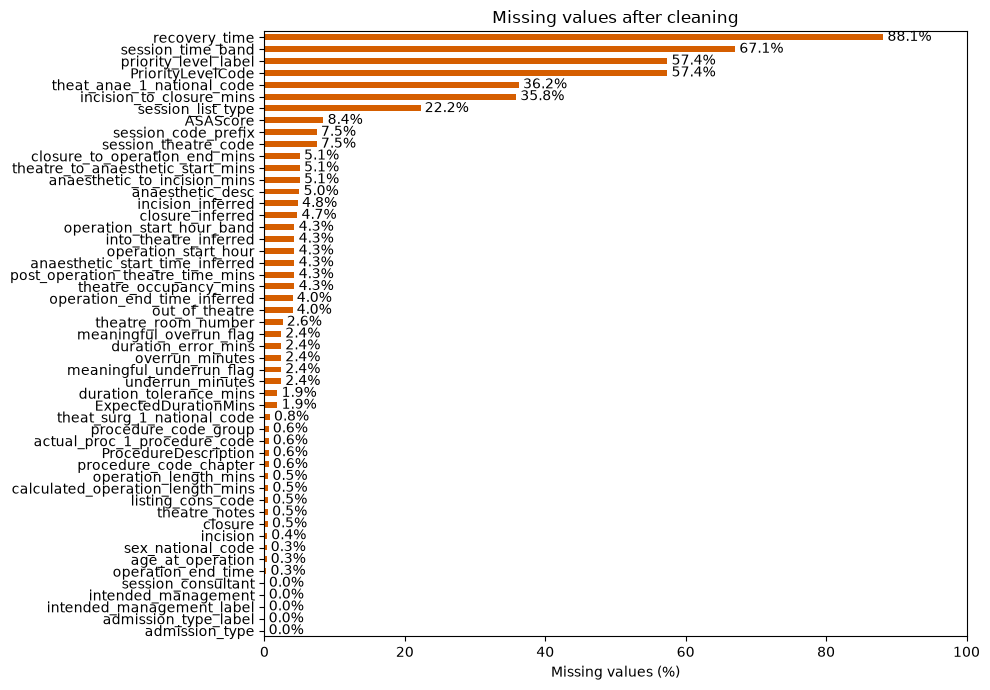

In [58]:
missing_pct_after_cleaning = (analysis_df.isna().mean() * 100).sort_values(ascending=True)
missing_pct_after_cleaning = missing_pct_after_cleaning[missing_pct_after_cleaning > 0]

fig, ax = plt.subplots(figsize=(10, 7))
missing_pct_after_cleaning.plot(kind="barh", ax=ax, color="#D55E00")
ax.set_title("Missing values after cleaning")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
ax.set_xlim(0, min(100, missing_pct_after_cleaning.max() + 12))

plt.tight_layout()


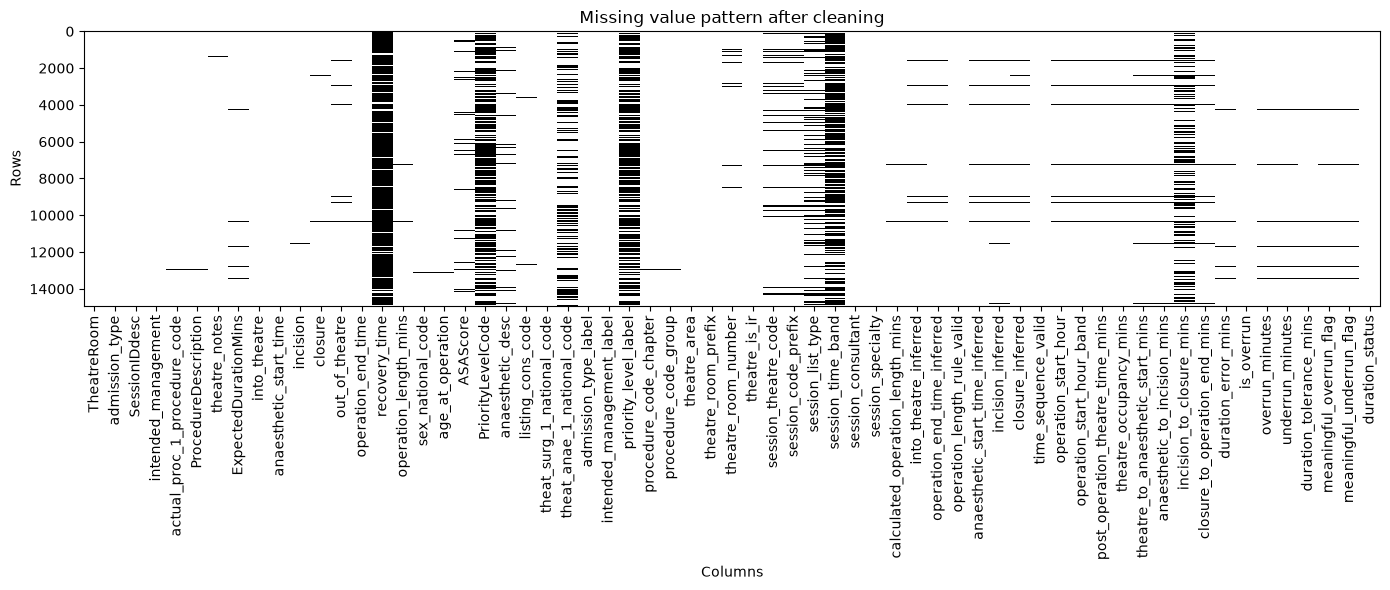

In [59]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(analysis_df.isna(), aspect="auto", interpolation="nearest", cmap="Greys")
ax.set_title("Missing value pattern after cleaning")
ax.set_xlabel("Columns")
ax.set_ylabel("Rows")
ax.set_xticks(range(len(analysis_df.columns)))
ax.set_xticklabels(analysis_df.columns, rotation=90)

plt.tight_layout()


**Result interpretation:** The missingness plot shows that incompleteness is driven by a small number of columns rather than the dataset as a whole. The heatmap helps identify whether missing values cluster in specific records or fields, which may reflect data-capture processes.


## 10. EDA on cleaned data

This section uses the cleaned analysis dataset to move from data preparation into operational insight. The focus is theatre scheduling: operation duration, theatre occupancy, planned-versus-actual performance, start-time effects, room pressure, procedure mix, staff-code variation, and process-stage bottlenecks.

The EDA keeps missing values visible rather than hiding them. Missingness and invalid timing flags are part of the operational evidence, especially for theatre-flow features that depend on reconstructed timestamps. The analysis therefore combines descriptive statistics, grouped summaries, heatmaps, scatter plots, and outlier review. These outputs identify patterns and hypotheses for later modelling; they do not by themselves prove causality.


### 10.1 EDA setup

These helper functions keep the EDA tables consistent. They summarise category size, missing operation length, median duration, mean duration, quartiles, and planned-versus-actual duration error.


In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.max_open_warning"] = 0

plot_color = "#2F6F9F"
highlight_color = "#D55E00"
neutral_color = "#6C757D"
target_column = "operation_length_mins"


# Shared plotting order and colours for planned-versus-actual duration status.
duration_status_order = [
    "meaningful_overrun",
    "within_tolerance",
    "meaningful_underrun",
    "missing_duration",
]

status_colors = {
    "meaningful_overrun": highlight_color,
    "within_tolerance": "#8C8C8C",
    "meaningful_underrun": plot_color,
    "missing_duration": "#BDBDBD",
}


def available_columns(df, columns):
    return [column for column in columns if column in df.columns]


def category_count_table(df, column, top_n=15):
    counts = (
        df[column]
        .astype("string")
        .fillna("Missing")
        .value_counts(dropna=False)
        .head(top_n)
        .rename_axis(column)
        .reset_index(name="cases")
    )
    counts["case_pct"] = (counts["cases"] / len(df) * 100).round(2)
    return counts


def duration_summary_by_category(df, category, min_cases=20, top_n=20):
    required = [category, target_column]
    optional = available_columns(df, ["ExpectedDurationMins", "duration_error_mins"])
    temp = df[required + optional].copy()
    temp[category] = temp[category].astype("string").fillna("Missing")

    summary = temp.groupby(category, dropna=False).agg(
        cases=(target_column, "size"),
        missing_operation_length=(target_column, lambda series: series.isna().sum()),
        median_operation_length=(target_column, "median"),
        mean_operation_length=(target_column, "mean"),
        q1_operation_length=(target_column, lambda series: series.quantile(0.25)),
        q3_operation_length=(target_column, lambda series: series.quantile(0.75)),
    )

    if "ExpectedDurationMins" in temp.columns:
        summary["median_expected_duration"] = temp.groupby(category)["ExpectedDurationMins"].median()
    if "duration_error_mins" in temp.columns:
        summary["median_duration_error"] = temp.groupby(category)["duration_error_mins"].median()

    summary = summary.reset_index()
    summary = summary[summary["cases"] >= min_cases]
    return summary.sort_values("median_operation_length", ascending=False).head(top_n)


**Result interpretation:** The EDA setup standardises summary outputs and reduces repeated code. `operation_length_mins` is treated as the main duration outcome, and medians are reported alongside means because operation durations are skewed and contain outliers.


### 10.2 Univariate numeric EDA

Univariate EDA looks at one numeric variable at a time. This helps identify skew, spread, outliers, and whether a variable should be transformed or treated carefully later.


In [61]:
numeric_eda_columns = available_columns(
    analysis_df,
    [
        "ExpectedDurationMins",
        "operation_length_mins",
        "duration_error_mins",
        "overrun_minutes",
        "underrun_minutes",
        "theatre_occupancy_mins",
        "post_operation_theatre_time_mins",
        "theatre_to_anaesthetic_start_mins",
        "anaesthetic_to_incision_mins",
        "incision_to_closure_mins",
        "closure_to_operation_end_mins",
        "age_at_operation",
    ],
)

numeric_eda_summary = analysis_df[numeric_eda_columns].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
).T
numeric_eda_summary["missing"] = analysis_df[numeric_eda_columns].isna().sum()
numeric_eda_summary["missing_pct"] = (
    analysis_df[numeric_eda_columns].isna().mean() * 100
).round(2)

numeric_eda_summary



,count,mean,std,min,1%,25%,50%,75%,99%,max,missing,missing_pct
ExpectedDurationMins,14642.00,98.69,88.49,3.00,15.00,60.00,60.00,120.00,480.00,1415.00,276,1.85
operation_length_mins,14836.00,97.95,92.50,3.00,9.00,39.00,70.00,124.00,481.00,1017.00,82,0.55
duration_error_mins,14563.00,-0.49,68.26,-1399.00,-156.00,-32.00,-8.00,22.00,225.38,867.00,355,2.38
overrun_minutes,14563.00,21.07,48.17,0.00,0.00,0.00,0.00,22.00,225.38,867.00,355,2.38
underrun_minutes,14563.00,21.56,37.83,0.00,0.00,0.00,8.00,32.00,156.00,1399.00,355,2.38
theatre_occupancy_mins,14279.00,108.46,96.74,3.00,13.00,45.00,80.00,138.00,500.22,1040.00,639,4.28
post_operation_theatre_time_mins,14279.00,9.75,8.21,0.00,0.00,4.00,8.00,13.00,41.00,59.00,639,4.28
theatre_to_anaesthetic_start_mins,14164.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,754,5.05
anaesthetic_to_incision_mins,14164.00,25.21,14.33,0.00,0.00,14.00,24.00,35.00,58.00,59.00,754,5.05
incision_to_closure_mins,9570.00,15.73,10.96,0.00,0.00,7.00,14.00,22.00,47.00,59.00,5348,35.85


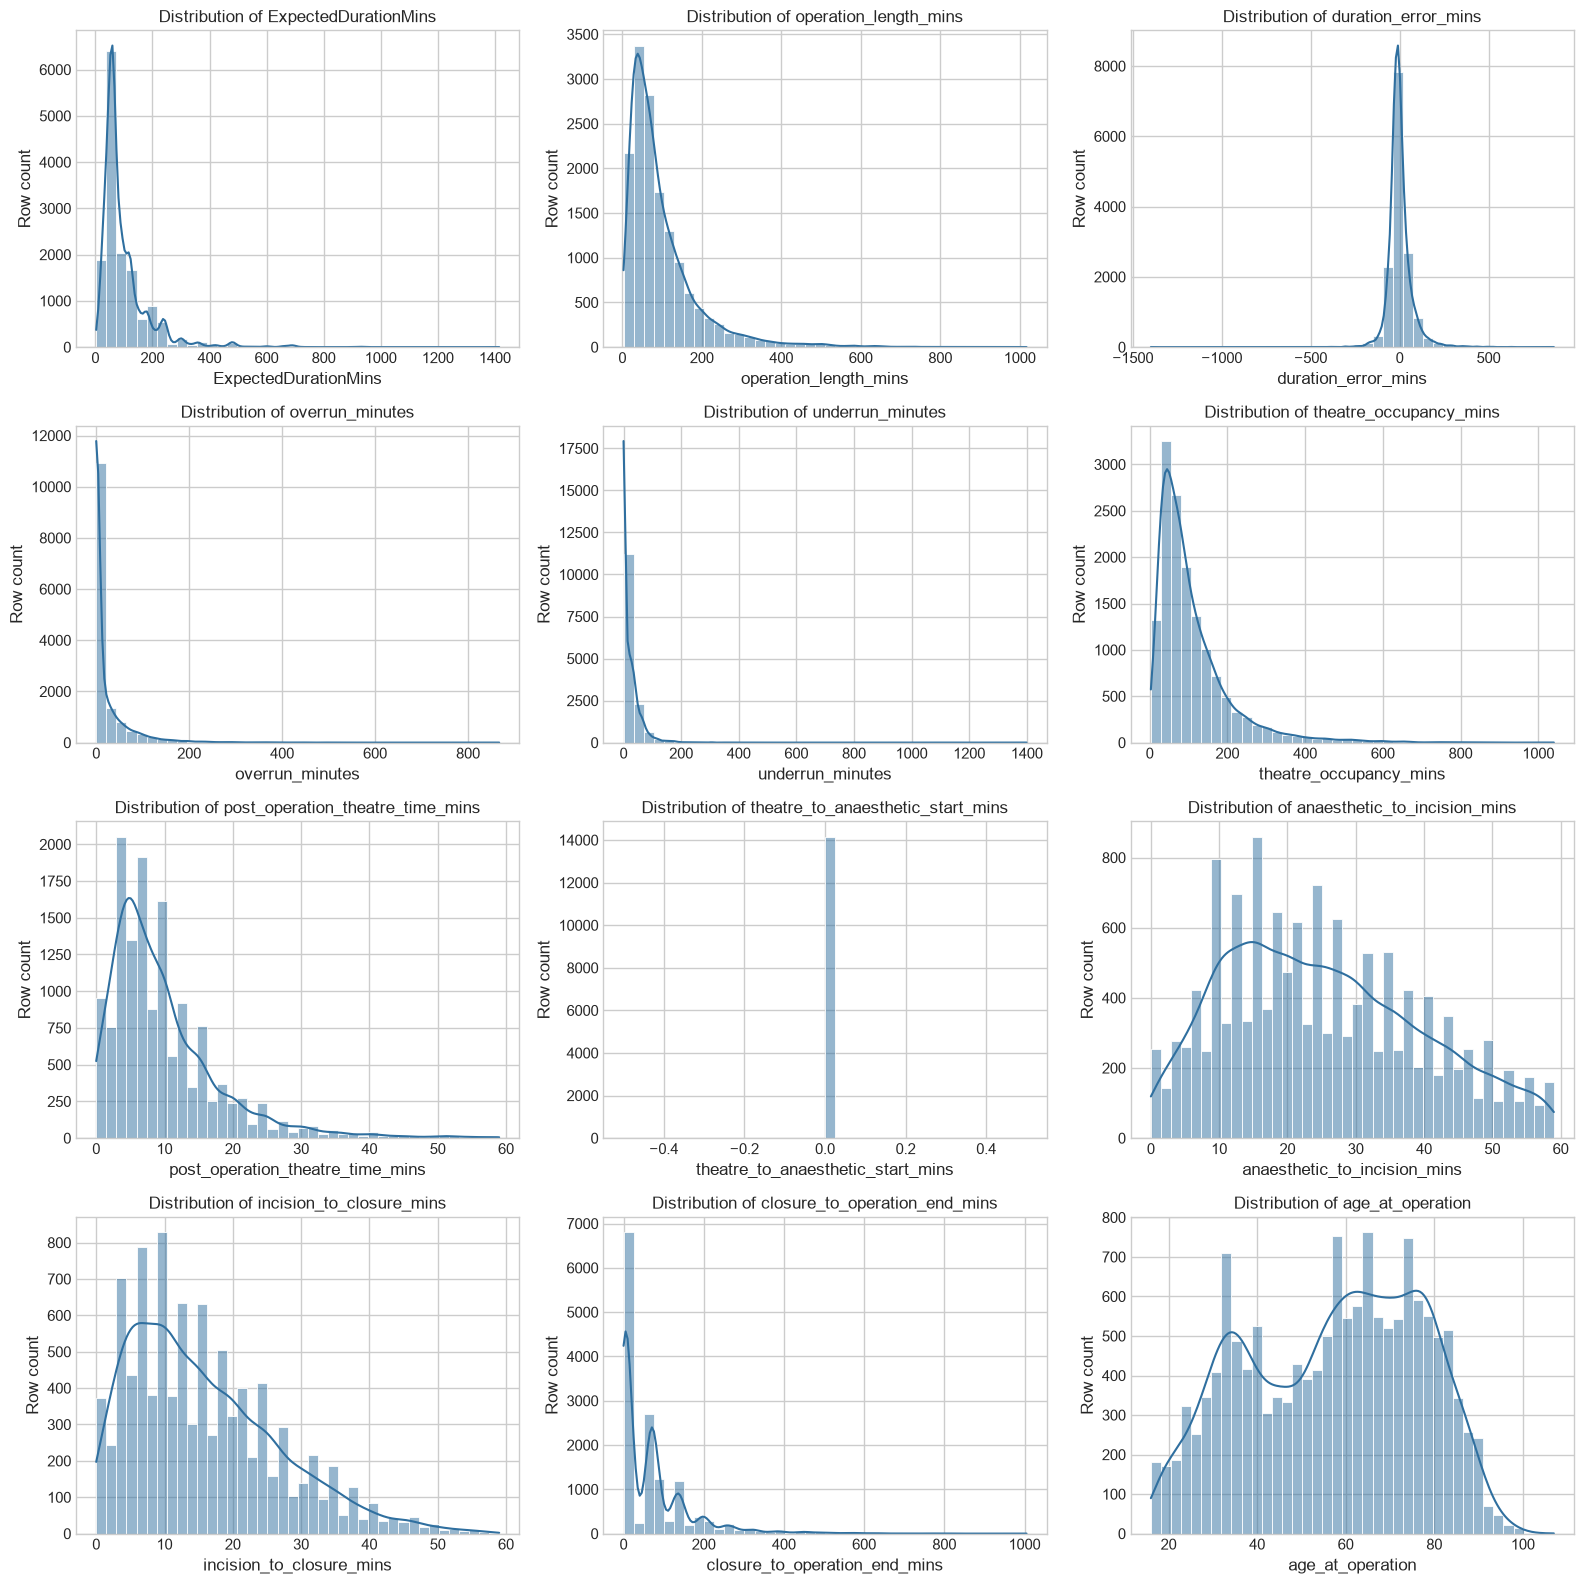

In [62]:
hist_columns = numeric_eda_columns
n_cols = 3
n_rows = -(-len(hist_columns) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel()

for ax, column in zip(axes, hist_columns):
    sns.histplot(
        data=analysis_df,
        x=column,
        bins=40,
        kde=True,
        ax=ax,
        color=plot_color,
        edgecolor="white",
    )
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Row count")

for ax in axes[len(hist_columns):]:
    ax.axis("off")

plt.tight_layout()


**Result interpretation:** Numeric distributions indicate strong right-skew in theatre-duration variables. Most cases fall within shorter or moderate duration ranges, while a smaller number of long cases create extended tails. Median and IQR-based summaries are therefore more appropriate than relying on means alone.


### 10.3 Univariate categorical EDA

Categorical EDA checks the balance of important groups. Missing values are shown as `Missing` because missingness may itself describe how the data was captured. The full `TheatreRoom` value is included because it represents the exact room location, while extracted fields such as `theatre_area`, `theatre_room_prefix`, and `theatre_room_number` only describe parts of that location.


In [63]:
categorical_eda_columns = available_columns(
    analysis_df,
    [
        "TheatreRoom",
        "theatre_area",
        "theatre_room_prefix",
        "admission_type_label",
        "intended_management_label",
        "anaesthetic_desc",
        "ASAScore",
        "PriorityLevelCode",
        "session_time_band",
        "session_specialty",
        "procedure_code_chapter",
        "procedure_code_group",
        "ProcedureDescription",
    ],
)

for column in categorical_eda_columns:
    print(f"Top values for {column}")
    display(category_count_table(analysis_df, column, top_n=12))


Top values for TheatreRoom


,TheatreRoom,cases,case_pct
0,BRUNEL TH 05,706,4.73
1,PLASTIC MINOR 1,651,4.36
2,IR LAB 1,631,4.23
3,GYNAE TH 02,621,4.16
4,IR LAB 2,551,3.69
5,CATH LAB 05,524,3.51
6,PLASTIC MINOR 2,523,3.51
7,BRUNEL TH 03,520,3.49
8,BRUNEL TH 06,516,3.46
9,GYNAE TH 01,496,3.32


Top values for theatre_area


,theatre_area,cases,case_pct
0,BRUNEL,7846,52.59
1,IR LAB,1915,12.84
2,PLASTIC MINOR,1629,10.92
3,GYNAE,1132,7.59
4,COTSWOLD,808,5.42
5,PARKVIEW,535,3.59
6,CATH LAB,524,3.51
7,HYBRID THEATRE,216,1.45
8,PACING ROOM,160,1.07
9,IF FLUORO,135,0.90


Top values for theatre_room_prefix


...

,procedure_code_chapter,cases,case_pct
0,S,2256,15.12
1,M,1723,11.55
2,W,1552,10.40
3,R,1110,7.44
4,L,1021,6.84
5,T,888,5.95
6,Y,790,5.30
7,Q,739,4.95
8,A,733,4.91
9,V,710,4.76


Top values for procedure_code_group


,procedure_code_group,cases,case_pct
0,S0,1437,9.63
1,R1,899,6.03
2,Q1,511,3.43
3,W2,503,3.37
4,M4,459,3.08
5,K6,449,3.01
6,S5,429,2.88
7,M1,390,2.61
8,L7,383,2.57
9,Y8,340,2.28


Top values for ProcedureDescription


,ProcedureDescription,cases,case_pct
0,Unspecified other excision of lesion of skin,1423,9.54
1,Elective lower uterine segment caesarean delivery,633,4.24
2,Other specified general anaesthetic,326,2.19
3,Coronary arteriography NEC,278,1.86
4,Lower uterine segment caesarean delivery NEC,259,1.74
5,Maintenance of drainage tube of kidney,223,1.49
6,Debridement of skin NEC,215,1.44
7,Total cholecystectomy NEC,181,1.21
8,Percutaneous transluminal angioplasty of artery,178,1.19
9,Total excision of prostate and capsule of prostate,173,1.16


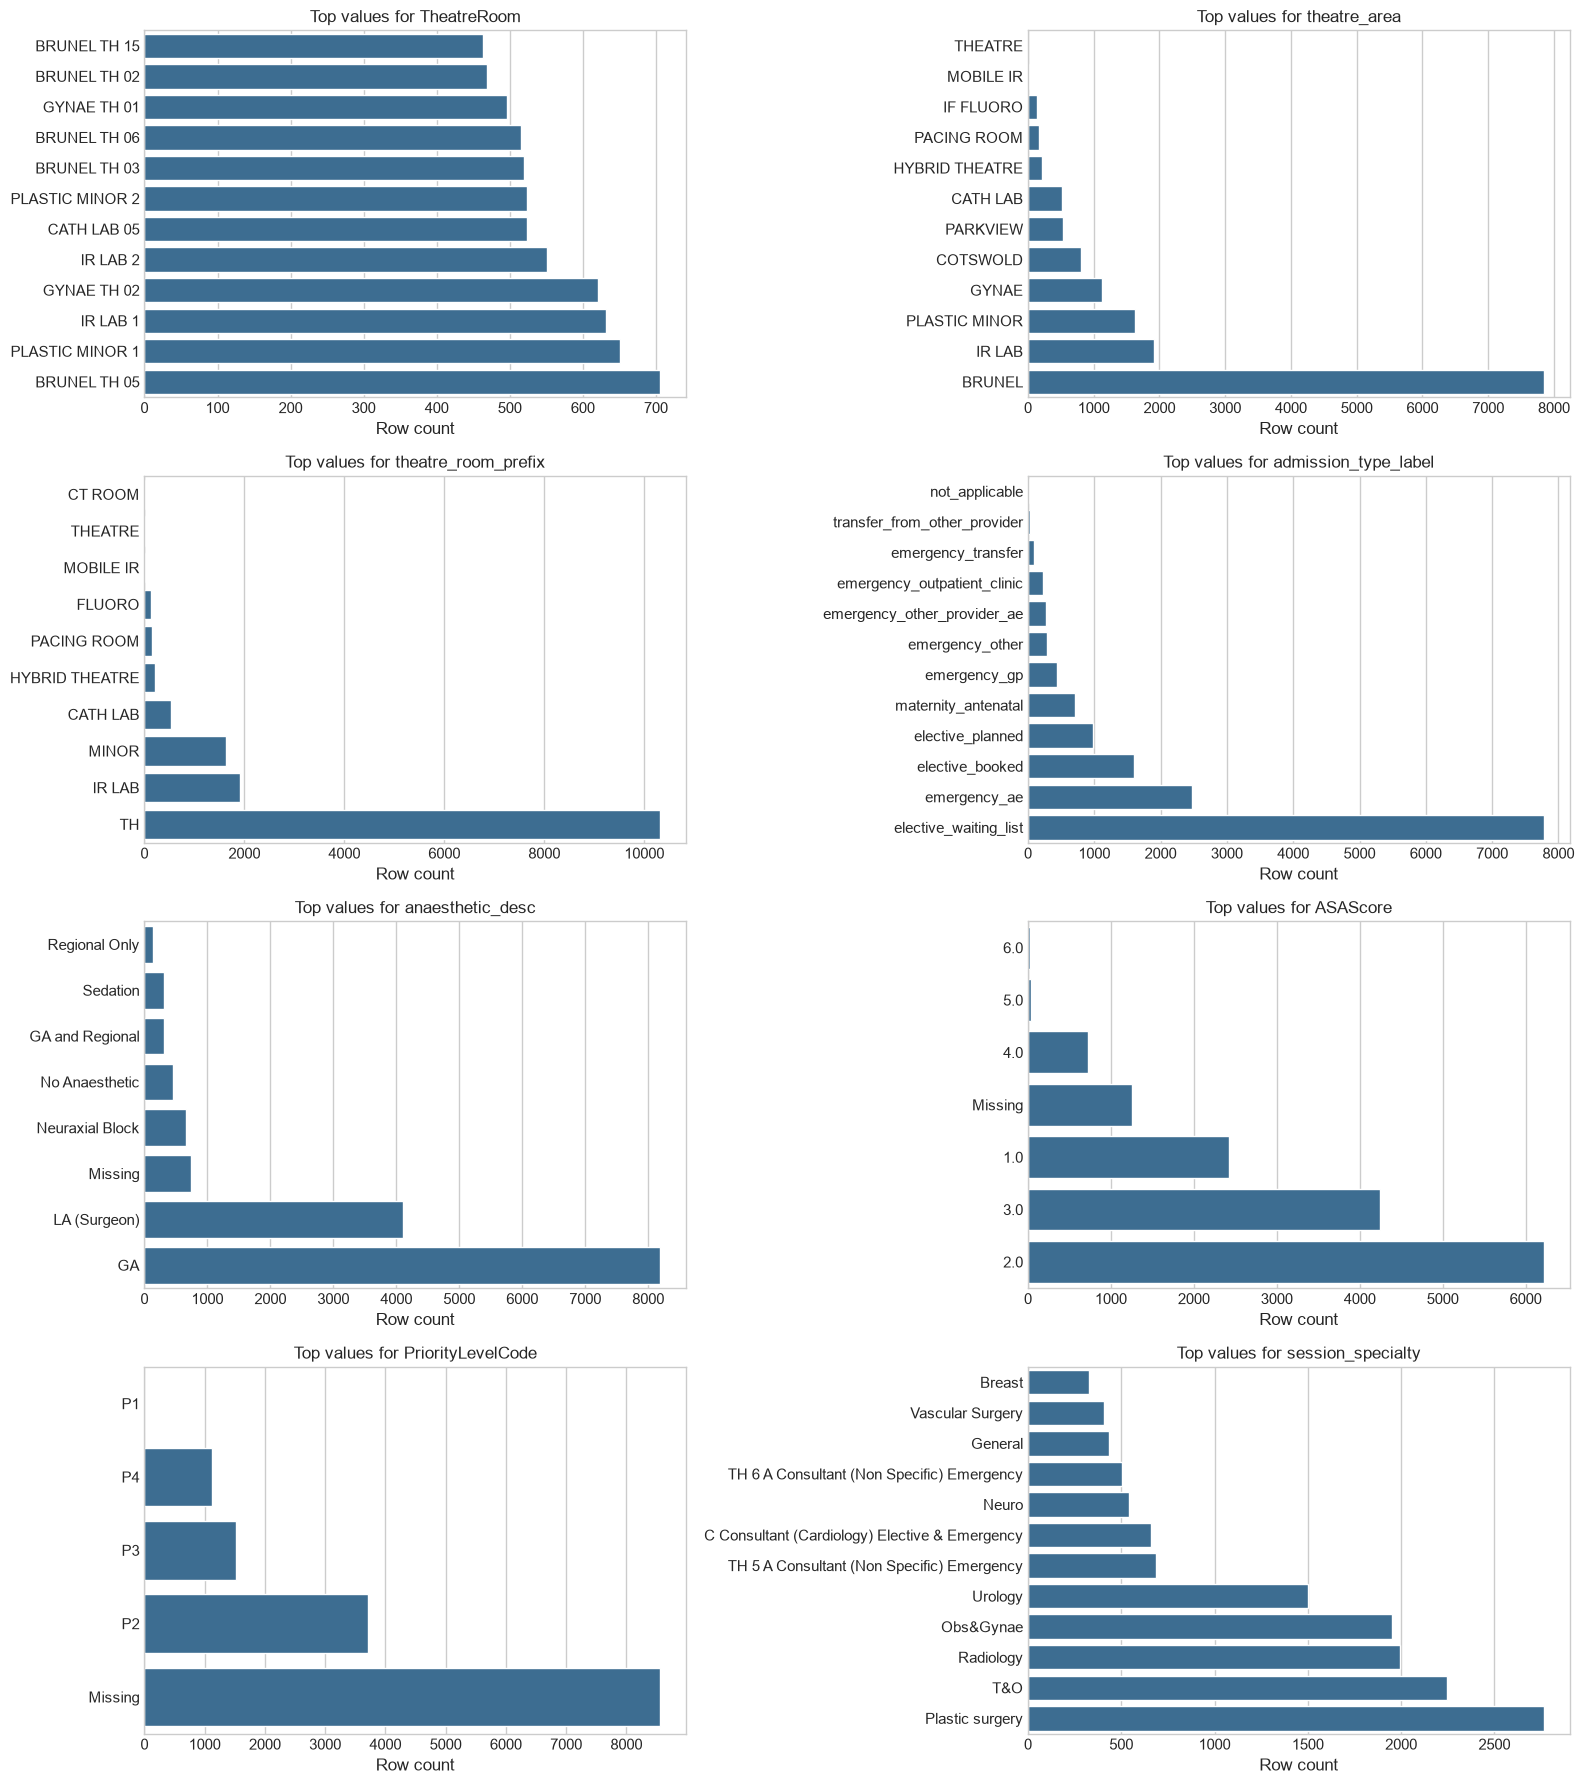

In [64]:
plot_categories = available_columns(
    analysis_df,
    [
        "TheatreRoom",
        "theatre_area",
        "theatre_room_prefix",
        "admission_type_label",
        "anaesthetic_desc",
        "ASAScore",
        "PriorityLevelCode",
        "session_specialty",
    ],
)

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.ravel()

for ax, column in zip(axes, plot_categories):
    counts = (
        analysis_df[column]
        .astype("string")
        .fillna("Missing")
        .value_counts()
        .head(12)
        .sort_values()
        .rename_axis(column)
        .reset_index(name="cases")
    )
    sns.barplot(data=counts, x="cases", y=column, ax=ax, color=plot_color)
    ax.set_title(f"Top values for {column}")
    ax.set_xlabel("Row count")
    ax.set_ylabel("")

for ax in axes[len(plot_categories):]:
    ax.axis("off")

plt.tight_layout()


**Result interpretation:** The categorical summaries show where activity is concentrated across rooms, theatre areas, anaesthetic types, and procedure groups. High-volume categories provide more stable estimates, while low-volume categories should be interpreted with caution.


### 10.4 Planned versus actual duration

This part compares the planned duration, `ExpectedDurationMins`, with the actual recorded duration, `operation_length_mins`. This is central to theatre scheduling because it shows whether cases tend to run longer or shorter than planned.


In [65]:
duration_plot_df = analysis_df[["ExpectedDurationMins", "operation_length_mins", "duration_error_mins"]].dropna()

duration_error_summary = duration_plot_df["duration_error_mins"].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
).to_frame("duration_error_mins")

duration_error_summary


,duration_error_mins
count,14563.00
mean,-0.49
std,68.26
min,-1399.00
1%,-156.00
25%,-32.00
50%,-8.00
75%,22.00
99%,225.38
max,867.00


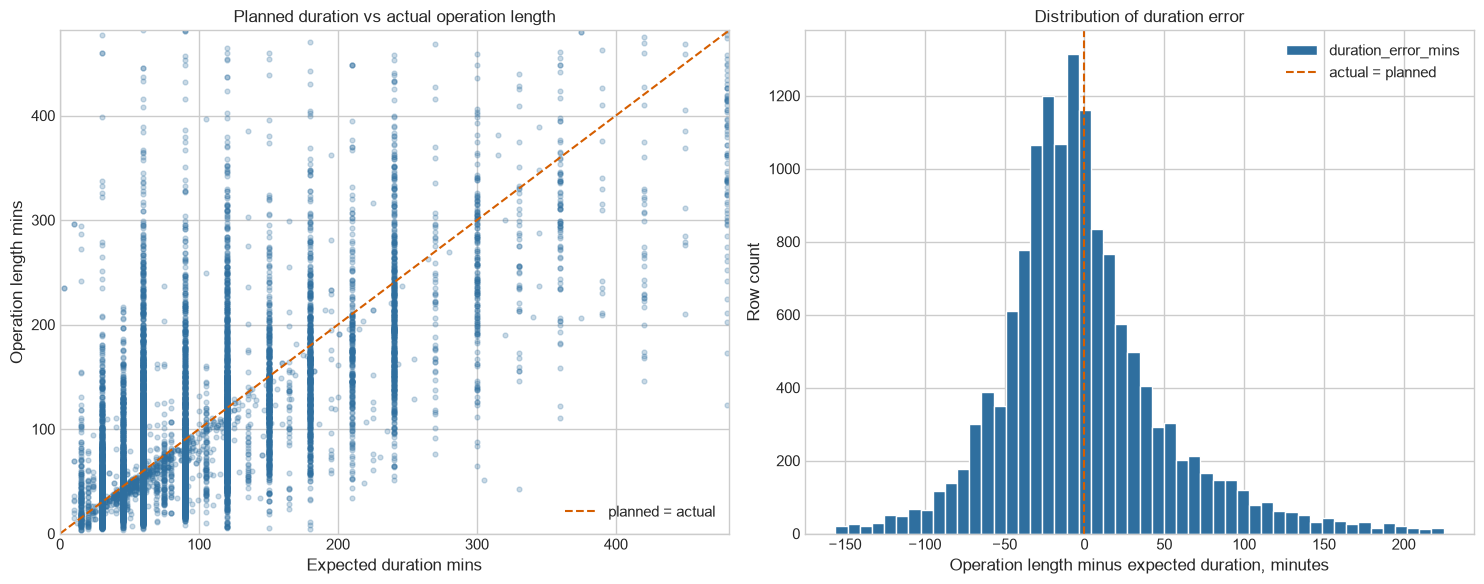

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

max_duration = duration_plot_df[["ExpectedDurationMins", "operation_length_mins"]].quantile(0.99).max()
axes[0].scatter(
    duration_plot_df["ExpectedDurationMins"],
    duration_plot_df["operation_length_mins"],
    alpha=0.25,
    s=12,
    color=plot_color,
)
axes[0].plot([0, max_duration], [0, max_duration], color=highlight_color, linestyle="--", label="planned = actual")
axes[0].set_xlim(0, max_duration)
axes[0].set_ylim(0, max_duration)
axes[0].set_title("Planned duration vs actual operation length")
axes[0].set_xlabel("Expected duration mins")
axes[0].set_ylabel("Operation length mins")
axes[0].legend()

duration_error_trimmed = duration_plot_df["duration_error_mins"]
duration_error_trimmed = duration_error_trimmed[
    duration_error_trimmed.between(
        duration_error_trimmed.quantile(0.01),
        duration_error_trimmed.quantile(0.99),
    )
]
duration_error_trimmed.plot(kind="hist", bins=50, ax=axes[1], color=plot_color, edgecolor="white")
axes[1].axvline(0, color=highlight_color, linestyle="--", label="actual = planned")
axes[1].set_title("Distribution of duration error")
axes[1].set_xlabel("Operation length minus expected duration, minutes")
axes[1].set_ylabel("Row count")
axes[1].legend()

plt.tight_layout()


**Result interpretation:** The planned-versus-actual plot shows whether cases fall above or below the expected-duration line. The duration-error distribution summarises the direction and size of planning error, with large positive values indicating cases most likely to contribute to scheduling pressure.


### 10.4.1 Duration status distribution

`duration_status` applies the tolerance rule defined in Section 7.15. This gives a fairer summary of planned-versus-actual performance than counting every small positive or negative difference as an overrun or underrun.


In [67]:
duration_status_summary = (
    analysis_df["duration_status"]
    .astype("string")
    .fillna("missing_duration")
    .value_counts()
    .reindex(duration_status_order, fill_value=0)
    .rename_axis("duration_status")
    .reset_index(name="cases")
)
duration_status_summary["case_pct"] = (
    duration_status_summary["cases"] / len(analysis_df) * 100
).round(2)
duration_status_summary


,duration_status,cases,case_pct
0,meaningful_overrun,4569,30.63
1,within_tolerance,3391,22.73
2,meaningful_underrun,6603,44.26
3,missing_duration,355,2.38


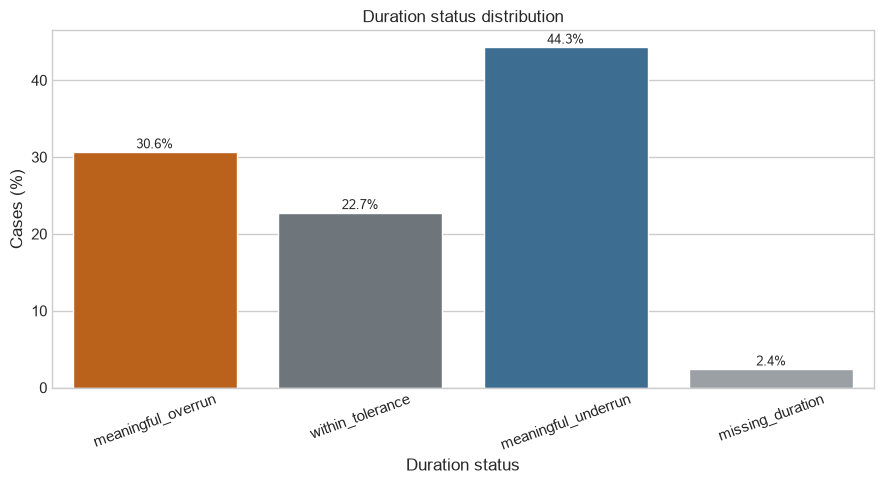

In [68]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=duration_status_summary,
    x="duration_status",
    y="case_pct",
    ax=ax,
    palette=[highlight_color, neutral_color, plot_color, "#9aa0a6"],
    hue="duration_status",
    legend=False,
)
ax.set_title("Duration status distribution")
ax.set_xlabel("Duration status")
ax.set_ylabel("Cases (%)")
ax.tick_params(axis="x", rotation=20)

for index, row in duration_status_summary.iterrows():
    ax.text(index, row["case_pct"] + 0.5, f"{row['case_pct']:.1f}%", ha="center", fontsize=9)

plt.tight_layout()


**Result interpretation:** The duration-status distribution shows how planned and actual operation times compare after applying the working tolerance rule. `meaningful_overrun` identifies cases exceeding the planned duration by more than the tolerance threshold, while `meaningful_underrun` identifies cases finishing substantially earlier than planned. `within_tolerance` represents cases close enough to the expected duration to avoid being treated as operationally significant deviations.

This classification is more appropriate for scheduling analysis than using a simple positive or negative duration error, because it reduces the influence of very small timing differences. Cases labelled `missing_duration` remain unclassified and should be retained as a visible data-quality group.


### 10.5 Operation length by key categories

This part checks whether operation length differs across important clinical and operational categories. These tables are useful for identifying candidate predictors for modelling, but they do not prove causation.


In [69]:
duration_category_columns = available_columns(
    analysis_df,
    [
        "theatre_area",
        "theatre_room_prefix",
        "anaesthetic_desc",
        "admission_type_label",
        "intended_management_label",
        "ASAScore",
        "PriorityLevelCode",
        "session_time_band",
        "session_specialty",
        "ProcedureDescription",
    ],
)

for column in duration_category_columns:
    print(f"Operation length by {column}")
    display(duration_summary_by_category(analysis_df, column, min_cases=20, top_n=15))


Operation length by theatre_area


,theatre_area,cases,missing_operation_length,median_operation_length,mean_operation_length,q1_operation_length,q3_operation_length,median_expected_duration,median_duration_error
5,HYBRID THEATRE,216,0,167.50,184.27,91.00,233.25,120.00,12.00
0,BRUNEL,7846,36,100.00,127.59,54.00,162.00,90.00,-7.00
10,PARKVIEW,535,1,73.00,77.70,44.25,103.75,90.00,-19.00
4,GYNAE,1132,11,72.00,75.84,61.00,85.00,60.00,14.00
1,CATH LAB,524,3,61.00,69.18,43.00,85.00,64.00,-6.00
7,IR LAB,1915,21,56.00,70.18,33.00,90.00,60.00,1.00
2,COTSWOLD,808,0,42.00,64.97,29.00,78.00,60.00,-13.00
9,PACING ROOM,160,3,39.00,38.76,26.00,46.00,45.00,-8.00
11,PLASTIC MINOR,1629,5,30.00,35.13,22.00,43.00,60.00,-30.00
6,IF FLUORO,135,0,26.00,31.81,14.00,43.00,30.00,-7.00


Operation length by theatre_room_prefix


,theatre_room_prefix,cases,missing_operation_length,median_operation_length,mean_operation_length,q1_operation_length,q3_operation_length,median_expected_duration,median_duration_error
3,HYBRID THEATRE,216,0,167.50,184.27,91.00,233.25,120.00,12.00
8,TH,10321,48,85.00,114.43,51.00,144.00,75.00,-5.00
0,CATH LAB,524,3,61.00,69.18,43.00,85.00,64.00,-6.00
4,IR LAB,1915,21,56.00,70.18,33.00,90.00,60.00,1.00
7,PACING ROOM,160,3,39.00,38.76,26.00,46.00,45.00,-8.00
5,MINOR,1629,5,30.00,35.13,22.00,43.00,60.00,-30.00
2,FLUORO,135,0,26.00,31.81,14.00,43.00,30.00,-7.00


Operation length by anaesthetic_desc


...

,session_time_band,cases,missing_operation_length,median_operation_length,mean_operation_length,q1_operation_length,q3_operation_length,median_expected_duration,median_duration_error
2,Missing,10003,58,85.00,114.34,50.00,143.00,75.00,-5.00
3,PM,2233,17,48.00,66.87,31.00,79.00,60.00,-15.00
0,AM,2612,7,44.00,63.06,27.00,78.00,60.00,-13.00
1,EVE,70,0,37.50,51.14,23.25,54.25,60.00,-30.00


Operation length by session_specialty


,session_specialty,cases,missing_operation_length,median_operation_length,mean_operation_length,q1_operation_length,q3_operation_length,median_expected_duration,median_duration_error
13,Neuro,541,2,177.00,221.30,95.00,308.00,240.00,-42.00
25,TH 1 (2SD) P Consultant (Burns),22,0,124.00,161.68,102.25,165.75,60.00,61.00
20,T&O,2244,6,121.00,134.83,76.25,165.00,120.00,1.00
268,Vascular Surgery,405,1,118.50,154.11,53.75,223.50,120.00,-1.50
45,TH 6 A Consultant (Non Specific) Emergency,505,4,117.00,138.71,67.00,192.00,60.00,42.00
221,TH4 A Consultant (Non Specific) Emergency,24,0,97.50,120.92,76.00,145.50,60.00,24.00
216,TH3 A Consultant (Non Specific) Emergency,42,2,93.00,100.67,52.00,143.50,60.00,34.00
1,Breast,328,1,92.00,100.43,67.00,125.00,120.00,-19.00
42,TH 4 A Consultant (Non Specific) Emergency,20,0,89.00,128.60,76.50,136.00,60.00,19.00
44,TH 5 A Consultant (Non Specific) Emergency,686,7,82.00,101.37,44.50,129.00,60.00,24.00


Operation length by ProcedureDescription


,ProcedureDescription,cases,missing_operation_length,median_operation_length,mean_operation_length,q1_operation_length,q3_operation_length,median_expected_duration,median_duration_error
944,Unspecified opening of cranium,60,0,353.50,387.48,299.00,431.25,480.00,-50.00
142,Cystoprostatectomy,24,0,349.00,384.75,299.00,468.25,480.00,-95.00
383,Intraoperative fluid monitoring,26,0,317.50,316.35,210.75,434.50,345.00,-21.00
205,Endarterectomy of femoral artery NEC,28,0,305.00,311.86,230.00,384.25,240.00,61.00
345,Implantation of brain neurostimulator,22,0,305.00,295.41,286.00,329.00,330.00,-4.00
441,Nephroureterectomy NEC,22,0,262.00,267.55,230.25,295.00,240.00,2.50
786,Revision of total prosthetic replacement of hip joint NEC,35,0,255.00,259.94,216.50,307.50,240.00,23.00
789,Revision of total prosthetic replacement of knee joint NEC,22,0,234.00,230.00,193.25,241.50,240.00,-8.00
963,Unspecified other excision of right hemicolon,23,0,227.00,224.57,170.50,273.50,240.00,-28.00
799,Robotic minimal access approach to abdominal cavity,50,0,220.50,225.40,191.50,248.75,240.00,-21.50


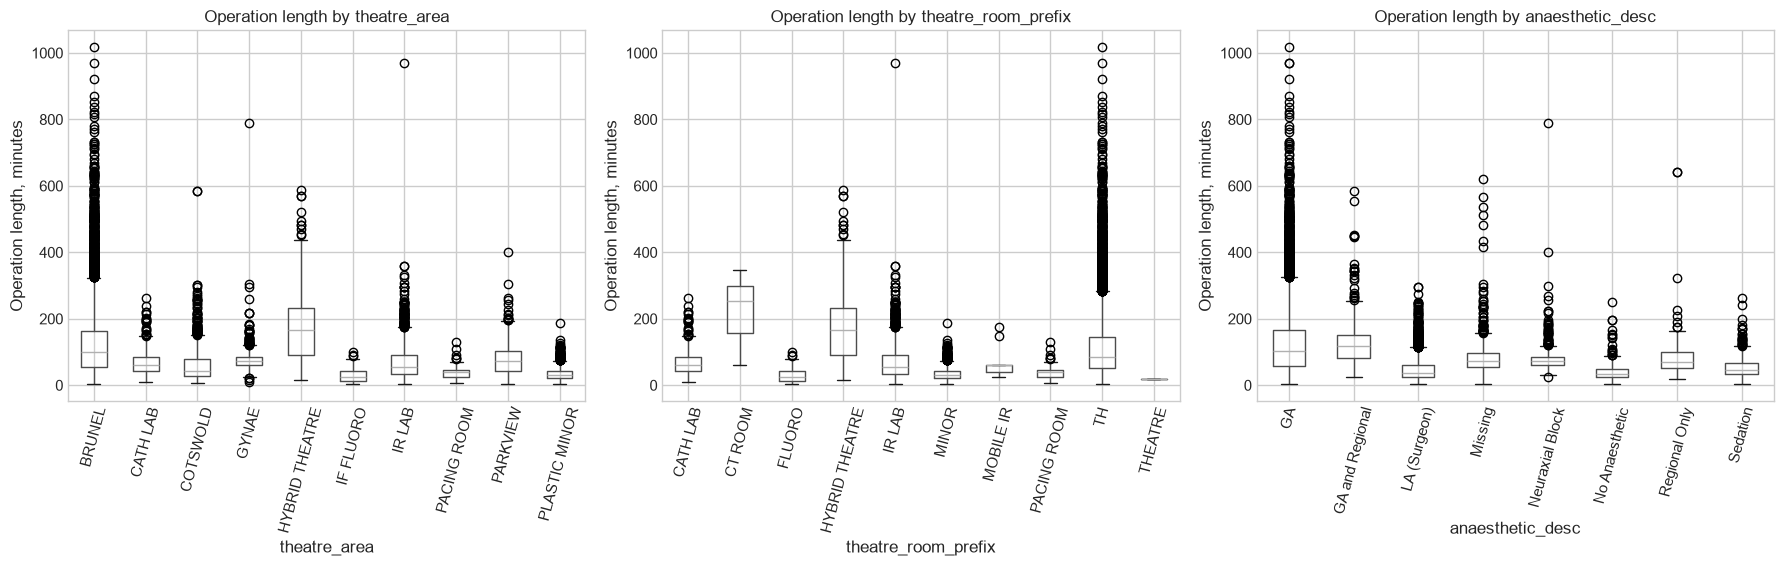

In [70]:
boxplot_categories = available_columns(analysis_df, ["theatre_area", "theatre_room_prefix", "anaesthetic_desc"])
fig, axes = plt.subplots(1, len(boxplot_categories), figsize=(6 * len(boxplot_categories), 6))
if len(boxplot_categories) == 1:
    axes = [axes]

for ax, column in zip(axes, boxplot_categories):
    top_values = analysis_df[column].astype("string").fillna("Missing").value_counts().head(10).index
    plot_df = analysis_df.assign(**{column: analysis_df[column].astype("string").fillna("Missing")})
    plot_df = plot_df[plot_df[column].isin(top_values)]
    plot_df.boxplot(column=target_column, by=column, ax=ax, rot=75)
    ax.set_title(f"Operation length by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Operation length, minutes")

fig.suptitle("")
plt.tight_layout()


**Result interpretation:** Category-level duration summaries highlight operational differences across theatre areas, room types, anaesthetic categories, admission routes, session groups, and procedure descriptions. Differences should be interpreted as associations and may reflect case mix as well as operational performance.


### 10.6 Bottleneck EDA setup

This step creates a temporary EDA copy from `analysis_df`. The raw dataset and `analysis_df` are not overwritten.

The time-flow columns, such as `operation_start_hour_band`, `theatre_occupancy_mins`, and `post_operation_theatre_time_mins`, are already created by the preprocessing pipeline. This setup only adds simple EDA flags used for plotting and grouped summaries.

Because the time reconstruction is inferred from the dataset, rows with failed timing validation should be interpreted carefully. This section is for EDA and hypothesis generation, not final causal conclusions.



In [71]:
bottleneck_eda_df = analysis_df.copy()

# Recreate planned-versus-actual status defensively if the dataset was loaded before these features existed.
if "duration_error_mins" not in bottleneck_eda_df.columns:
    bottleneck_eda_df["duration_error_mins"] = (
        bottleneck_eda_df["operation_length_mins"] - bottleneck_eda_df["ExpectedDurationMins"]
    )
if "overrun_minutes" not in bottleneck_eda_df.columns:
    bottleneck_eda_df["overrun_minutes"] = bottleneck_eda_df["duration_error_mins"].clip(lower=0)
if "underrun_minutes" not in bottleneck_eda_df.columns:
    bottleneck_eda_df["underrun_minutes"] = (-bottleneck_eda_df["duration_error_mins"]).clip(lower=0)
if "duration_tolerance_mins" not in bottleneck_eda_df.columns:
    bottleneck_eda_df["duration_tolerance_mins"] = (bottleneck_eda_df["ExpectedDurationMins"] * 0.10).clip(lower=10)
if "meaningful_overrun_flag" not in bottleneck_eda_df.columns:
    bottleneck_eda_df["meaningful_overrun_flag"] = bottleneck_eda_df["duration_error_mins"] > bottleneck_eda_df["duration_tolerance_mins"]
if "meaningful_underrun_flag" not in bottleneck_eda_df.columns:
    bottleneck_eda_df["meaningful_underrun_flag"] = bottleneck_eda_df["duration_error_mins"] < -bottleneck_eda_df["duration_tolerance_mins"]
if "duration_status" not in bottleneck_eda_df.columns:
    bottleneck_eda_df["duration_status"] = "within_tolerance"
    bottleneck_eda_df.loc[bottleneck_eda_df["meaningful_overrun_flag"], "duration_status"] = "meaningful_overrun"
    bottleneck_eda_df.loc[bottleneck_eda_df["meaningful_underrun_flag"], "duration_status"] = "meaningful_underrun"
    bottleneck_eda_df.loc[bottleneck_eda_df["duration_error_mins"].isna(), "duration_status"] = "missing_duration"

# Convenience flags for EDA: exact positive/negative difference, while meaningful flags come from Section 7.15.
bottleneck_eda_df["overrun_flag"] = bottleneck_eda_df["overrun_minutes"].fillna(0).gt(0)
bottleneck_eda_df["underrun_flag"] = bottleneck_eda_df["underrun_minutes"].fillna(0).gt(0)

preview_columns = available_columns(
    bottleneck_eda_df,
    [
        "into_theatre",
        "into_theatre_inferred",
        "operation_start_hour",
        "operation_start_hour_band",
        "operation_length_mins",
        "ExpectedDurationMins",
        "duration_error_mins",
        "duration_tolerance_mins",
        "duration_status",
        "overrun_minutes",
        "underrun_minutes",
        "meaningful_overrun_flag",
        "meaningful_underrun_flag",
        "post_operation_theatre_time_mins",
        "theatre_occupancy_mins",
        "operation_length_rule_valid",
    ],
)

bottleneck_eda_df[preview_columns].head(10)


,into_theatre,into_theatre_inferred,operation_start_hour,operation_start_hour_band,operation_length_mins,ExpectedDurationMins,duration_error_mins,duration_tolerance_mins,duration_status,overrun_minutes,underrun_minutes,meaningful_overrun_flag,meaningful_underrun_flag,post_operation_theatre_time_mins,theatre_occupancy_mins,operation_length_rule_valid
0,00:20:00,09:20,9.00,09:00-09:59,19.00,60.00,-41.00,10.00,meaningful_underrun,0.00,41.00,False,True,4.00,23.00,True
1,00:15:00,NaN,<NA>,NaN,92.00,120.00,-28.00,12.00,meaningful_underrun,0.00,28.00,False,True,NaN,NaN,False
2,00:58:00,13:58,13.00,13:00-13:59,60.00,120.00,-60.00,12.00,meaningful_underrun,0.00,60.00,False,True,6.00,66.00,True
3,00:12:00,14:12,14.00,14:00-14:59,28.00,60.00,-32.00,10.00,meaningful_underrun,0.00,32.00,False,True,7.00,35.00,True
4,00:51:00,09:51,9.00,09:00-09:59,27.00,48.00,-21.00,10.00,meaningful_underrun,0.00,21.00,False,True,2.00,29.00,True
5,00:01:00,09:01,9.00,09:00-09:59,210.00,240.00,-30.00,24.00,meaningful_underrun,0.00,30.00,False,True,11.00,221.00,True
6,00:30:00,13:30,13.00,13:00-13:59,19.00,60.00,-41.00,10.00,meaningful_underrun,0.00,41.00,False,True,24.00,43.00,True
7,00:58:00,18:58,18.00,18:00-18:59,20.00,60.00,-40.00,10.00,meaningful_underrun,0.00,40.00,False,True,7.00,27.00,True
8,00:47:00,10:47,10.00,10:00-10:59,70.00,60.00,10.00,10.00,within_tolerance,10.00,0.00,False,False,7.00,77.00,True
9,00:00:00,14:00,14.00,14:00-14:59,58.00,90.00,-32.00,10.00,meaningful_underrun,0.00,32.00,False,True,3.00,61.00,True


**Result interpretation:** The bottleneck EDA dataset is a temporary copy used for grouped summaries and plots. Meaningful overrun and underrun variables are already engineered in Section 7.15; this section uses them for visual analysis while preserving the original `analysis_df`.


### 10.6.1 Theatre-flow stage bottleneck profile

This step breaks the patient journey inside theatre into smaller stages. Instead of only asking whether the whole case overran, it asks where time is being spent: before anaesthesia starts, between anaesthesia and incision, during the main surgical phase, between closure and operation end, and after operation end before the patient leaves theatre.

This is useful because two cases can have the same total duration but very different operational causes. One may be long because the incision-to-closure stage is clinically complex, while another may be delayed after the operation has ended because the patient remains in theatre space.


In [72]:
theatre_flow_stage_columns = available_columns(
    bottleneck_eda_df,
    [
        "theatre_to_anaesthetic_start_mins",
        "anaesthetic_to_incision_mins",
        "incision_to_closure_mins",
        "closure_to_operation_end_mins",
        "post_operation_theatre_time_mins",
    ],
)

stage_summary = (
    bottleneck_eda_df[theatre_flow_stage_columns]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T[["count", "mean", "25%", "50%", "75%", "max"]]
    .rename(columns={"25%": "q1", "50%": "median", "75%": "q3"})
)
stage_summary["missing"] = bottleneck_eda_df[theatre_flow_stage_columns].isna().sum()
stage_summary["missing_pct"] = (
    bottleneck_eda_df[theatre_flow_stage_columns].isna().mean() * 100
).round(2)
stage_summary.round(2)


,count,mean,q1,median,q3,max,missing,missing_pct
theatre_to_anaesthetic_start_mins,14164.00,0.00,0.00,0.00,0.00,0.00,754,5.05
anaesthetic_to_incision_mins,14164.00,25.21,14.00,24.00,35.00,59.00,754,5.05
incision_to_closure_mins,9570.00,15.73,7.00,14.00,22.00,59.00,5348,35.85
closure_to_operation_end_mins,14164.00,70.03,5.00,60.00,85.00,1005.00,754,5.05
post_operation_theatre_time_mins,14279.00,9.75,4.00,8.00,13.00,59.00,639,4.28


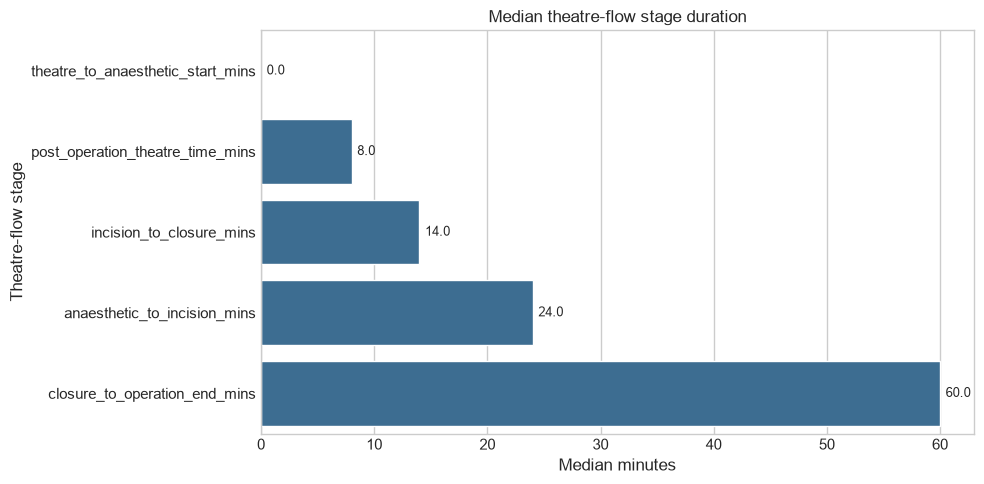

In [73]:
if theatre_flow_stage_columns:
    ordered_stage_summary = stage_summary.sort_values("median", ascending=True).reset_index(names="stage")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=ordered_stage_summary, x="median", y="stage", ax=ax, color=plot_color)
    ax.set_title("Median theatre-flow stage duration")
    ax.set_xlabel("Median minutes")
    ax.set_ylabel("Theatre-flow stage")

    for index, row in ordered_stage_summary.iterrows():
        ax.text(row["median"] + 0.5, index, f"{row['median']:.1f}", va="center", fontsize=9)

    plt.tight_layout()


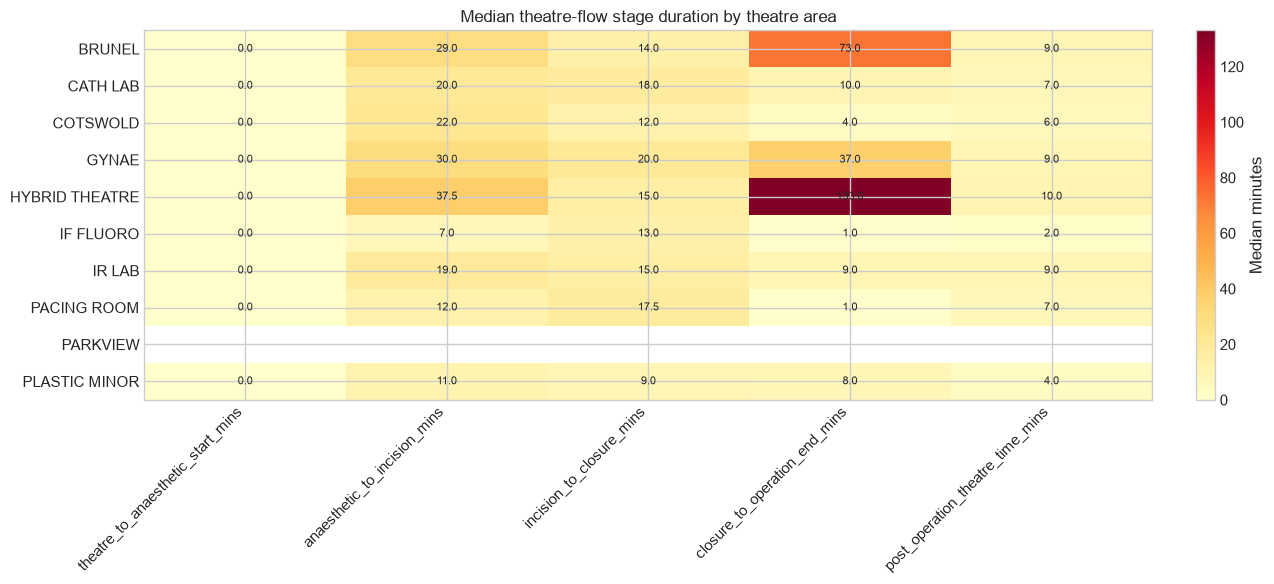

In [74]:
if theatre_flow_stage_columns and "theatre_area" in bottleneck_eda_df.columns:
    stage_area_df = bottleneck_eda_df.copy()
    stage_area_df["theatre_area"] = stage_area_df["theatre_area"].astype("string").fillna("Missing")
    top_stage_areas = stage_area_df["theatre_area"].value_counts().head(10).index

    stage_area_medians = (
        stage_area_df[stage_area_df["theatre_area"].isin(top_stage_areas)]
        .groupby("theatre_area")[theatre_flow_stage_columns]
        .median()
    )

    fig, ax = plt.subplots(figsize=(13, 6))
    image = ax.imshow(stage_area_medians.to_numpy(dtype=float), aspect="auto", cmap="YlOrRd")
    ax.set_title("Median theatre-flow stage duration by theatre area")
    ax.set_xticks(range(len(stage_area_medians.columns)))
    ax.set_xticklabels(stage_area_medians.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(stage_area_medians.index)))
    ax.set_yticklabels(stage_area_medians.index)

    for row_idx in range(stage_area_medians.shape[0]):
        for col_idx in range(stage_area_medians.shape[1]):
            value = stage_area_medians.iloc[row_idx, col_idx]
            if pd.notna(value):
                ax.text(col_idx, row_idx, f"{value:.1f}", ha="center", va="center", fontsize=8)

    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label("Median minutes")
    plt.tight_layout()


**Result interpretation:** The stage profile separates clinical operating time from surrounding theatre-flow time. A high `incision_to_closure_mins` value points mainly to procedure complexity, while high `anaesthetic_to_incision_mins`, `closure_to_operation_end_mins`, or `post_operation_theatre_time_mins` may indicate workflow pressure around preparation, finishing, recovery handover, or theatre exit. The area-level heatmap should be used to identify where a stage is consistently longer, but differences must be interpreted alongside specialty mix and case complexity.


### 10.7 Start-time and delay patterns

This check asks whether time of day is associated with scheduling performance. It does not prove that the start time causes delays, but it can show whether later or earlier start-hour bands have different operation lengths, meaningful overrun rates, or unused planned time.


In [75]:
def bottleneck_summary_by_category(df, category, min_cases=20, top_n=20, sort_by="median_overrun_minutes"):
    temp = df.copy()
    temp[category] = temp[category].astype("string").fillna("Missing")

    summary = temp.groupby(category, dropna=False).agg(
        cases=(target_column, "size"),
        valid_time_rows=("operation_length_rule_valid", lambda series: series.fillna(False).sum()),
        median_operation_length=(target_column, "median"),
        mean_operation_length=(target_column, "mean"),
        median_expected_duration=("ExpectedDurationMins", "median"),
        median_duration_error=("duration_error_mins", "median"),
        meaningful_overrun_rate=("meaningful_overrun_flag", "mean"),
        median_overrun_minutes=("overrun_minutes", "median"),
        median_underrun_minutes=("underrun_minutes", "median"),
    ).reset_index()

    summary["valid_time_pct"] = (summary["valid_time_rows"] / summary["cases"] * 100).round(2)
    summary["meaningful_overrun_rate"] = (summary["meaningful_overrun_rate"] * 100).round(2)
    summary = summary[summary["cases"] >= min_cases]
    return summary.sort_values(sort_by, ascending=False).head(top_n)

start_hour_bottleneck_summary = bottleneck_summary_by_category(
    bottleneck_eda_df,
    "operation_start_hour_band",
    min_cases=20,
    top_n=24,
    sort_by="operation_start_hour_band",
)

start_hour_bottleneck_summary


,operation_start_hour_band,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
24,Missing,639,0,71.00,78.35,90.00,-19.00,16.55,0.00,19.00,0.00
23,23:00-23:59,65,65,85.00,125.34,60.00,32.00,66.67,32.00,0.00,100.00
22,22:00-22:59,74,74,73.00,88.65,60.00,11.00,50.77,11.00,0.00,100.00
21,21:00-21:59,111,111,88.00,99.92,60.00,22.00,59.22,22.00,0.00,100.00
20,20:00-20:59,102,102,81.00,99.46,60.00,20.00,60.20,20.00,0.00,100.00
19,19:00-19:59,139,139,67.00,80.12,60.00,6.00,43.18,6.00,0.00,100.00
18,18:00-18:59,313,313,63.00,73.01,60.00,-8.50,33.00,0.00,8.50,100.00
17,17:00-17:59,509,509,68.00,82.02,60.00,-10.00,30.16,0.00,10.00,100.00
16,16:00-16:59,857,857,57.00,75.62,60.00,-14.00,26.33,0.00,14.00,100.00
15,15:00-15:59,1305,1305,59.00,74.10,60.00,-10.00,26.66,0.00,10.00,100.00


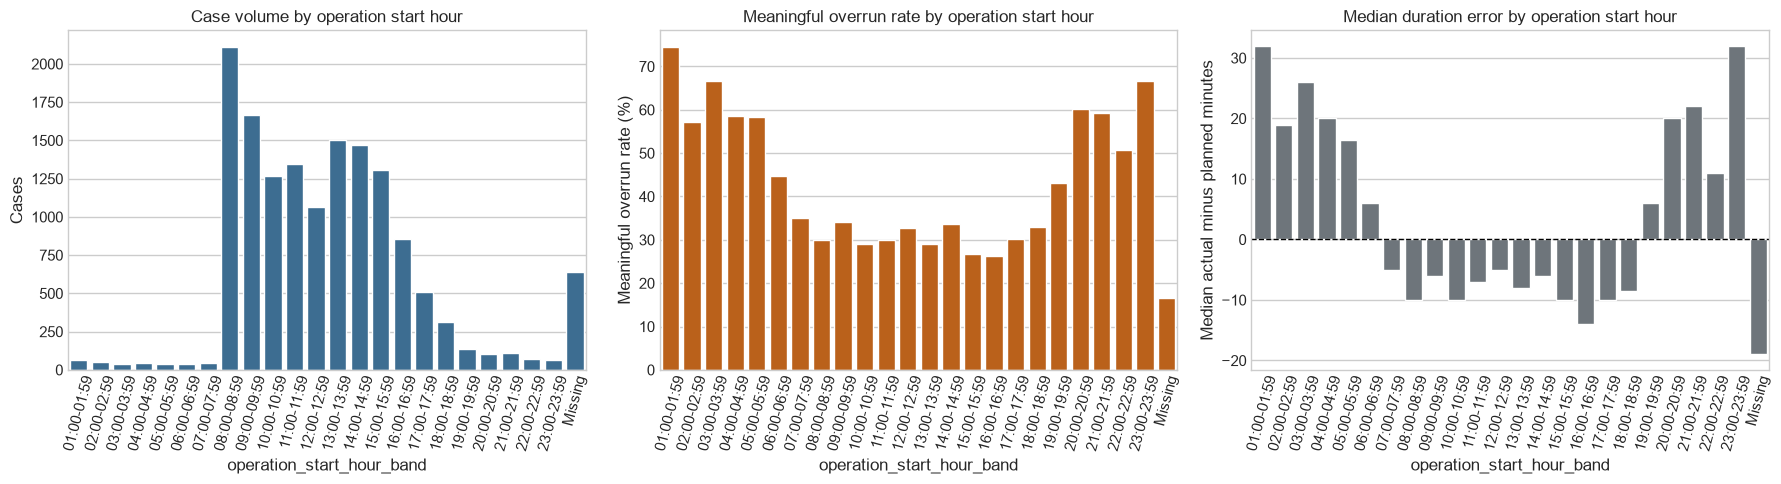

In [76]:
plot_df = start_hour_bottleneck_summary.sort_values("operation_start_hour_band")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=plot_df, x="operation_start_hour_band", y="cases", ax=axes[0], color=plot_color)
axes[0].set_title("Case volume by operation start hour")
axes[0].set_ylabel("Cases")
axes[0].tick_params(axis="x", rotation=75)

sns.barplot(data=plot_df, x="operation_start_hour_band", y="meaningful_overrun_rate", ax=axes[1], color=highlight_color)
axes[1].set_title("Meaningful overrun rate by operation start hour")
axes[1].set_ylabel("Meaningful overrun rate (%)")
axes[1].tick_params(axis="x", rotation=75)

sns.barplot(data=plot_df, x="operation_start_hour_band", y="median_duration_error", ax=axes[2], color=neutral_color)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Median duration error by operation start hour")
axes[2].set_ylabel("Median actual minus planned minutes")
axes[2].tick_params(axis="x", rotation=75)

plt.tight_layout()


**Result interpretation:** Start-hour summaries assess whether scheduling performance varies by time of day. Periods with high case volume, high meaningful overrun rate, or positive median duration error are candidates for further review by theatre area, room, procedure group, and specialty.


### 10.8 Theatre and start-time bottleneck checks

This check combines time of day with theatre location. It helps identify whether possible bottlenecks are concentrated in specific theatre areas or exact rooms at particular start-hour bands.


In [77]:
time_location_columns = available_columns(
    bottleneck_eda_df,
    ["theatre_area", "TheatreRoom", "theatre_room_prefix"],
)

for column in time_location_columns:
    print(f"Bottleneck summary by {column}")
    display(bottleneck_summary_by_category(bottleneck_eda_df, column, min_cases=30, top_n=15))

location_hour_summary = (
    bottleneck_eda_df
    .assign(
        theatre_area=bottleneck_eda_df.get("theatre_area", pd.Series(index=bottleneck_eda_df.index, dtype="object")).astype("string").fillna("Missing"),
        operation_start_hour_band=bottleneck_eda_df["operation_start_hour_band"].astype("string").fillna("Missing"),
    )
    .groupby(["theatre_area", "operation_start_hour_band"], dropna=False)
    .agg(
        cases=(target_column, "size"),
        meaningful_overrun_rate=("meaningful_overrun_flag", "mean"),
        median_duration_error=("duration_error_mins", "median"),
        median_operation_length=(target_column, "median"),
    )
    .reset_index()
)

location_hour_summary["meaningful_overrun_rate"] = (location_hour_summary["meaningful_overrun_rate"] * 100).round(2)
location_hour_summary = location_hour_summary[location_hour_summary["cases"] >= 20]
location_hour_summary.sort_values(["meaningful_overrun_rate", "cases"], ascending=False).head(20)


Bottleneck summary by theatre_area


,theatre_area,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
4,GYNAE,1132,1117,72.00,75.84,60.00,14.00,57.27,14.00,0.00,98.67
5,HYBRID THEATRE,216,216,167.50,184.27,120.00,12.00,47.69,12.00,0.00,100.00
7,IR LAB,1915,1888,56.00,70.18,60.00,1.00,39.06,1.00,0.00,98.59
0,BRUNEL,7846,7801,100.00,127.59,90.00,-7.00,36.39,0.00,7.00,99.43
1,CATH LAB,524,520,61.00,69.18,64.00,-6.00,10.17,0.00,6.00,99.24
2,COTSWOLD,808,808,42.00,64.97,60.00,-13.00,11.63,0.00,13.00,100.00
6,IF FLUORO,135,134,26.00,31.81,30.00,-7.00,17.04,0.00,7.00,99.26
9,PACING ROOM,160,157,39.00,38.76,45.00,-8.00,15.48,0.00,8.00,98.12
10,PARKVIEW,535,0,73.00,77.70,90.00,-19.00,16.14,0.00,19.00,0.00
11,PLASTIC MINOR,1629,1624,30.00,35.13,60.00,-30.00,4.76,0.00,30.00,99.69


Bottleneck summary by TheatreRoom


,TheatreRoom,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
2,BRUNEL TH 03,520,515,120.50,135.99,60.00,50.00,82.39,50.00,0.00,99.04
3,BRUNEL TH 04,332,328,138.00,178.76,60.00,48.50,72.05,48.50,0.00,98.80
5,BRUNEL TH 06,516,511,116.00,137.57,60.00,40.00,67.00,40.00,0.00,99.03
1,BRUNEL TH 02,469,466,82.00,104.00,60.00,25.00,60.54,25.00,0.00,99.36
4,BRUNEL TH 05,706,696,81.00,101.29,60.00,22.00,61.13,22.00,0.00,98.58
29,GYNAE TH 02,621,612,72.00,76.02,60.00,16.00,59.85,16.00,0.00,98.55
28,GYNAE TH 01,496,491,72.00,75.74,60.00,12.00,54.72,12.00,0.00,98.99
31,HYBRID THEATRE,216,216,167.50,184.27,120.00,12.00,47.69,12.00,0.00,100.00
0,BRUNEL TH 01,313,312,87.00,103.77,60.00,6.50,44.84,6.50,0.00,99.68
35,IR LAB 3,317,315,78.00,92.47,60.00,5.00,45.25,5.00,0.00,99.37


Bottleneck summary by theatre_room_prefix


,theatre_room_prefix,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
3,HYBRID THEATRE,216,216,167.50,184.27,120.00,12.00,47.69,12.00,0.00,100.00
4,IR LAB,1915,1888,56.00,70.18,60.00,1.00,39.06,1.00,0.00,98.59
0,CATH LAB,524,520,61.00,69.18,64.00,-6.00,10.17,0.00,6.00,99.24
2,FLUORO,135,134,26.00,31.81,30.00,-7.00,17.04,0.00,7.00,99.26
5,MINOR,1629,1624,30.00,35.13,60.00,-30.00,4.76,0.00,30.00,99.69
7,PACING ROOM,160,157,39.00,38.76,45.00,-8.00,15.48,0.00,8.00,98.12
8,TH,10321,9726,85.00,114.43,75.00,-5.00,35.43,0.00,5.00,94.24


,theatre_area,operation_start_hour_band,cases,meaningful_overrun_rate,median_duration_error,median_operation_length
51,GYNAE,01:00-01:59,30,80.00,32.00,78.00
0,BRUNEL,00:00-00:59,30,75.00,46.50,100.00
20,BRUNEL,20:00-20:59,56,72.73,30.00,96.50
2,BRUNEL,02:00-02:59,26,69.23,86.00,135.50
1,BRUNEL,01:00-01:59,34,68.75,33.00,98.50
63,GYNAE,13:00-13:59,82,65.38,15.00,75.00
53,GYNAE,03:00-03:59,22,64.71,15.00,66.50
58,GYNAE,08:00-08:59,109,64.08,17.00,79.00
23,BRUNEL,23:00-23:59,44,63.64,56.50,129.50
54,GYNAE,04:00-04:59,25,62.50,20.50,63.00


**Result interpretation:** Combining theatre location with start-hour band provides a more operational view of potential bottlenecks. Area-time combinations with adequate volume and high meaningful overrun rate or positive median duration error should be prioritised for deeper review.


### 10.8.1 Theatre-room pressure profile

This step ranks exact theatre rooms using operational pressure indicators. True utilisation would require the planned staffed session time for each room, which is not fully available here. Therefore this analysis uses practical proxies: case volume, total theatre occupancy minutes, median theatre occupancy, median duration error, and meaningful overrun rate.

This makes the comparison fairer than looking only at overrun counts. A room with many cases will naturally have more overruns, so the rate and median error are considered alongside workload.


In [78]:
if "TheatreRoom" in bottleneck_eda_df.columns:
    room_pressure_summary = (
        bottleneck_eda_df
        .assign(TheatreRoom=bottleneck_eda_df["TheatreRoom"].astype("string").fillna("Missing"))
        .groupby("TheatreRoom", dropna=False)
        .agg(
            cases=(target_column, "size"),
            total_theatre_occupancy_mins=("theatre_occupancy_mins", "sum"),
            median_theatre_occupancy_mins=("theatre_occupancy_mins", "median"),
            median_operation_length=(target_column, "median"),
            median_duration_error=("duration_error_mins", "median"),
            meaningful_overrun_rate=("meaningful_overrun_flag", "mean"),
            meaningful_underrun_rate=("meaningful_underrun_flag", "mean"),
        )
        .reset_index()
    )

    room_pressure_summary["meaningful_overrun_rate"] = (
        room_pressure_summary["meaningful_overrun_rate"] * 100
    ).round(2)
    room_pressure_summary["meaningful_underrun_rate"] = (
        room_pressure_summary["meaningful_underrun_rate"] * 100
    ).round(2)
    room_pressure_summary = room_pressure_summary[room_pressure_summary["cases"] >= 30]
    room_pressure_summary.sort_values(
        ["total_theatre_occupancy_mins", "meaningful_overrun_rate"],
        ascending=False,
    ).head(20)


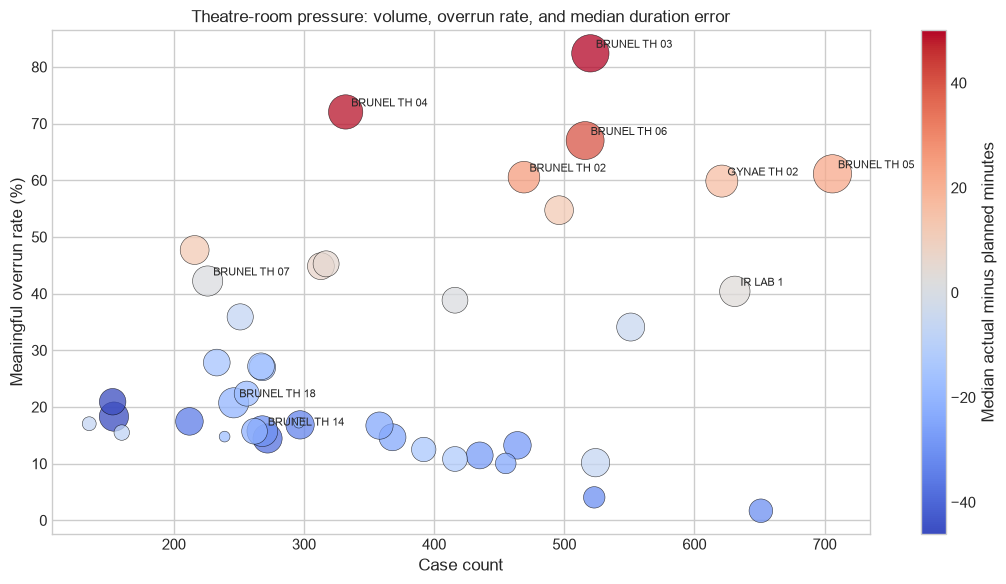

In [79]:
if "room_pressure_summary" in globals() and not room_pressure_summary.empty:
    plot_room_pressure = room_pressure_summary.dropna(
        subset=["cases", "meaningful_overrun_rate", "total_theatre_occupancy_mins", "median_duration_error"]
    ).copy()

    fig, ax = plt.subplots(figsize=(11, 6))
    marker_size = plot_room_pressure["total_theatre_occupancy_mins"].rank(pct=True) * 700 + 60
    scatter = sns.scatterplot(
        data=plot_room_pressure,
        x="cases",
        y="meaningful_overrun_rate",
        size="total_theatre_occupancy_mins",
        hue="median_duration_error",
        palette="coolwarm",
        sizes=(60, 760),
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
        ax=ax,
        legend=False,
    )

    label_df = plot_room_pressure.sort_values(
        ["total_theatre_occupancy_mins", "meaningful_overrun_rate"],
        ascending=False,
    ).head(10)
    for _, row in label_df.iterrows():
        ax.annotate(
            str(row["TheatreRoom"])[:18],
            (row["cases"], row["meaningful_overrun_rate"]),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points",
        )

    ax.set_title("Theatre-room pressure: volume, overrun rate, and median duration error")
    ax.set_xlabel("Case count")
    ax.set_ylabel("Meaningful overrun rate (%)")
    norm = plt.Normalize(plot_room_pressure["median_duration_error"].min(), plot_room_pressure["median_duration_error"].max())
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
    sm.set_array([])
    colorbar = fig.colorbar(sm, ax=ax)
    colorbar.set_label("Median actual minus planned minutes")
    plt.tight_layout()


**Result interpretation:** The room-pressure view combines workload and reliability. Rooms in the upper-right of the scatter plot have both high activity and high meaningful overrun rates, making them stronger candidates for scheduling review than rooms with high overrun rates but very low volume. Marker size reflects total occupied theatre time, so large markers indicate rooms consuming more operational capacity. This is a proxy for utilisation, not a formal utilisation percentage, because staffed session capacity is not available in the dataset.


### 10.9 Procedure, specialty, staff, and patient-factor checks

This check compares delays across operation type, specialty, staff-related codes, anaesthetic type, ASA score, age group, and sex. These are possible predictors, but they should not be interpreted as direct causes. For example, a consultant or surgeon code associated with longer operations may simply handle more complex cases.


In [80]:
bottleneck_eda_df["age_group"] = pd.cut(
    bottleneck_eda_df["age_at_operation"],
    bins=[0, 18, 35, 50, 65, 80, 125],
    labels=["0-17", "18-34", "35-49", "50-64", "65-79", "80+"],
    include_lowest=True,
)

bottleneck_factor_columns = available_columns(
    bottleneck_eda_df,
    [
        "procedure_code_group",
        "ProcedureDescription",
        "session_specialty",
        "session_consultant",
        "listing_cons_code",
        "theat_surg_1_national_code",
        "theat_anae_1_national_code",
        "anaesthetic_desc",
        "ASAScore",
        "age_group",
        "sex_national_code",
        "admission_type_label",
        "intended_management_label",
        "priority_level_label",
        "session_list_type",
    ],
)

for column in bottleneck_factor_columns:
    print(f"Bottleneck summary by {column}")
    display(bottleneck_summary_by_category(bottleneck_eda_df, column, min_cases=30, top_n=12))


Bottleneck summary by procedure_code_group


,procedure_code_group,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
133,Y5,81,78,142.00,145.65,60.00,82.00,82.50,82.00,0.00,96.30
50,L5,36,36,275.50,266.42,150.00,78.00,77.78,78.00,0.00,100.00
114,W2,503,494,126.00,150.97,90.00,42.00,66.67,42.00,0.00,98.21
144,Z7,184,183,120.00,140.57,60.00,39.00,70.49,39.00,0.00,99.46
54,L9,98,96,74.00,92.55,30.00,38.00,73.96,38.00,0.00,97.96
4,A4,104,103,116.00,133.26,60.00,37.00,65.05,37.00,0.00,99.04
122,X0,61,60,125.00,138.66,90.00,37.00,72.13,37.00,0.00,98.36
116,W4,219,219,130.00,145.28,120.00,36.00,58.45,36.00,0.00,100.00
108,V3,105,105,221.00,232.78,180.00,35.00,55.24,35.00,0.00,100.00
51,L6,65,65,182.00,213.37,180.00,34.00,60.00,34.00,0.00,100.00


Bottleneck summary by ProcedureDescription


,ProcedureDescription,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
389,Laparotomy approach NEC,68,67,155.00,159.76,60.00,95.00,91.04,95.00,0.00,98.53
620,Percutaneous transluminal embolisation of cerebral artery,42,42,142.50,149.38,60.00,79.50,95.24,79.50,0.00,100.00
681,Primary prosthetic replacement of head of femur NEC,88,88,121.00,122.69,45.00,75.00,96.59,75.00,0.00,100.00
665,Primary microdiscectomy of lumbar intervertebral disc,39,39,169.00,185.56,120.00,67.00,64.10,67.00,0.00,100.00
668,Primary open reduction of fracture of ankle and extramedullary fixation NEC,67,67,131.00,150.25,60.00,63.00,92.54,63.00,0.00,100.00
596,Percutaneous aspiration thromboembolectomy,44,42,90.00,101.69,30.00,60.00,97.62,60.00,0.00,95.45
251,Evacuation of subdural haematoma,57,57,118.00,132.79,60.00,57.00,80.70,57.00,0.00,100.00
684,Primary repair of peripheral nerve NEC,34,34,126.50,130.41,60.00,55.00,58.82,55.00,0.00,100.00
989,Unspecified primary open reduction of fracture of bone and extramedullary fixation,103,103,187.00,207.60,150.00,51.00,64.08,51.00,0.00,100.00
108,Closed reduction of fracture of bone and fixation using nail or screw,128,126,135.00,159.44,90.00,46.00,88.10,46.00,0.00,98.44


Bottleneck summary by session_specialty


...

,intended_management_label,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
4,not_applicable,169,168,73.00,76.47,60.00,12.00,53.85,12.00,0.00,99.41
2,inpatient,7599,7493,103.00,134.95,60.00,8.00,46.72,8.00,0.00,98.61
1,day_case,7108,6577,45.00,58.60,60.00,-20.00,14.89,0.00,20.00,92.53
5,regular_day_attender,31,30,207.00,229.29,240.00,-7.00,45.16,0.00,7.00,96.77


Bottleneck summary by priority_level_label


,priority_level_label,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
0,Missing,8563,8343,75.00,102.76,60.00,5.00,43.96,5.00,0.00,97.43
1,high_priority,3714,3501,52.00,88.85,80.00,-24.00,14.82,0.00,24.00,94.26
3,medium_priority,1521,1457,63.00,95.15,90.00,-22.00,15.92,0.00,22.00,95.79
4,routine_or_lower_priority,1119,977,81.00,95.08,120.00,-23.50,14.25,0.00,23.50,87.31


Bottleneck summary by session_list_type


,session_list_type,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
4,Missing,3317,3271,72.00,93.47,60.00,8.00,47.18,8.00,0.00,98.61
1,3SD,2912,2885,112.00,141.75,120.00,-23.00,24.23,0.00,23.00,99.07
0,2SD,3775,3309,85.00,111.40,90.00,-9.00,33.29,0.00,9.00,87.66
2,AM,2611,2568,44.00,63.06,60.00,-13.00,24.55,0.00,13.00,98.35
3,EVE,70,70,37.50,51.14,60.00,-30.00,8.57,0.00,30.00,100.00
5,PM,1913,1862,45.00,60.02,60.00,-13.00,24.99,0.00,13.00,97.33
6,PM/EVE,320,314,70.00,107.44,90.00,-24.00,15.36,0.00,24.00,98.12


In [81]:
combined_checks = [
    ("theatre_area", "procedure_code_group"),
    ("theatre_area", "session_specialty"),
    ("procedure_code_group", "anaesthetic_desc"),
    ("procedure_code_group", "ASAScore"),
    ("session_specialty", "anaesthetic_desc"),
    ("TheatreRoom", "procedure_code_group"),
]

for left, right in combined_checks:
    if left not in bottleneck_eda_df.columns or right not in bottleneck_eda_df.columns:
        continue

    temp = bottleneck_eda_df.copy()
    temp[left] = temp[left].astype("string").fillna("Missing")
    temp[right] = temp[right].astype("string").fillna("Missing")
    temp["combined_group"] = temp[left] + " | " + temp[right]

    print(f"Combined bottleneck summary: {left} + {right}")
    display(bottleneck_summary_by_category(temp, "combined_group", min_cases=30, top_n=12))


Combined bottleneck summary: theatre_area + procedure_code_group


,combined_group,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
118,BRUNEL | Y5,57,56,168.50,176.29,60.00,108.50,98.21,108.50,0.00,98.25
182,HYBRID THEATRE | L6,34,34,296.00,282.24,180.00,67.00,61.76,67.00,0.00,100.00
244,IR LAB | L9,72,70,84.00,91.67,30.00,49.50,82.86,49.50,0.00,97.22
29,BRUNEL | H3,40,40,326.00,331.15,180.00,47.50,60.00,47.50,0.00,100.00
99,BRUNEL | W2,496,494,126.50,151.95,90.00,42.50,67.21,42.50,0.00,99.60
82,BRUNEL | T3,74,72,119.00,136.31,60.00,41.50,69.44,41.50,0.00,97.30
127,BRUNEL | Z7,183,182,120.50,141.09,60.00,39.50,70.33,39.50,0.00,99.45
183,HYBRID THEATRE | L7,30,30,161.00,200.73,90.00,39.00,63.33,39.00,0.00,100.00
76,BRUNEL | S5,352,350,87.00,107.17,52.50,38.00,70.69,38.00,0.00,99.43
107,BRUNEL | X0,51,50,127.00,143.61,90.00,38.00,76.47,38.00,0.00,98.04


Combined bottleneck summary: theatre_area + session_specialty


,combined_group,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
30,BRUNEL | TH 6 A Consultant (Non Specific) Emergency,505,500,117.00,138.71,60.00,42.00,67.95,42.00,0.00,99.01
157,BRUNEL | TH3 A Consultant (Non Specific) Emergency,42,40,93.00,100.67,60.00,34.00,65.00,34.00,0.00,95.24
29,BRUNEL | TH 5 A Consultant (Non Specific) Emergency,686,676,82.00,101.37,60.00,24.00,62.05,24.00,0.00,98.54
217,GYNAE | Obs&Gynae,1117,1102,72.00,75.89,60.00,14.00,57.13,14.00,0.00,98.66
236,HYBRID THEATRE | Vascular Surgery,191,191,171.00,185.04,150.00,10.00,46.07,10.00,0.00,100.00
7,BRUNEL | T&O,2095,2087,124.00,140.83,120.00,6.00,45.84,6.00,0.00,99.62
206,BRUNEL | Vascular Surgery,168,166,101.00,150.04,90.00,2.00,43.11,2.00,0.00,98.81
242,IR LAB | Radiology,1893,1866,55.00,69.54,60.00,1.00,39.48,1.00,0.00,98.57
2,BRUNEL | Colo-Rectal,50,50,132.00,161.42,120.00,-20.50,30.00,0.00,20.50,100.00
0,BRUNEL | Breast,126,125,88.00,96.62,120.00,-26.00,6.40,0.00,26.00,99.21


Combined bottleneck summary: procedure_code_group + anaesthetic_desc


...

,combined_group,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
549,Y5 | 3.0,41,39,149.50,156.45,60.00,89.50,87.50,89.50,0.00,95.12
363,S5 | 4.0,38,38,115.00,154.42,45.00,71.50,89.47,71.50,0.00,100.00
473,W2 | 4.0,40,40,127.50,171.32,90.00,54.50,80.00,54.50,0.00,100.00
211,L9 | 3.0,43,43,90.00,102.60,30.00,52.00,86.05,52.00,0.00,100.00
474,W2 | Missing,65,64,129.50,154.61,60.00,50.00,78.12,50.00,0.00,98.46
472,W2 | 3.0,124,121,146.00,183.84,90.00,46.00,74.80,46.00,0.00,97.58
588,Z7 | 3.0,58,58,118.50,136.79,60.00,44.00,77.59,44.00,0.00,100.00
195,L6 | 3.0,38,38,199.00,229.03,165.00,41.50,68.42,41.50,0.00,100.00
587,Z7 | 2.0,51,50,119.50,149.08,60.00,40.50,64.00,40.50,0.00,98.04
103,H0 | 2.0,59,59,116.00,144.56,60.00,39.00,74.58,39.00,0.00,100.00


Combined bottleneck summary: session_specialty + anaesthetic_desc


,combined_group,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
112,TH 6 A Consultant (Non Specific) Emergency | GA,474,470,121.00,144.10,60.00,50.00,69.55,50.00,0.00,99.16
64,T&O | GA and Regional,136,132,129.00,146.82,90.00,46.00,66.67,46.00,0.00,97.06
316,TH3 A Consultant (Non Specific) Emergency | GA,41,39,97.00,102.26,60.00,39.00,66.67,39.00,0.00,95.12
49,Plastic surgery | GA and Regional,140,140,87.50,112.48,60.00,27.00,66.42,27.00,0.00,100.00
104,TH 5 A Consultant (Non Specific) Emergency | GA,618,608,86.00,103.77,60.00,25.00,62.58,25.00,0.00,98.38
56,Radiology | GA,352,345,96.00,112.51,60.00,20.00,54.29,20.00,0.00,98.01
39,Obs&Gynae | Missing,448,439,73.00,76.95,60.00,15.00,57.59,15.00,0.00,97.99
66,T&O | Missing,126,122,115.50,129.48,60.00,14.00,49.21,14.00,0.00,96.83
42,Obs&Gynae | Regional Only,50,49,67.00,71.35,60.00,13.50,57.50,13.50,0.00,98.00
40,Obs&Gynae | Neuraxial Block,567,562,72.00,74.43,60.00,12.00,53.85,12.00,0.00,99.12


Combined bottleneck summary: TheatreRoom + procedure_code_group


,combined_group,cases,valid_time_rows,median_operation_length,mean_operation_length,median_expected_duration,median_duration_error,meaningful_overrun_rate,median_overrun_minutes,median_underrun_minutes,valid_time_pct
279,BRUNEL TH 06 | V0,39,39,243.00,253.46,120.00,141.00,87.18,141.00,0.00,100.00
234,BRUNEL TH 05 | Y5,49,49,171.00,176.82,60.00,111.00,97.96,111.00,0.00,100.00
281,BRUNEL TH 06 | V3,34,34,182.50,186.82,60.00,100.50,79.41,100.50,0.00,100.00
280,BRUNEL TH 06 | V2,49,48,215.50,208.29,120.00,74.00,83.33,74.00,0.00,97.96
106,BRUNEL TH 03 | W4,60,60,120.50,125.55,45.00,70.00,98.33,70.00,0.00,100.00
1082,HYBRID THEATRE | L6,34,34,296.00,282.24,180.00,67.00,61.76,67.00,0.00,100.00
150,BRUNEL TH 04 | W2,111,109,183.00,215.13,90.00,60.00,79.82,60.00,0.00,98.20
94,BRUNEL TH 03 | S5,34,34,118.00,144.41,30.00,59.50,91.18,59.50,0.00,100.00
246,BRUNEL TH 06 | A4,62,62,126.00,141.27,60.00,58.50,80.65,58.50,0.00,100.00
216,BRUNEL TH 05 | T4,30,29,123.50,128.67,60.00,56.50,86.67,56.50,0.00,96.67


**Result interpretation:** These summaries extend bottleneck analysis across procedure, specialty, staff-code, anaesthetic, ASA, age, sex, admission, and priority factors. Staff and consultant fields should be interpreted cautiously because observed differences may reflect case allocation, complexity, or specialty mix rather than individual performance.


### 10.10 Visual bottleneck relationship checks

The previous tables show detailed numbers, but visualisations make bottleneck patterns easier to see. This section adds two-variable heatmaps and a three-variable 3D view.

The heatmaps answer questions such as:

- Which theatre areas have more overruns at different start hours?
- Which procedure groups have larger duration errors in different theatre areas?
- Does anaesthetic type and ASA score combine with longer operation time?

The 3D plot gives a compact view of three operational dimensions at once: start hour, theatre area, and median duration error. Marker size shows case volume and colour shows meaningful overrun rate.


In [82]:
def pivot_metric_table(df, row, column, metric, min_cases=20, aggfunc="median", top_rows=12, top_columns=12):
    temp = df[[row, column, metric]].copy()
    temp[row] = temp[row].astype("string").fillna("Missing")
    temp[column] = temp[column].astype("string").fillna("Missing")

    valid_groups = (
        temp.groupby([row, column], dropna=False)
        .size()
        .reset_index(name="cases")
        .query("cases >= @min_cases")
    )

    temp = temp.merge(valid_groups[[row, column]], on=[row, column], how="inner")

    top_row_values = temp[row].value_counts().head(top_rows).index
    top_column_values = temp[column].value_counts().head(top_columns).index
    temp = temp[temp[row].isin(top_row_values) & temp[column].isin(top_column_values)]

    return temp.pivot_table(
        index=row,
        columns=column,
        values=metric,
        aggfunc=aggfunc,
    )



def plot_heatmap(table, title, colorbar_label, center_zero=False, figsize=(12, 7)):
    plot_table = table.apply(pd.to_numeric, errors="coerce").astype(float)

    fig, ax = plt.subplots(figsize=figsize)
    cmap = "coolwarm" if center_zero else "YlOrRd"

    heatmap_kwargs = {
        "data": plot_table,
        "ax": ax,
        "cmap": cmap,
        "annot": True,
        "fmt": ".1f",
        "linewidths": 0.4,
        "linecolor": "white",
        "cbar_kws": {"label": colorbar_label},
    }

    if center_zero:
        finite_values = plot_table.to_numpy(dtype=float)
        finite_values = finite_values[~pd.isna(finite_values)]
        limit = max(abs(finite_values).max(), 1) if len(finite_values) else 1
        heatmap_kwargs.update({"vmin": -limit, "vmax": limit, "center": 0})

    sns.heatmap(**heatmap_kwargs)
    ax.set_title(title)
    ax.set_xlabel(plot_table.columns.name or "")
    ax.set_ylabel(plot_table.index.name or "")
    ax.tick_params(axis="x", rotation=75)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()

    return ax


<Axes: title={'center': 'Meaningful overrun rate by theatre area and start hour'}, xlabel='operation_start_hour_band', ylabel='theatre_area'>

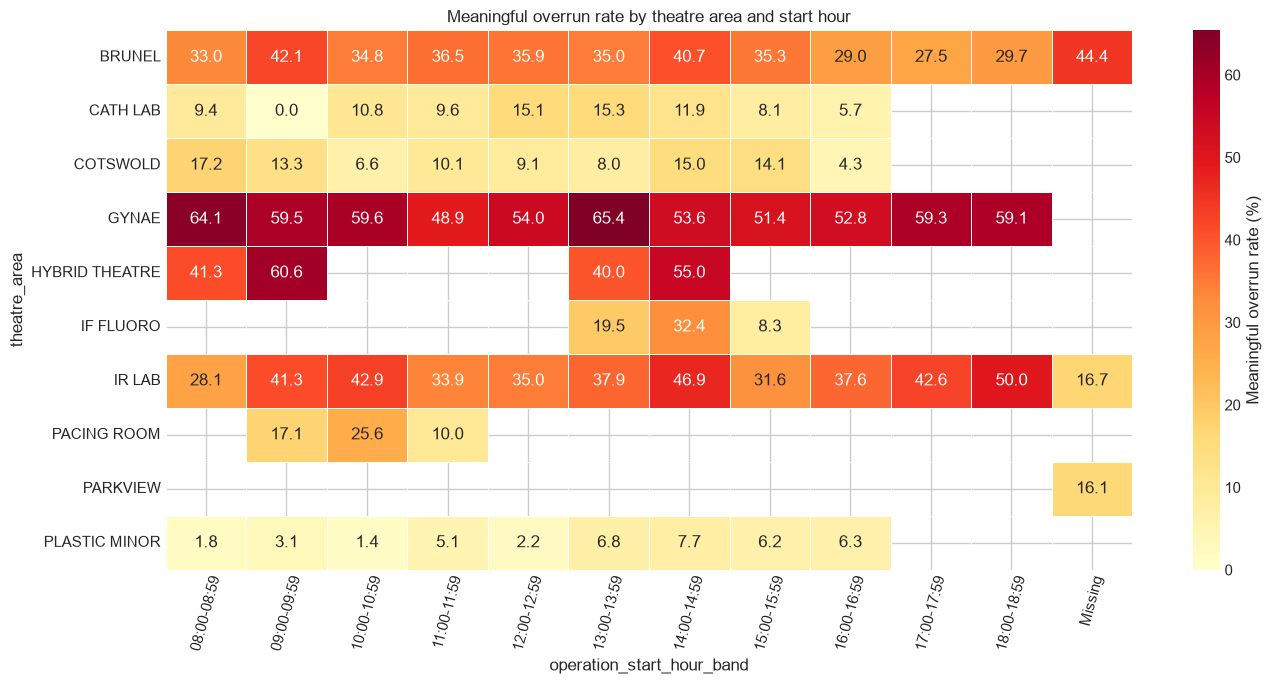

In [83]:
theatre_hour_overrun_table = pivot_metric_table(
    bottleneck_eda_df,
    row="theatre_area",
    column="operation_start_hour_band",
    metric="meaningful_overrun_flag",
    min_cases=20,
    aggfunc="mean",
    top_rows=10,
    top_columns=12,
) * 100

plot_heatmap(
    theatre_hour_overrun_table,
    title="Meaningful overrun rate by theatre area and start hour",
    colorbar_label="Meaningful overrun rate (%)",
    center_zero=False,
    figsize=(14, 7),
)


<Axes: title={'center': 'Median duration error by procedure group and theatre area'}, xlabel='theatre_area', ylabel='procedure_code_group'>

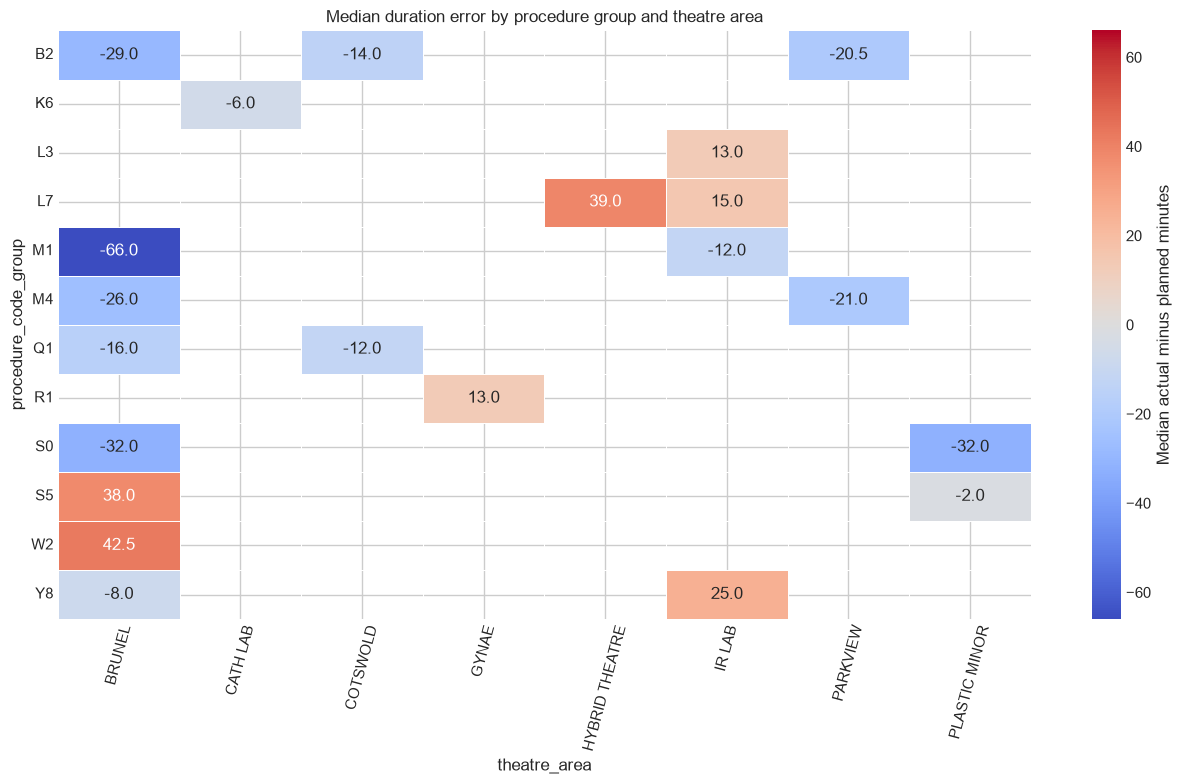

In [84]:
procedure_area_error_table = pivot_metric_table(
    bottleneck_eda_df,
    row="procedure_code_group",
    column="theatre_area",
    metric="duration_error_mins",
    min_cases=30,
    aggfunc="median",
    top_rows=12,
    top_columns=10,
)

plot_heatmap(
    procedure_area_error_table,
    title="Median duration error by procedure group and theatre area",
    colorbar_label="Median actual minus planned minutes",
    center_zero=True,
    figsize=(13, 8),
)


<Axes: title={'center': 'Median operation length by anaesthetic type and ASA score'}, xlabel='ASAScore', ylabel='anaesthetic_desc'>

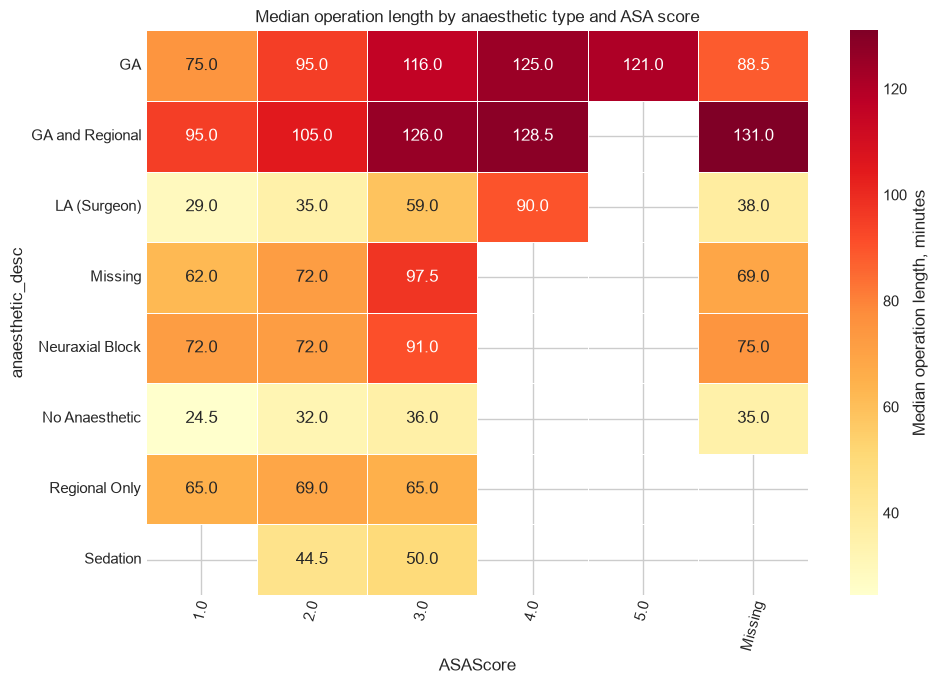

In [85]:
anaesthetic_asa_duration_table = pivot_metric_table(
    bottleneck_eda_df,
    row="anaesthetic_desc",
    column="ASAScore",
    metric="operation_length_mins",
    min_cases=20,
    aggfunc="median",
    top_rows=10,
    top_columns=8,
)

plot_heatmap(
    anaesthetic_asa_duration_table,
    title="Median operation length by anaesthetic type and ASA score",
    colorbar_label="Median operation length, minutes",
    center_zero=False,
    figsize=(10, 7),
)


C:\Users\Alaa\AppData\Local\Temp\ipykernel_42668\1525429471.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


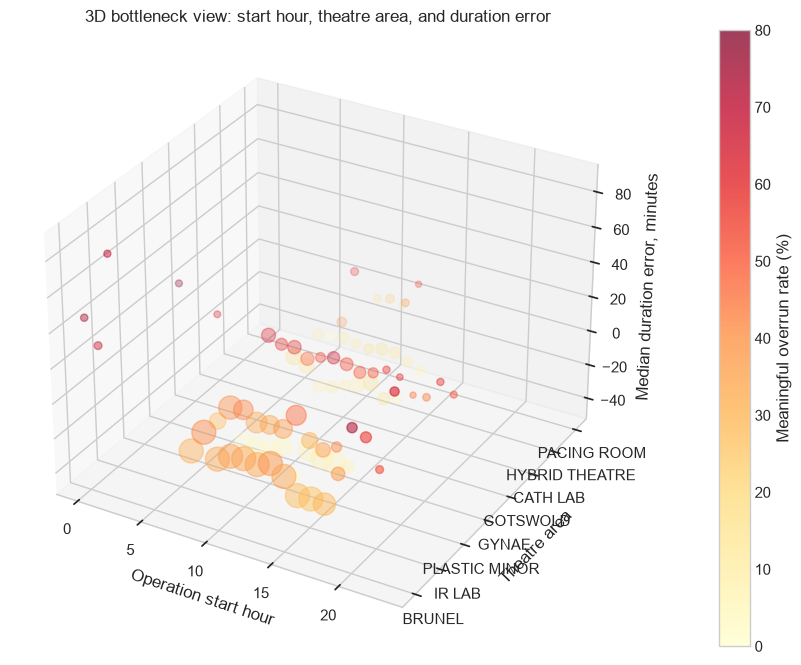

In [86]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

three_d_df = (
    bottleneck_eda_df
    .dropna(subset=["operation_start_hour", "duration_error_mins", "theatre_area"])
    .assign(theatre_area=lambda df: df["theatre_area"].astype("string").fillna("Missing"))
)

top_areas = three_d_df["theatre_area"].value_counts().head(8).index
three_d_df = three_d_df[three_d_df["theatre_area"].isin(top_areas)]

three_d_summary = (
    three_d_df
    .groupby(["theatre_area", "operation_start_hour"], dropna=False)
    .agg(
        cases=(target_column, "size"),
        median_duration_error=("duration_error_mins", "median"),
        meaningful_overrun_rate=("meaningful_overrun_flag", "mean"),
    )
    .reset_index()
)
three_d_summary = three_d_summary[three_d_summary["cases"] >= 20]
three_d_summary["area_index"] = three_d_summary["theatre_area"].map(
    {area: idx for idx, area in enumerate(top_areas)}
)
three_d_summary["meaningful_overrun_rate_pct"] = three_d_summary["meaningful_overrun_rate"] * 100

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    three_d_summary["operation_start_hour"],
    three_d_summary["area_index"],
    three_d_summary["median_duration_error"],
    s=three_d_summary["cases"].clip(20, 300),
    c=three_d_summary["meaningful_overrun_rate_pct"],
    cmap="YlOrRd",
    alpha=0.75,
)

ax.set_title("3D bottleneck view: start hour, theatre area, and duration error")
ax.set_xlabel("Operation start hour")
ax.set_ylabel("Theatre area")
ax.set_zlabel("Median duration error, minutes")
ax.set_yticks(range(len(top_areas)))
ax.set_yticklabels(top_areas)

colorbar = fig.colorbar(scatter, ax=ax, fraction=0.035, pad=0.1)
colorbar.set_label("Meaningful overrun rate (%)")

plt.tight_layout()


**Result interpretation:** Heatmaps and the 3D plot show multi-variable bottleneck patterns more clearly than tables. They identify combinations of theatre area, start hour, procedure group, anaesthetic type, ASA score, and duration error that may warrant targeted investigation.


### 10.11 Deeper visual relationship EDA

This section adds more visual checks for the main scheduling questions. The aim is to see whether operation duration, overrun size, and duration error are associated with combinations of time, theatre, procedure type, specialty, consultant/staff codes, anaesthetic type, ASA score, age, and sex.

These plots should be interpreted as association checks. They help identify candidate bottlenecks and modelling features, but they do not prove that a consultant, room, or procedure group caused a delay.


In [87]:
def category_bottleneck_summary(df, category, min_cases=20, top_n=30):
    temp = df.copy()
    temp[category] = temp[category].astype("string").fillna("Missing")

    summary = temp.groupby(category, dropna=False).agg(
        cases=(target_column, "size"),
        median_operation_length=(target_column, "median"),
        median_duration_error=("duration_error_mins", "median"),
        meaningful_overrun_rate=("meaningful_overrun_flag", "mean"),
        median_overrun_minutes=("overrun_minutes", "median"),
        total_overrun_minutes=("overrun_minutes", "sum"),
        median_underrun_minutes=("underrun_minutes", "median"),
        total_underrun_minutes=("underrun_minutes", "sum"),
    ).reset_index()

    summary["meaningful_overrun_rate"] = (summary["meaningful_overrun_rate"] * 100).round(2)
    summary = summary[summary["cases"] >= min_cases]
    return summary.sort_values(["meaningful_overrun_rate", "cases"], ascending=False).head(top_n)


def plot_category_scatter(summary, label_column, title):
    if summary.empty:
        print(f"No data available for {title}")
        return

    plot_summary = summary.dropna(subset=["cases", "meaningful_overrun_rate", "median_duration_error"]).copy()
    if plot_summary.empty:
        print(f"No valid plotting data available for {title}")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    marker_size = plot_summary["total_overrun_minutes"].fillna(0).rank(pct=True) * 700 + 60
    scatter = ax.scatter(
        plot_summary["cases"],
        plot_summary["meaningful_overrun_rate"],
        s=marker_size,
        c=plot_summary["median_duration_error"],
        cmap="coolwarm",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
    )

    label_df = plot_summary.sort_values(
        ["meaningful_overrun_rate", "cases"],
        ascending=False,
    ).head(8)
    for _, row in label_df.iterrows():
        ax.annotate(
            str(row[label_column])[:22],
            (row["cases"], row["meaningful_overrun_rate"]),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points",
        )

    ax.set_title(title)
    ax.set_xlabel("Case count")
    ax.set_ylabel("Meaningful overrun rate (%)")
    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label("Median actual minus planned minutes")
    plt.tight_layout()


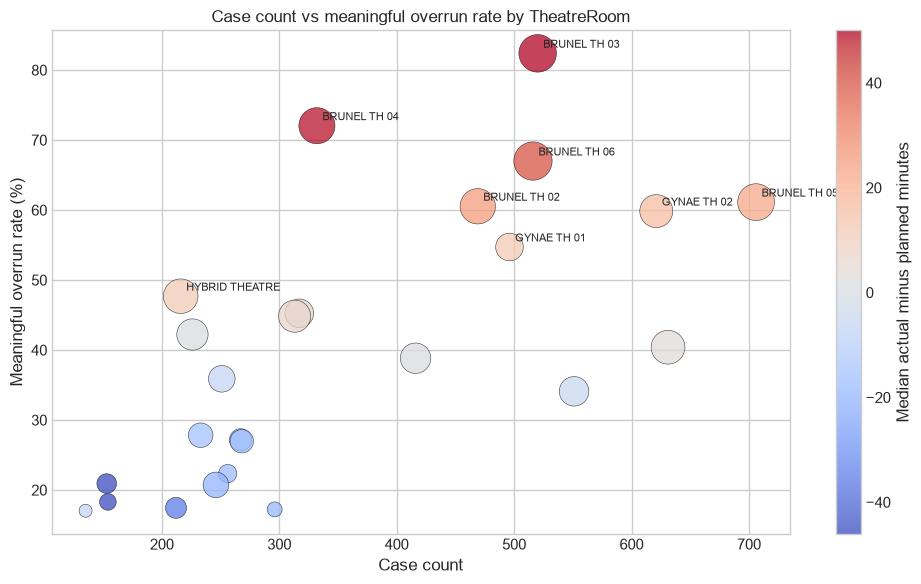

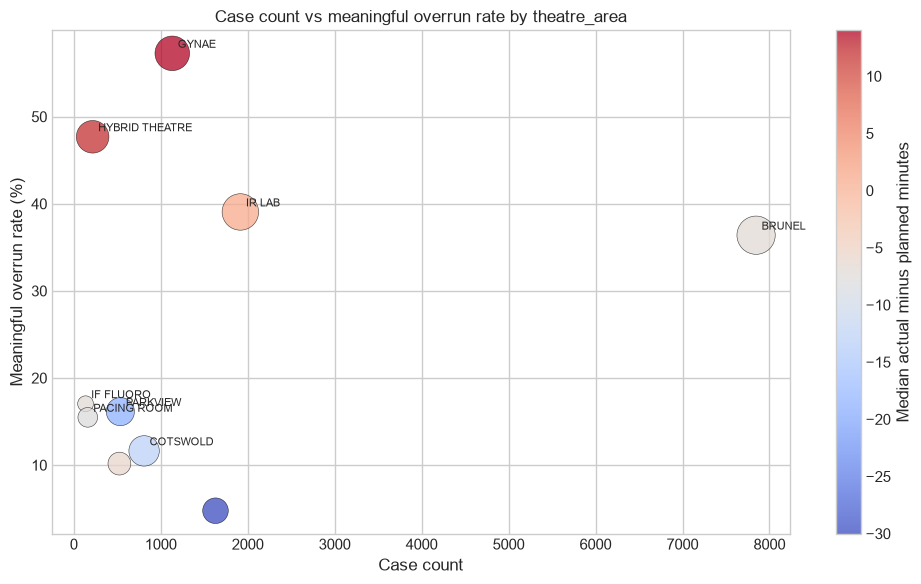

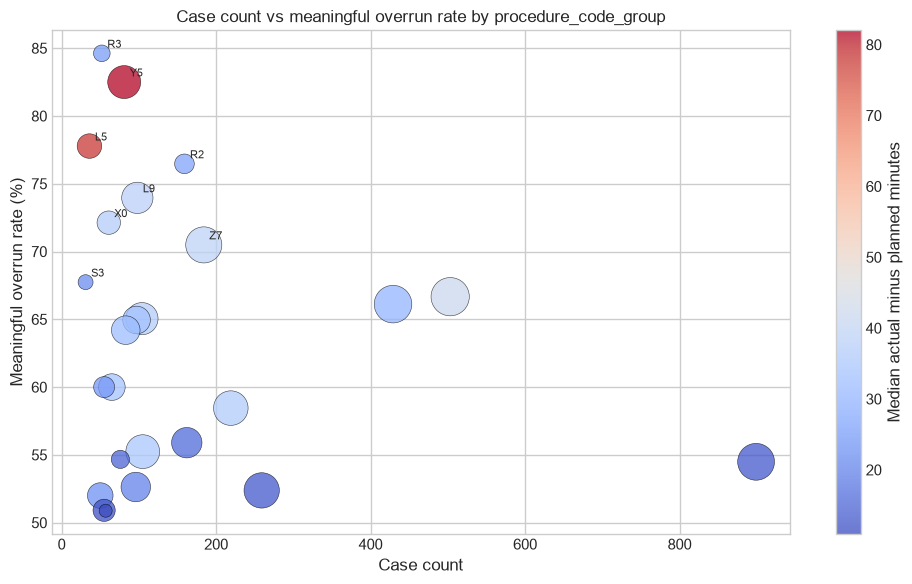

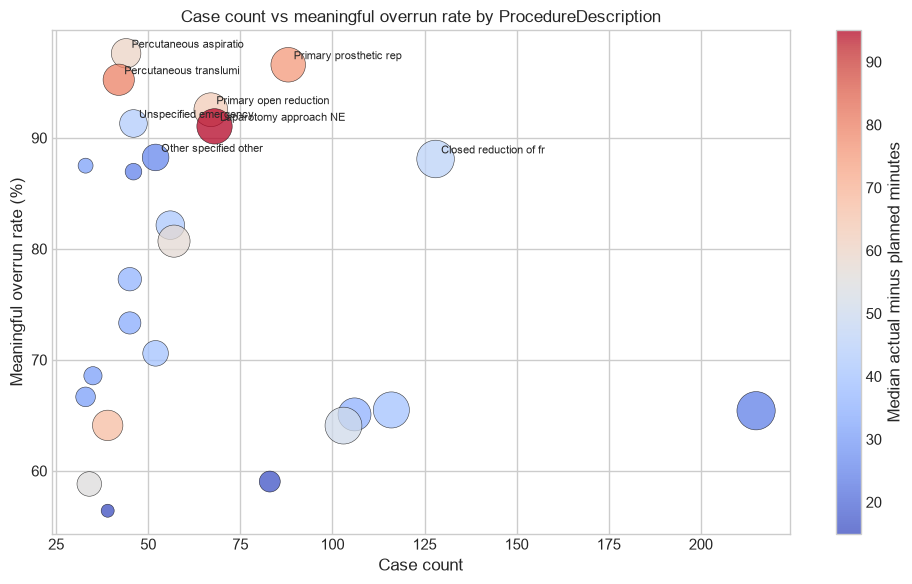

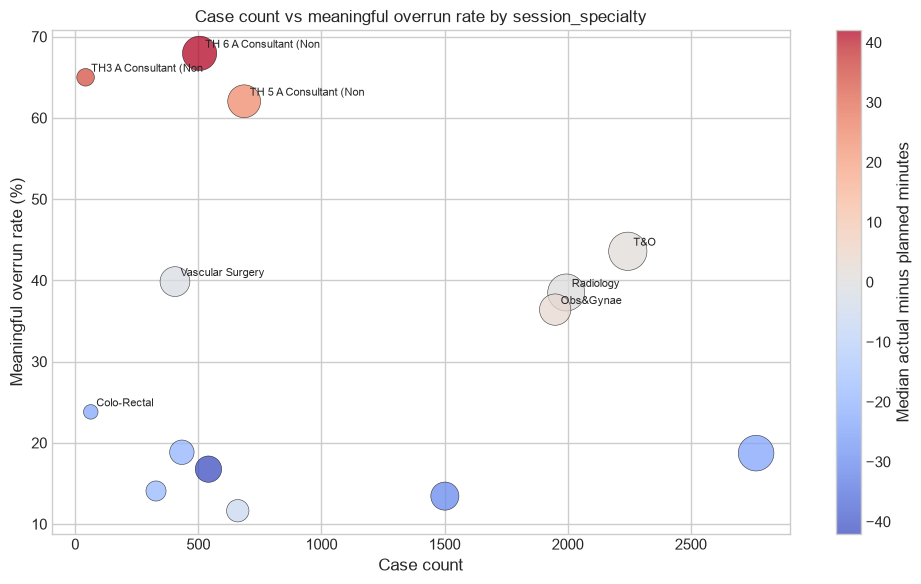

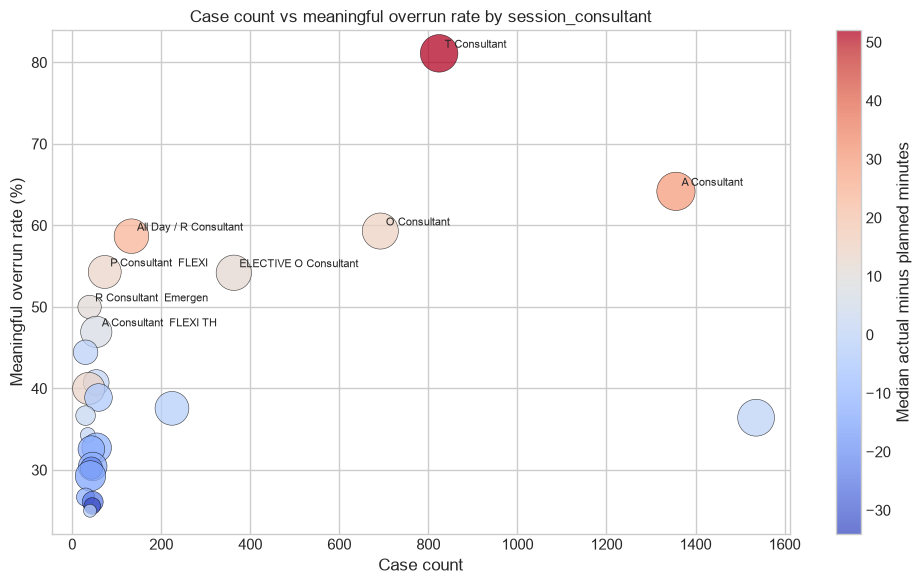

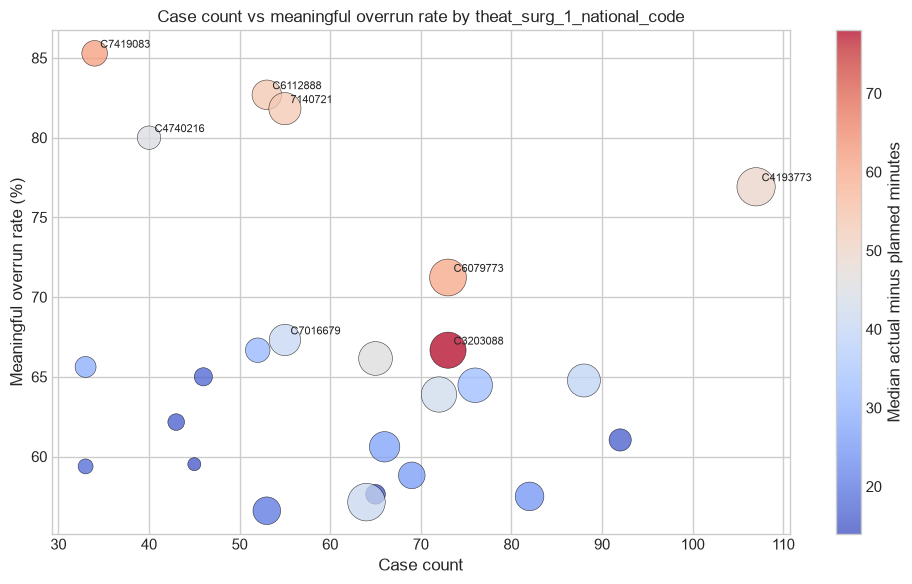

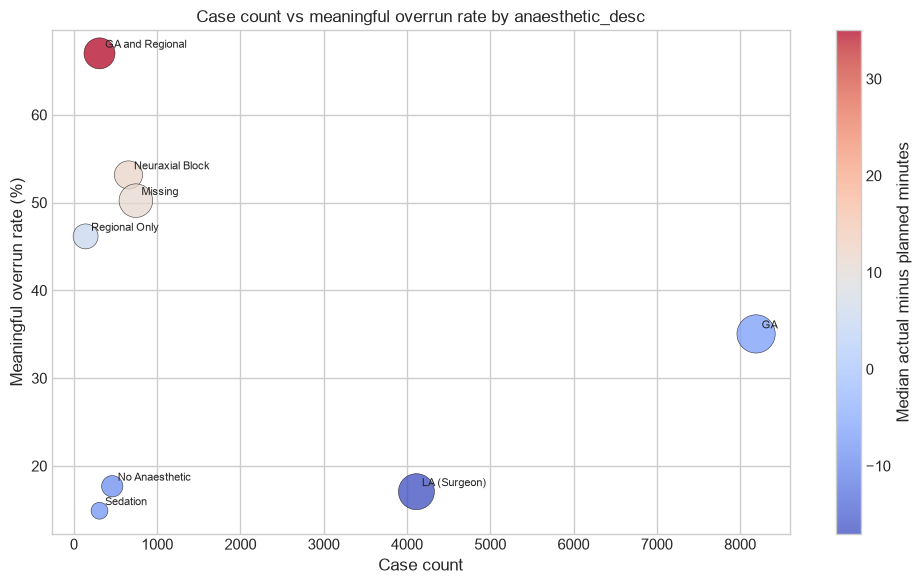

In [88]:
scatter_categories = available_columns(
    bottleneck_eda_df,
    [
        "TheatreRoom",
        "theatre_area",
        "procedure_code_group",
        "ProcedureDescription",
        "session_specialty",
        "session_consultant",
        "theat_surg_1_national_code",
        "anaesthetic_desc",
    ],
)

for column in scatter_categories:
    summary = category_bottleneck_summary(bottleneck_eda_df, column, min_cases=30, top_n=25)
    plot_category_scatter(summary, column, f"Case count vs meaningful overrun rate by {column}")


**Result interpretation:** The scatter plots compare case volume with meaningful overrun rate rather than simple overrun counts. This is a fairer view because high-volume groups naturally generate more overrun events. Large markers indicate greater total overrun burden, while colour shows whether the typical case is above or below its planned duration. The strongest operational candidates are high-volume groups with high meaningful overrun rates and positive median duration error.


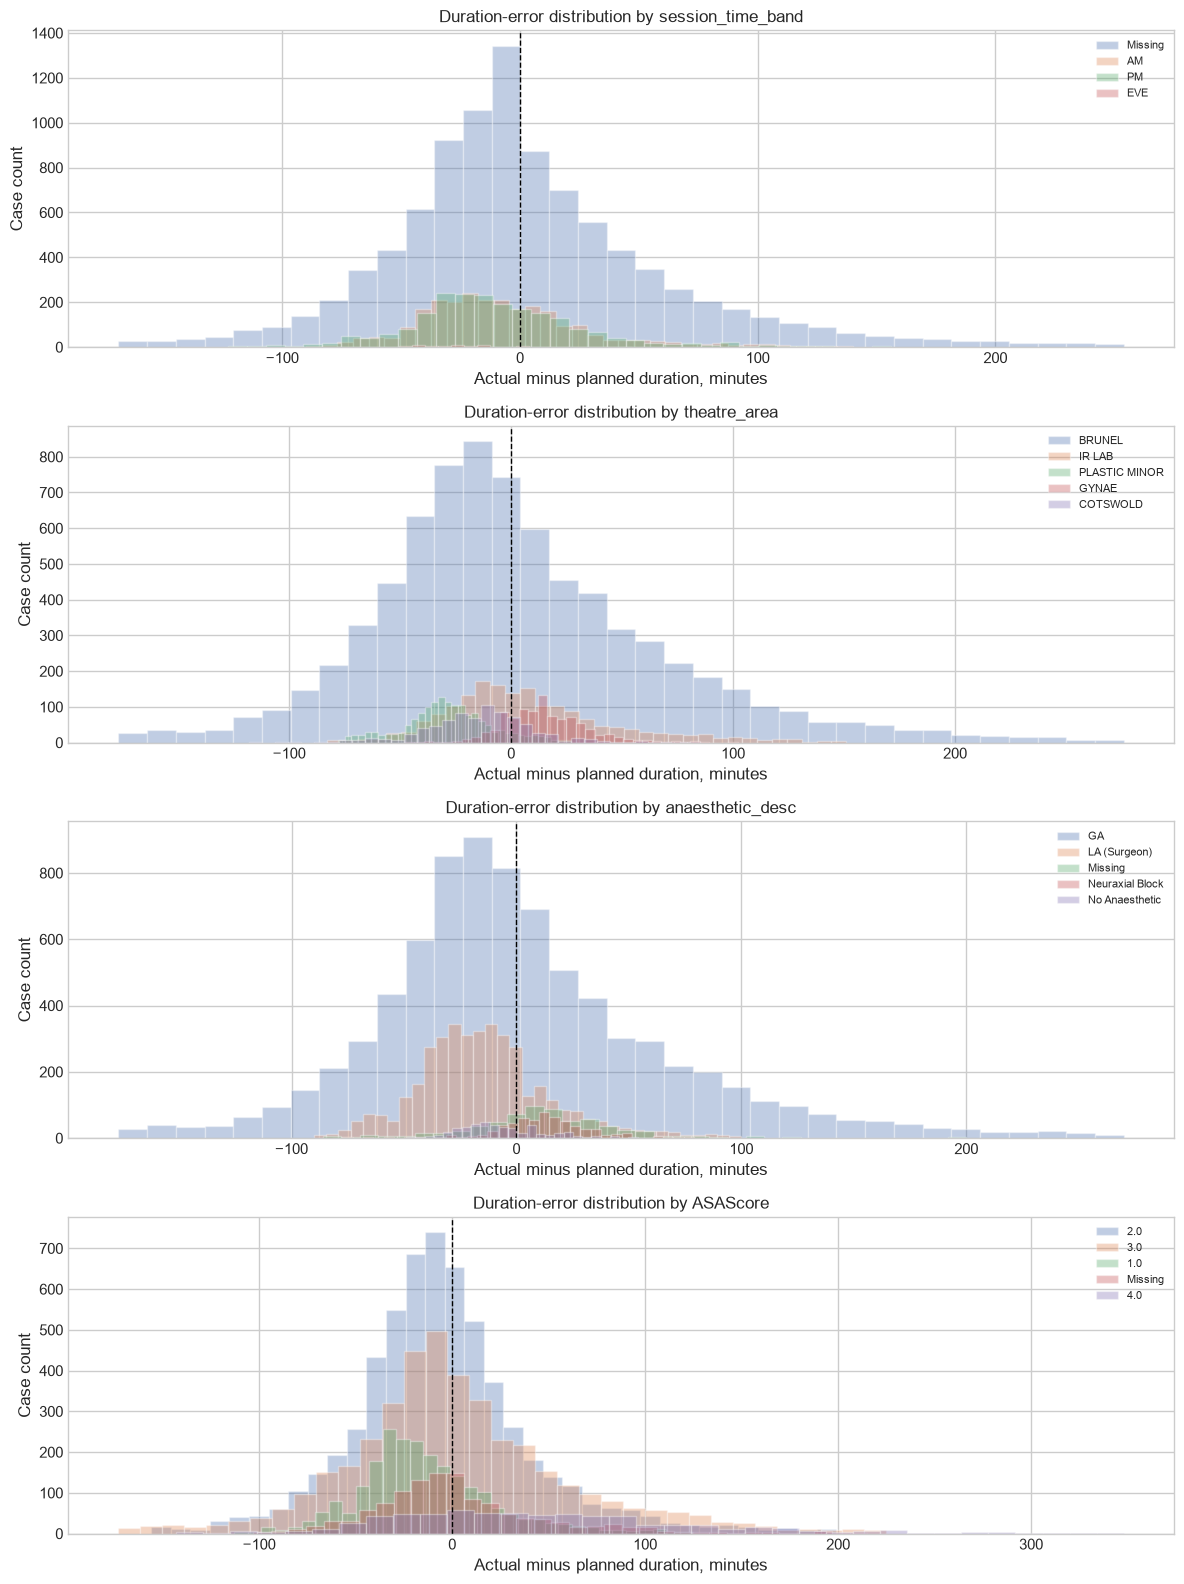

In [89]:
distribution_categories = available_columns(
    bottleneck_eda_df,
    ["session_time_band", "theatre_area", "anaesthetic_desc", "ASAScore"],
)

fig, axes = plt.subplots(len(distribution_categories), 1, figsize=(12, 4 * len(distribution_categories)))
if len(distribution_categories) == 1:
    axes = [axes]

for ax, column in zip(axes, distribution_categories):
    top_values = bottleneck_eda_df[column].astype("string").fillna("Missing").value_counts().head(5).index
    for value in top_values:
        values = bottleneck_eda_df.loc[
            bottleneck_eda_df[column].astype("string").fillna("Missing") == value,
            "duration_error_mins",
        ].dropna()
        values = values[values.between(values.quantile(0.01), values.quantile(0.99))]
        ax.hist(values, bins=35, alpha=0.35, label=str(value))

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Duration-error distribution by {column}")
    ax.set_xlabel("Actual minus planned duration, minutes")
    ax.set_ylabel("Case count")
    ax.legend(fontsize=8)

plt.tight_layout()


**Result interpretation:** Distribution plots show whether duration error is centred near zero or shifted toward overrun or underrun within key categories. Wider distributions indicate less predictable scheduling performance.


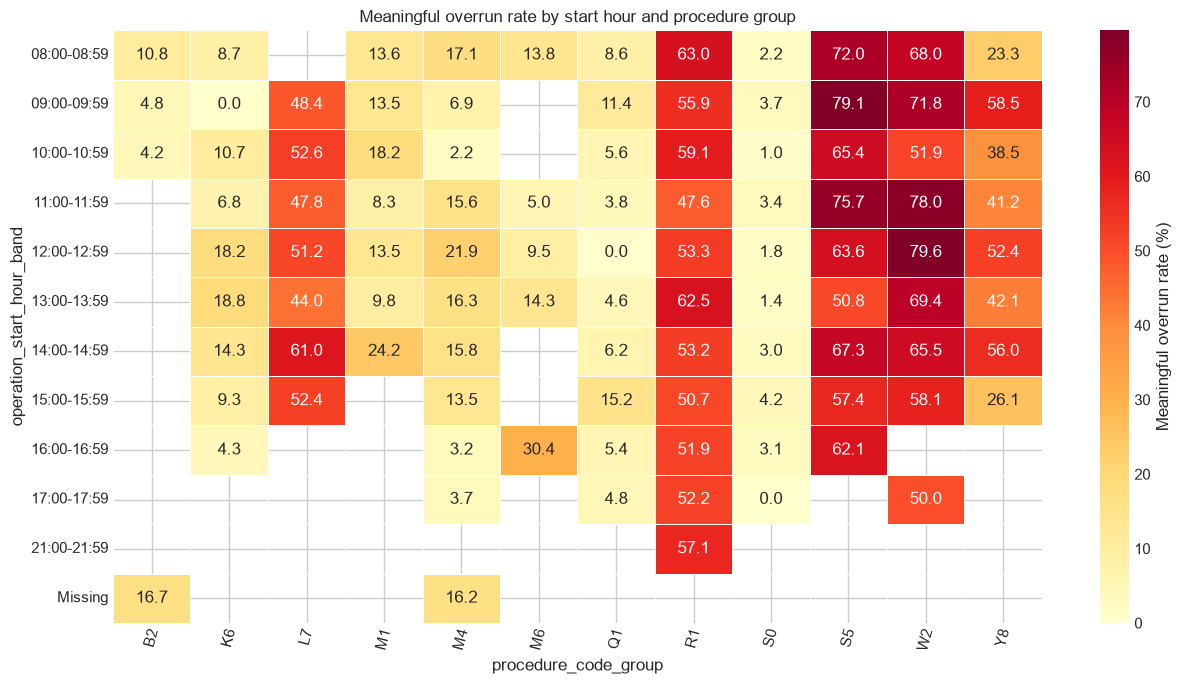

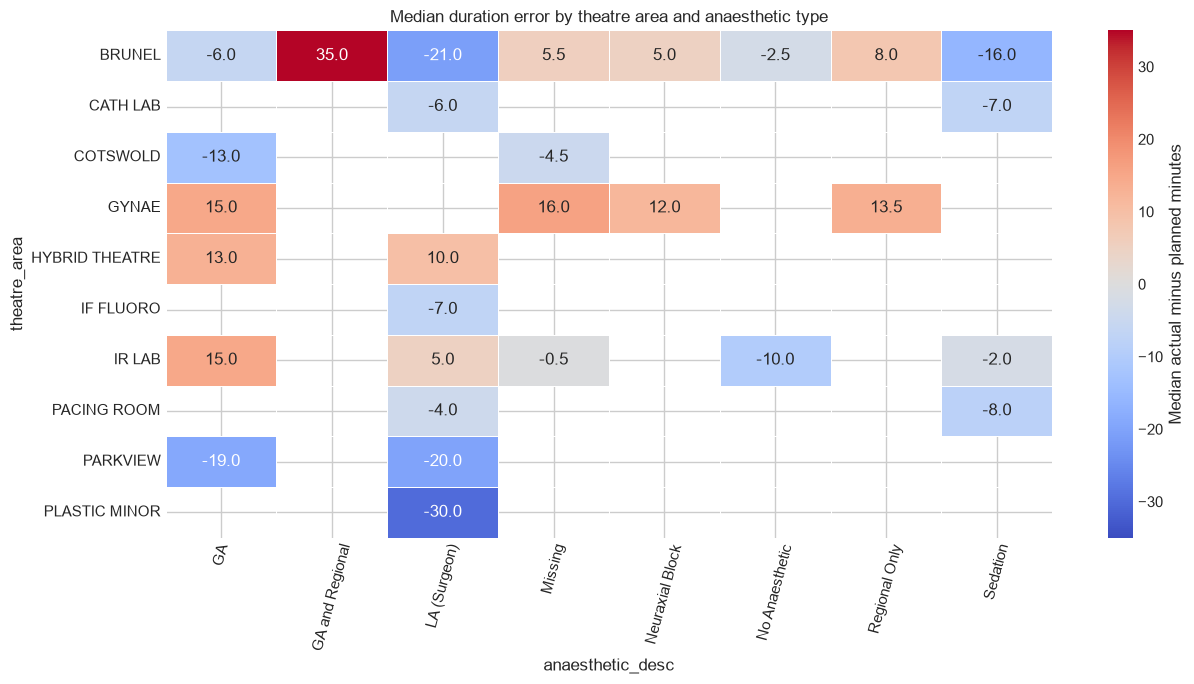

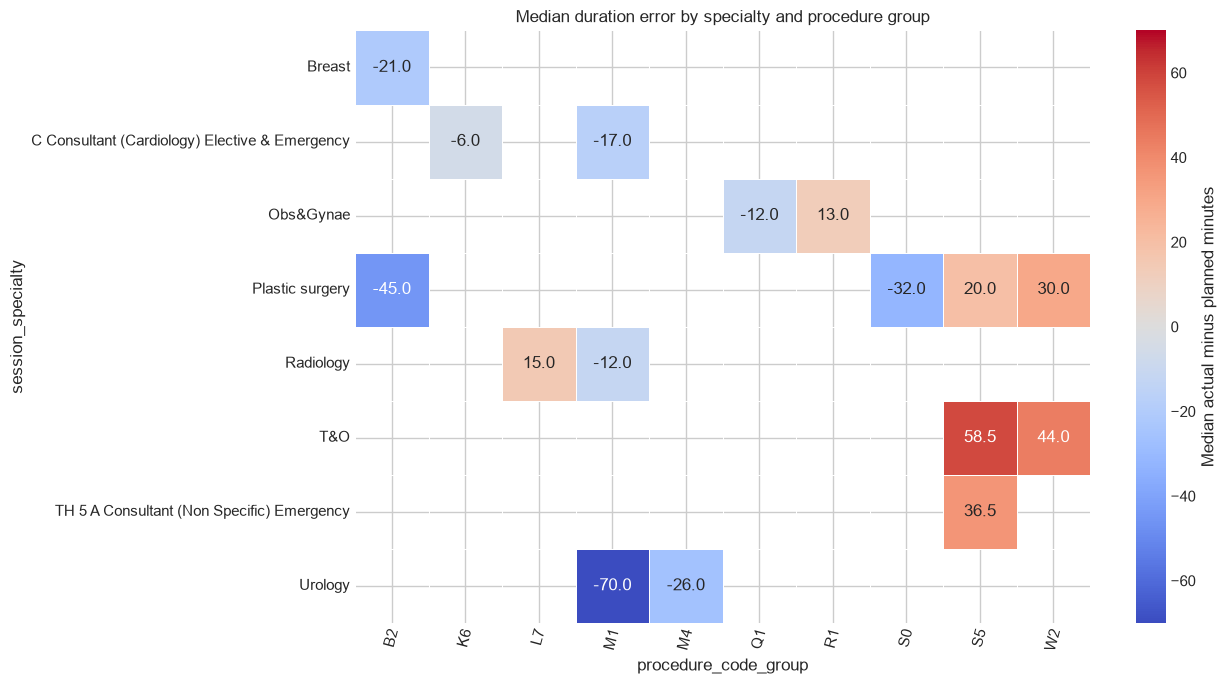

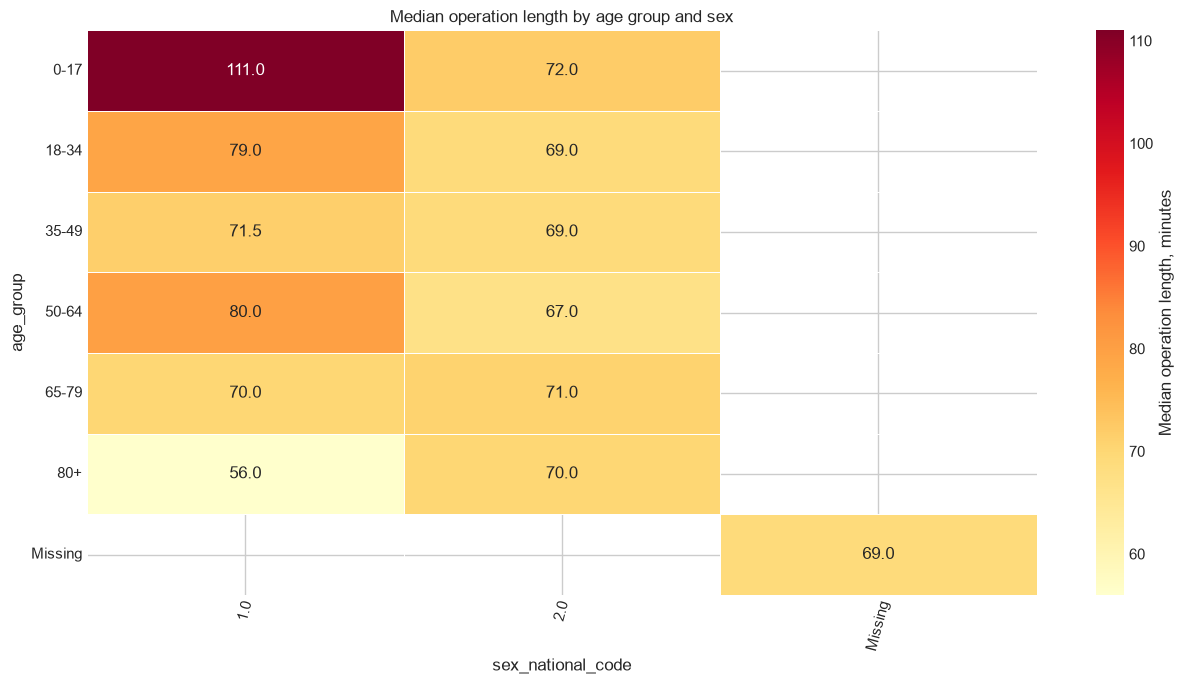

In [90]:
extra_heatmap_specs = [
    {
        "row": "operation_start_hour_band",
        "column": "procedure_code_group",
        "metric": "meaningful_overrun_flag",
        "aggfunc": "mean",
        "multiplier": 100,
        "title": "Meaningful overrun rate by start hour and procedure group",
        "colorbar": "Meaningful overrun rate (%)",
        "center_zero": False,
        "min_cases": 20,
        "top_rows": 12,
        "top_columns": 12,
    },
    {
        "row": "theatre_area",
        "column": "anaesthetic_desc",
        "metric": "duration_error_mins",
        "aggfunc": "median",
        "multiplier": 1,
        "title": "Median duration error by theatre area and anaesthetic type",
        "colorbar": "Median actual minus planned minutes",
        "center_zero": True,
        "min_cases": 20,
        "top_rows": 10,
        "top_columns": 8,
    },
    {
        "row": "session_specialty",
        "column": "procedure_code_group",
        "metric": "duration_error_mins",
        "aggfunc": "median",
        "multiplier": 1,
        "title": "Median duration error by specialty and procedure group",
        "colorbar": "Median actual minus planned minutes",
        "center_zero": True,
        "min_cases": 20,
        "top_rows": 10,
        "top_columns": 10,
    },
    {
        "row": "age_group",
        "column": "sex_national_code",
        "metric": "operation_length_mins",
        "aggfunc": "median",
        "multiplier": 1,
        "title": "Median operation length by age group and sex",
        "colorbar": "Median operation length, minutes",
        "center_zero": False,
        "min_cases": 20,
        "top_rows": 8,
        "top_columns": 5,
    },
]

for spec in extra_heatmap_specs:
    if spec["row"] not in bottleneck_eda_df.columns or spec["column"] not in bottleneck_eda_df.columns:
        continue

    table = pivot_metric_table(
        bottleneck_eda_df,
        row=spec["row"],
        column=spec["column"],
        metric=spec["metric"],
        min_cases=spec["min_cases"],
        aggfunc=spec["aggfunc"],
        top_rows=spec["top_rows"],
        top_columns=spec["top_columns"],
    ) * spec["multiplier"]

    plot_heatmap(
        table,
        title=spec["title"],
        colorbar_label=spec["colorbar"],
        center_zero=spec["center_zero"],
        figsize=(13, 7),
    )


**Result interpretation:** The heatmaps address specific interaction questions, such as whether procedure groups overrun at particular start times or whether theatre-area performance differs by anaesthetic type. These patterns should be treated as hypotheses for later modelling or operational review.


### 10.11.1 Core continuous relationship plots

These scatter plots check the main numerical relationships behind scheduling performance. The plots are trimmed to the 1st and 99th percentiles for readability, so extreme cases do not hide the main pattern. Each panel includes a simple fitted trend line and a correlation value.

The purpose is not to prove causality. It is to identify whether planned duration, age, ASA score, theatre occupancy, and post-operation theatre time have visible associations with actual duration or duration error.


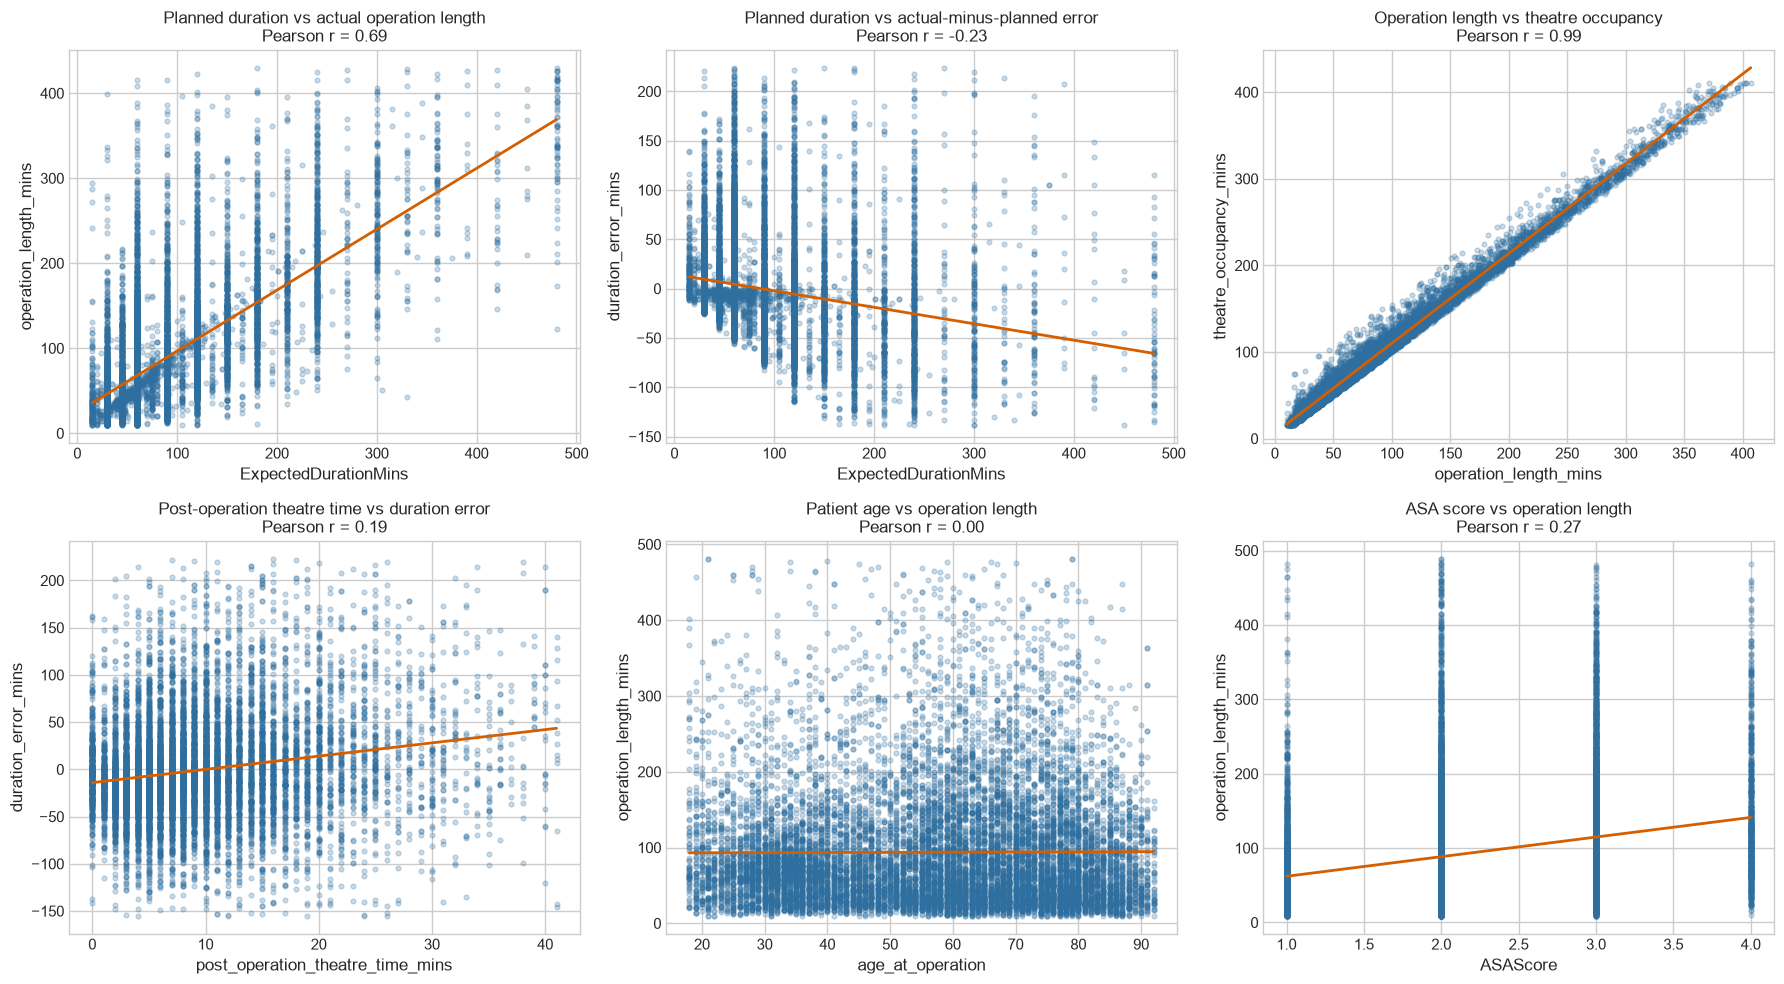

In [91]:
def plot_trimmed_scatter_grid(df, relationships, trim_quantiles=(0.01, 0.99)):
    n_cols = 3
    n_rows = -(-len(relationships) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = np.array(axes).ravel()

    for ax, spec in zip(axes, relationships):
        x_col, y_col, title = spec["x"], spec["y"], spec["title"]
        if x_col not in df.columns or y_col not in df.columns:
            ax.axis("off")
            continue

        plot_df = df[[x_col, y_col]].copy()
        plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
        plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
        plot_df = plot_df.dropna()

        if plot_df.empty:
            ax.axis("off")
            continue

        for column in [x_col, y_col]:
            lower, upper = plot_df[column].quantile(trim_quantiles)
            plot_df = plot_df[plot_df[column].between(lower, upper)]

        ax.scatter(plot_df[x_col], plot_df[y_col], s=12, alpha=0.25, color=plot_color)

        if len(plot_df) >= 3 and plot_df[x_col].nunique() > 1:
            slope, intercept = np.polyfit(plot_df[x_col], plot_df[y_col], 1)
            x_values = np.linspace(plot_df[x_col].min(), plot_df[x_col].max(), 100)
            ax.plot(x_values, slope * x_values + intercept, color=highlight_color, linewidth=2)

        corr_value = plot_df[x_col].corr(plot_df[y_col])
        ax.set_title(f"{title}\nPearson r = {corr_value:.2f}")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

    for ax in axes[len(relationships):]:
        ax.axis("off")

    plt.tight_layout()


continuous_relationships = [
    {
        "x": "ExpectedDurationMins",
        "y": "operation_length_mins",
        "title": "Planned duration vs actual operation length",
    },
    {
        "x": "ExpectedDurationMins",
        "y": "duration_error_mins",
        "title": "Planned duration vs actual-minus-planned error",
    },
    {
        "x": "operation_length_mins",
        "y": "theatre_occupancy_mins",
        "title": "Operation length vs theatre occupancy",
    },
    {
        "x": "post_operation_theatre_time_mins",
        "y": "duration_error_mins",
        "title": "Post-operation theatre time vs duration error",
    },
    {
        "x": "age_at_operation",
        "y": "operation_length_mins",
        "title": "Patient age vs operation length",
    },
    {
        "x": "ASAScore",
        "y": "operation_length_mins",
        "title": "ASA score vs operation length",
    },
]

plot_trimmed_scatter_grid(bottleneck_eda_df, continuous_relationships)


**Result interpretation:** These scatter plots provide a direct visual check of numerical drivers. A strong planned-versus-actual relationship would support using expected duration as a baseline scheduling feature. A weaker relationship between patient factors and operation length would suggest that age or ASA alone is not enough to explain duration without procedure, specialty, theatre, and anaesthetic context. Positive association between theatre occupancy and operation length is expected, while any extra spread may reflect preparation, recovery transfer, or post-operation theatre-flow delays.


### 10.11.2 Category distributions for duration error and operation length

Grouped averages can hide spread. These boxplots compare the distribution of operation length or duration error across key categories. They help show whether a group is consistently different or whether a few extreme cases are driving the summary.


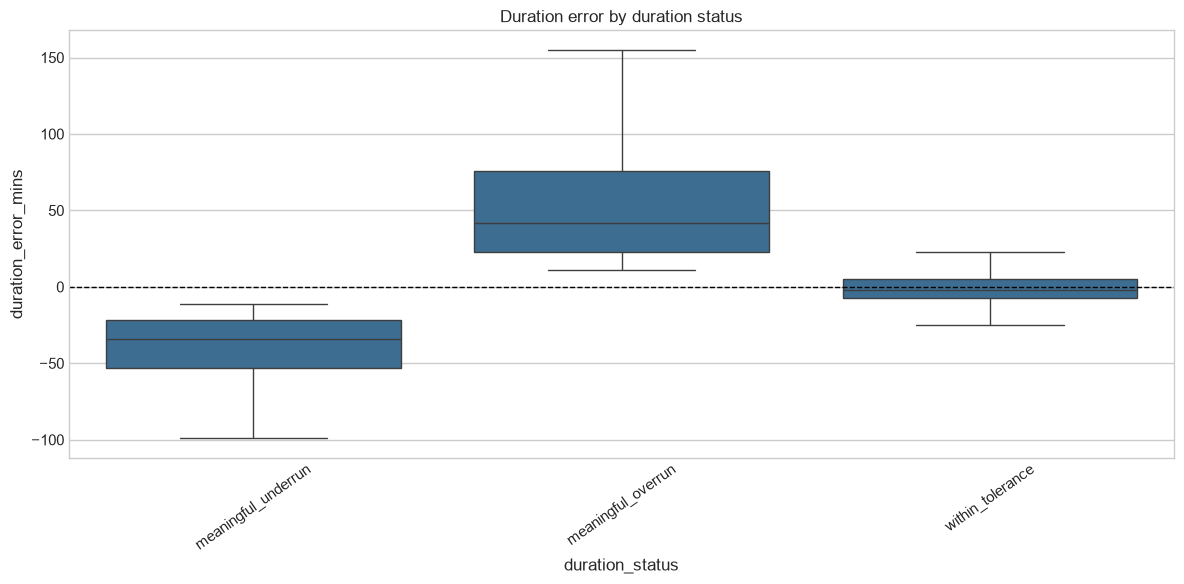

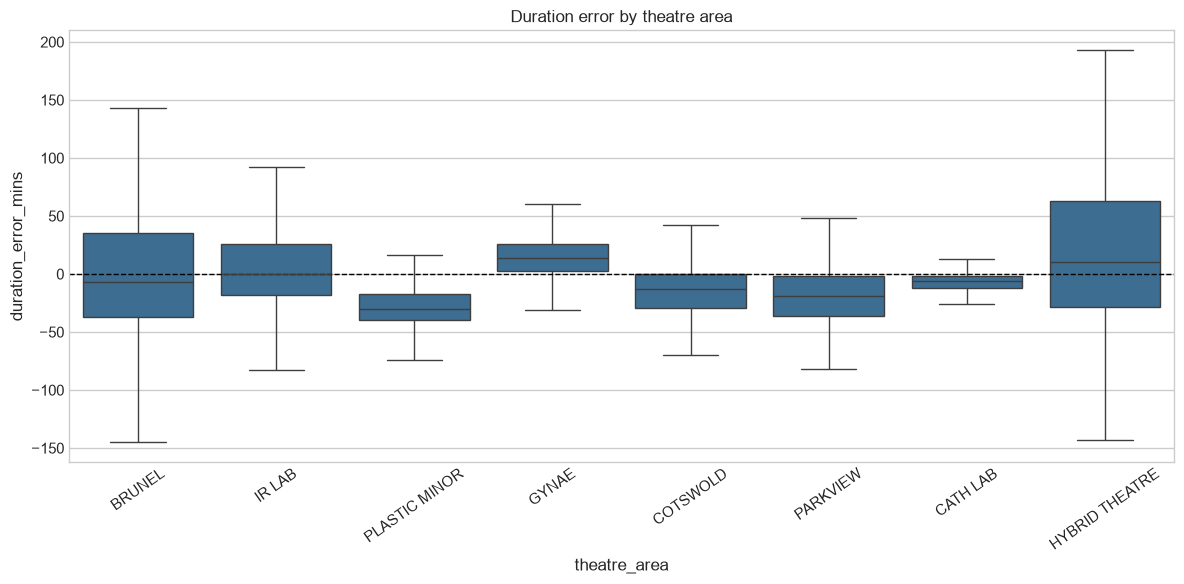

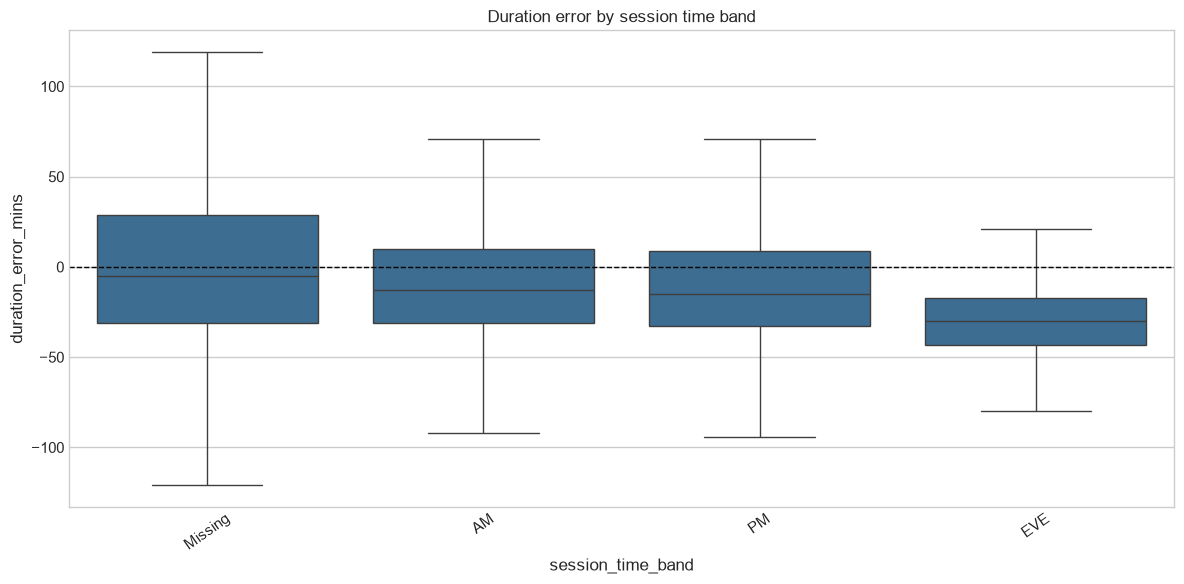

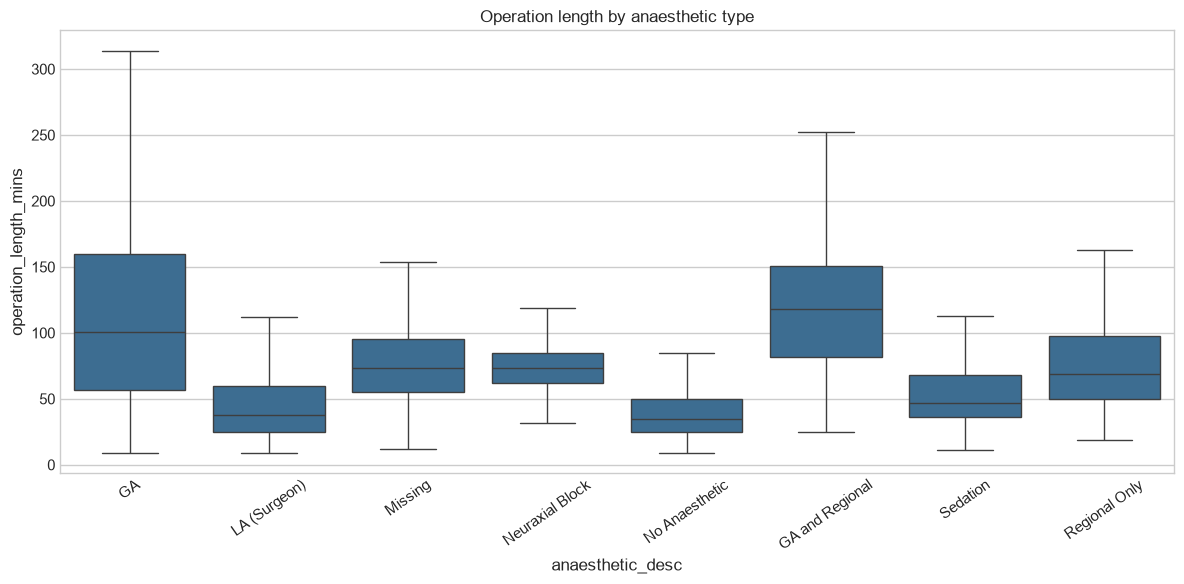

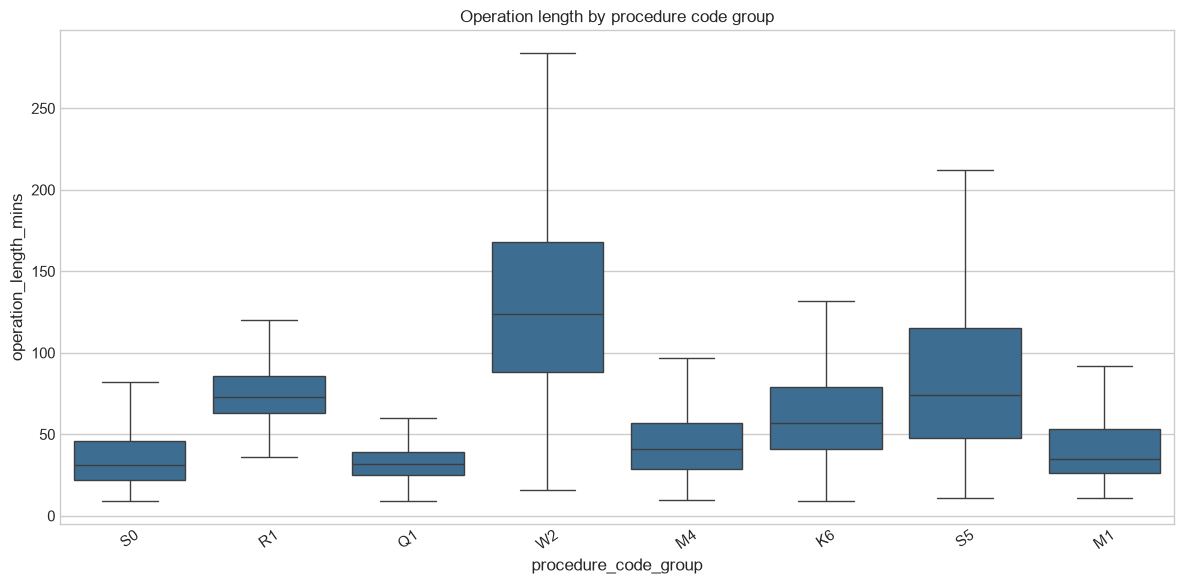

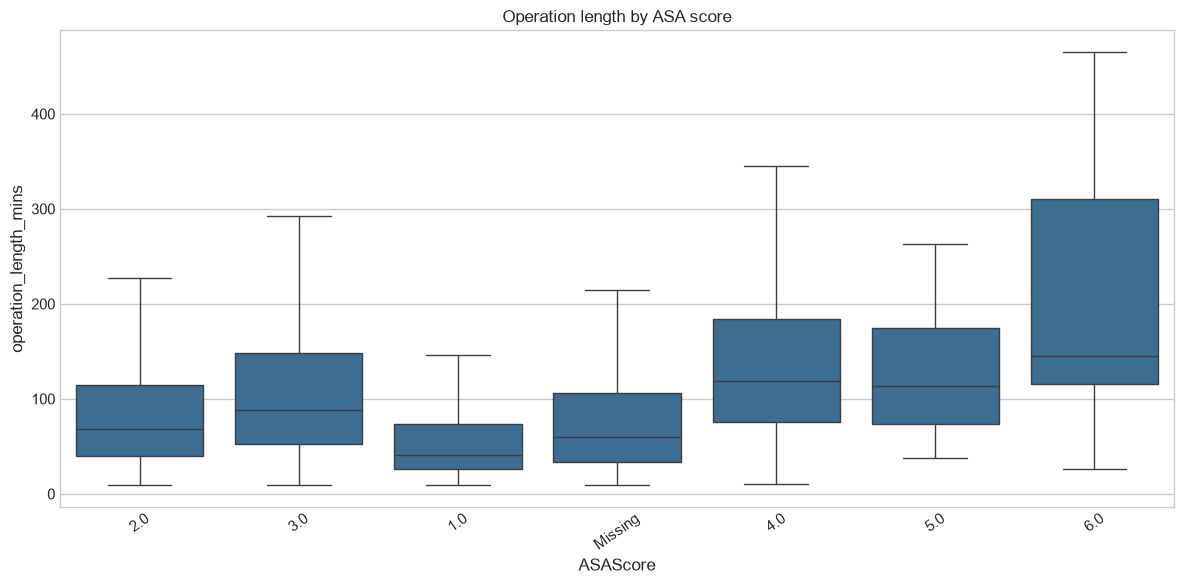

In [92]:
def plot_box_by_category(df, category, value, title, top_n=8, trim_quantiles=(0.01, 0.99)):
    if category not in df.columns or value not in df.columns:
        print(f"Skipping {title}: missing {category} or {value}")
        return

    temp = df[[category, value]].copy()
    temp[category] = temp[category].astype("string").fillna("Missing")
    temp[value] = pd.to_numeric(temp[value], errors="coerce")
    temp = temp.dropna(subset=[value])

    if temp.empty:
        print(f"Skipping {title}: no valid values")
        return

    lower, upper = temp[value].quantile(trim_quantiles)
    temp = temp[temp[value].between(lower, upper)]
    top_values = temp[category].value_counts().head(top_n).index
    temp = temp[temp[category].isin(top_values)]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=temp, x=category, y=value, order=top_values, ax=ax, color=plot_color, showfliers=False)
    ax.axhline(0, color="black", linestyle="--", linewidth=1) if "error" in value else None
    ax.set_title(title)
    ax.set_xlabel(category)
    ax.set_ylabel(value)
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()


boxplot_specs = [
    ("duration_status", "duration_error_mins", "Duration error by duration status"),
    ("theatre_area", "duration_error_mins", "Duration error by theatre area"),
    ("session_time_band", "duration_error_mins", "Duration error by session time band"),
    ("anaesthetic_desc", "operation_length_mins", "Operation length by anaesthetic type"),
    ("procedure_code_group", "operation_length_mins", "Operation length by procedure code group"),
    ("ASAScore", "operation_length_mins", "Operation length by ASA score"),
]

for category, value, title in boxplot_specs:
    plot_box_by_category(bottleneck_eda_df, category, value, title)


**Result interpretation:** Boxplots show both central tendency and variability. Categories with higher medians and wider boxes are less predictable and may require more conservative scheduling assumptions. For `duration_error_mins`, values above zero indicate that actual operation length exceeded the planned duration, while values below zero indicate unused planned time. The most important operational groups are those with both high volume and consistently positive duration error.


### 10.11.3 Duration-status mix by key operational factors

This view compares the proportion of meaningful overrun, within-tolerance, meaningful underrun, and missing-duration cases across important categories. It is useful because it shows whether a category is mostly over-running, mostly under-running, or simply variable.


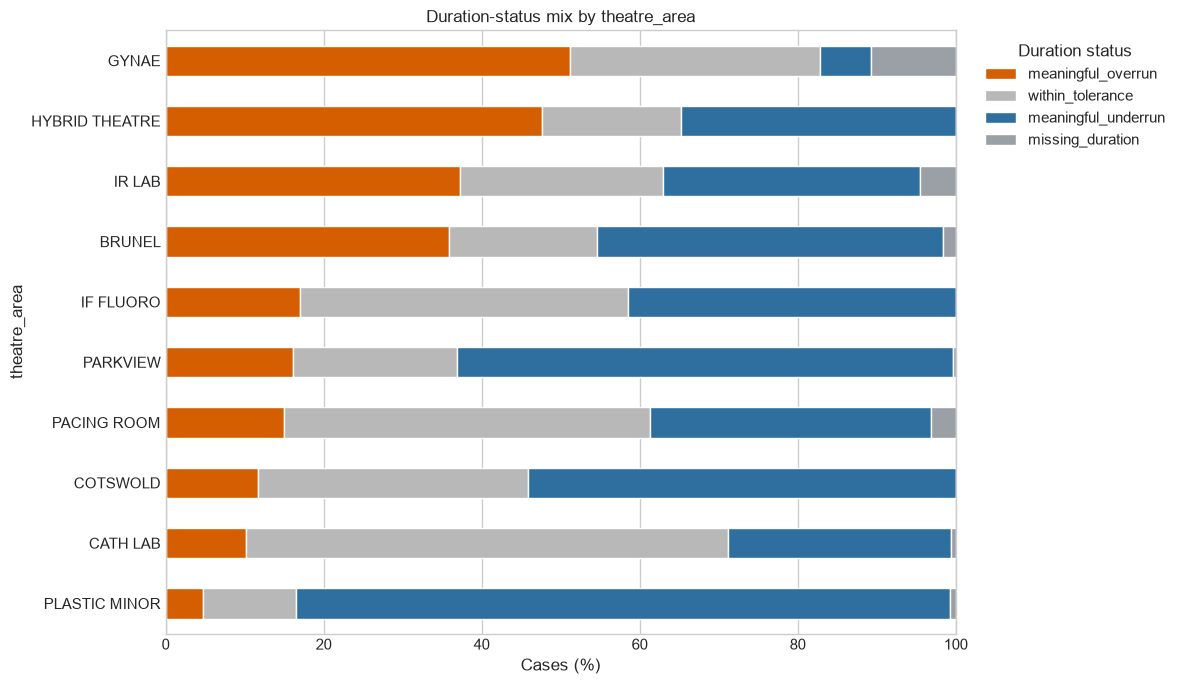

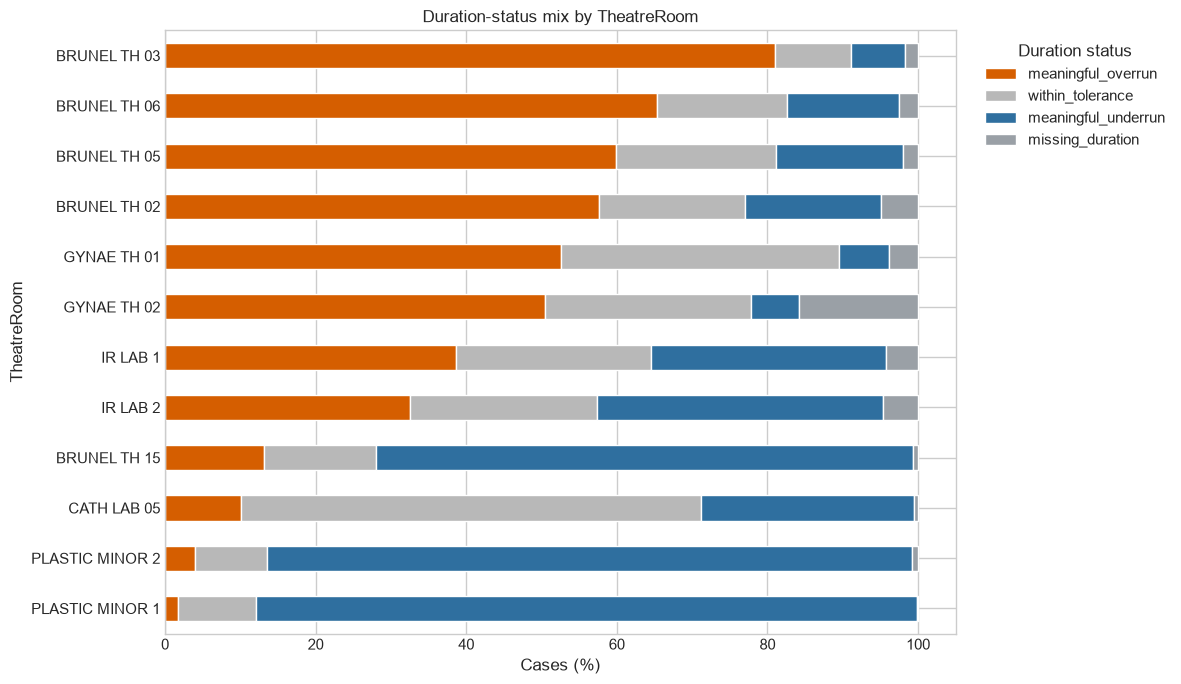

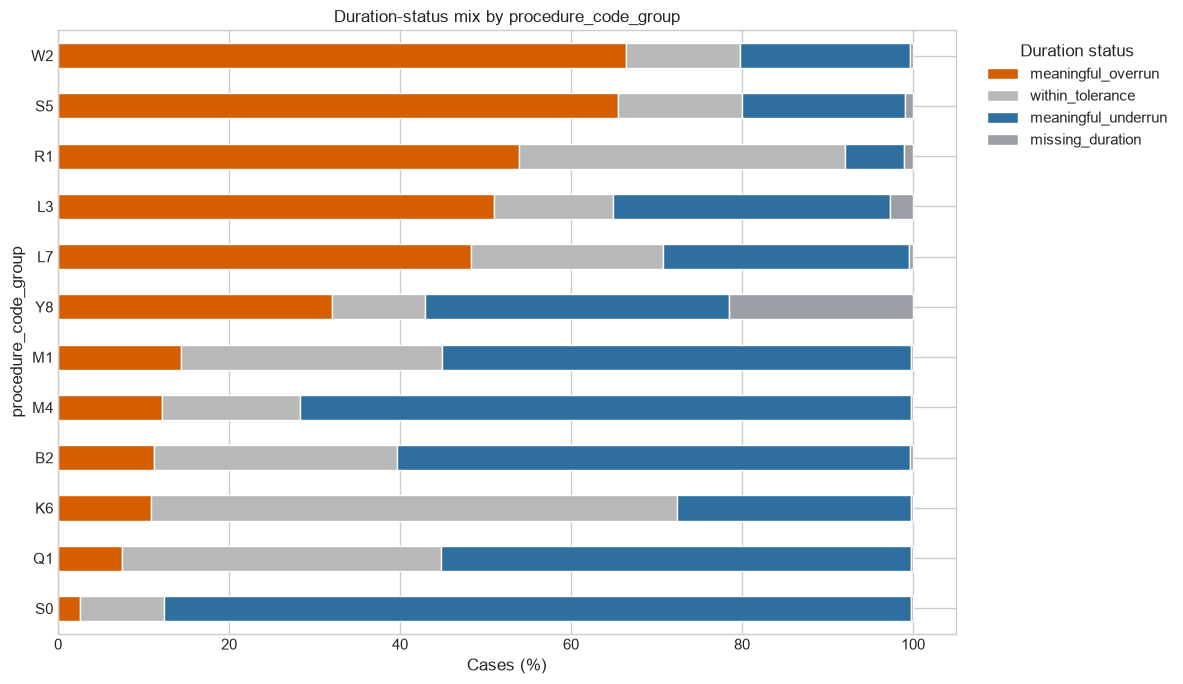

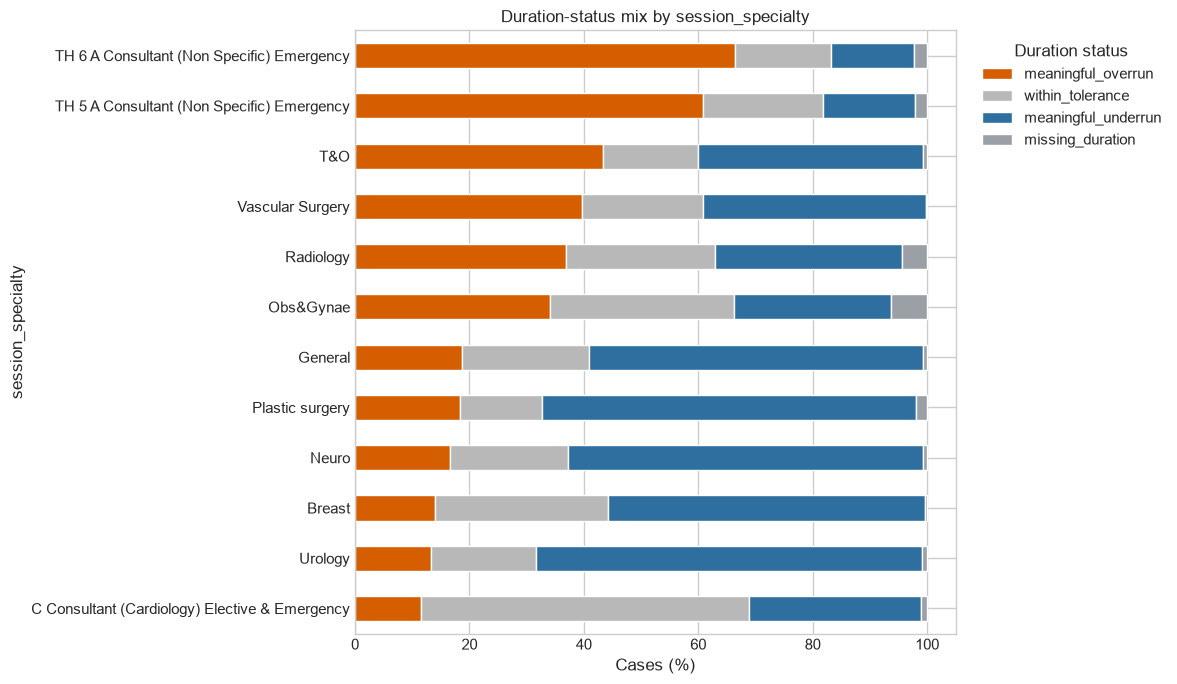

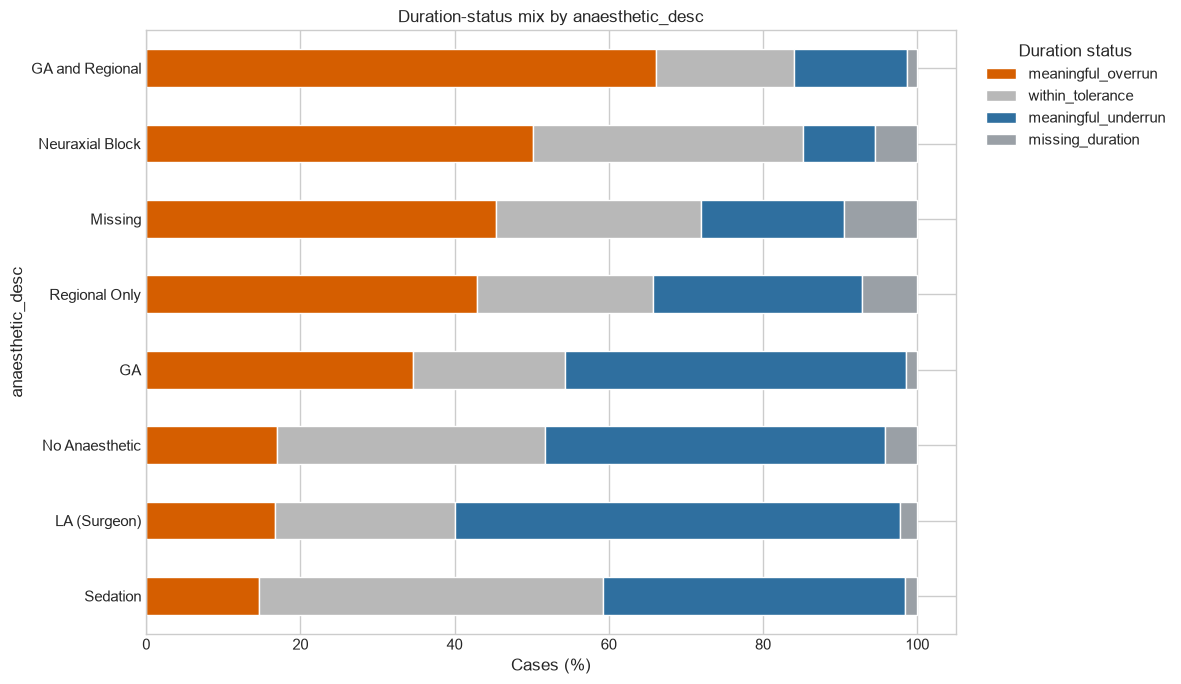

In [93]:
def duration_status_mix_table(df, category, min_cases=30, top_n=12):
    if category not in df.columns or "duration_status" not in df.columns:
        return pd.DataFrame()

    temp = df[[category, "duration_status"]].copy()
    temp[category] = temp[category].astype("string").fillna("Missing")
    temp["duration_status"] = temp["duration_status"].astype("string").fillna("missing_duration")

    valid_categories = temp[category].value_counts()
    valid_categories = valid_categories[valid_categories >= min_cases].head(top_n).index
    temp = temp[temp[category].isin(valid_categories)]

    mix = pd.crosstab(temp[category], temp["duration_status"], normalize="index") * 100
    mix = mix.reindex(columns=duration_status_order, fill_value=0)
    return mix


def plot_duration_status_mix(df, category, title):
    mix = duration_status_mix_table(df, category)
    if mix.empty:
        print(f"Skipping {title}: no valid categories")
        return

    fig, ax = plt.subplots(figsize=(12, 7))
    mix.sort_values("meaningful_overrun", ascending=True).plot(
        kind="barh",
        stacked=True,
        ax=ax,
        color=[highlight_color, "#B8B8B8", plot_color, "#9AA0A6"],
    )
    ax.set_title(title)
    ax.set_xlabel("Cases (%)")
    ax.set_ylabel(category)
    ax.legend(title="Duration status", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()


status_mix_categories = available_columns(
    bottleneck_eda_df,
    ["theatre_area", "TheatreRoom", "procedure_code_group", "session_specialty", "anaesthetic_desc"],
)

for category in status_mix_categories:
    plot_duration_status_mix(bottleneck_eda_df, category, f"Duration-status mix by {category}")


**Result interpretation:** Duration-status mix plots make overrun comparison more balanced than raw counts. A category with many meaningful overruns and few within-tolerance cases is less reliable for scheduling. A category dominated by meaningful underruns may indicate over-booked planned durations or spare capacity. Categories with high missing-duration proportions should be reviewed for data quality before operational conclusions are made.


### 10.11.4 Three-variable overrun and underrun relationship plots

The previous charts compare one or two variables at a time. This section adds three-variable views where position, colour, and marker size are used together. This is more useful for bottleneck analysis because an operational problem is rarely explained by one field alone.

The main question here is: which combinations of planned duration, actual duration, theatre occupancy, start hour, room, procedure group, and duration status are associated with meaningful overruns or underruns?


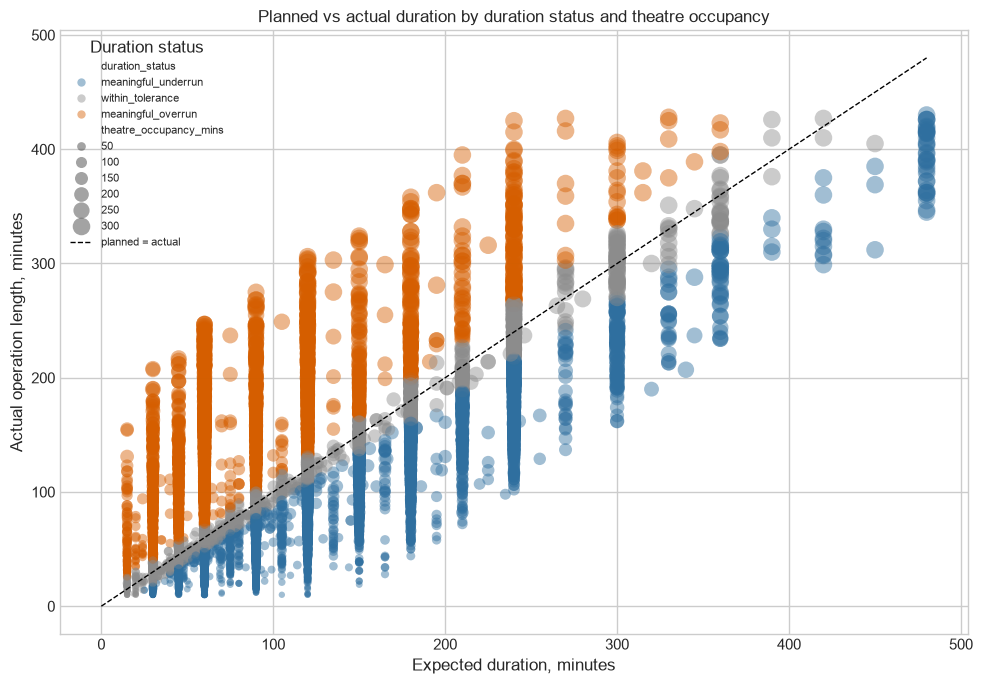

In [94]:
triage_plot_df = bottleneck_eda_df.copy()
triage_plot_df["duration_status"] = triage_plot_df["duration_status"].astype("string").fillna("missing_duration")
triage_plot_df["duration_status_color"] = triage_plot_df["duration_status"].map(status_colors).fillna("#BDBDBD")

triage_plot_df = triage_plot_df.dropna(
    subset=["ExpectedDurationMins", "operation_length_mins", "duration_error_mins"]
).copy()

for column in ["ExpectedDurationMins", "operation_length_mins", "duration_error_mins"]:
    lower, upper = triage_plot_df[column].quantile([0.01, 0.99])
    triage_plot_df = triage_plot_df[triage_plot_df[column].between(lower, upper)]

fig, ax = plt.subplots(figsize=(10, 7))
marker_size = triage_plot_df["theatre_occupancy_mins"].fillna(
    triage_plot_df["operation_length_mins"]
).clip(lower=10, upper=300)

sns.scatterplot(
    data=triage_plot_df,
    x="ExpectedDurationMins",
    y="operation_length_mins",
    hue="duration_status",
    size=marker_size,
    palette=status_colors,
    sizes=(20, 160),
    alpha=0.45,
    edgecolor="none",
    ax=ax,
)

limit = max(triage_plot_df["ExpectedDurationMins"].max(), triage_plot_df["operation_length_mins"].max())
ax.plot([0, limit], [0, limit], color="black", linestyle="--", linewidth=1, label="planned = actual")
ax.set_title("Planned vs actual duration by duration status and theatre occupancy")
ax.set_xlabel("Expected duration, minutes")
ax.set_ylabel("Actual operation length, minutes")
ax.legend(title="Duration status", fontsize=8)
plt.tight_layout()


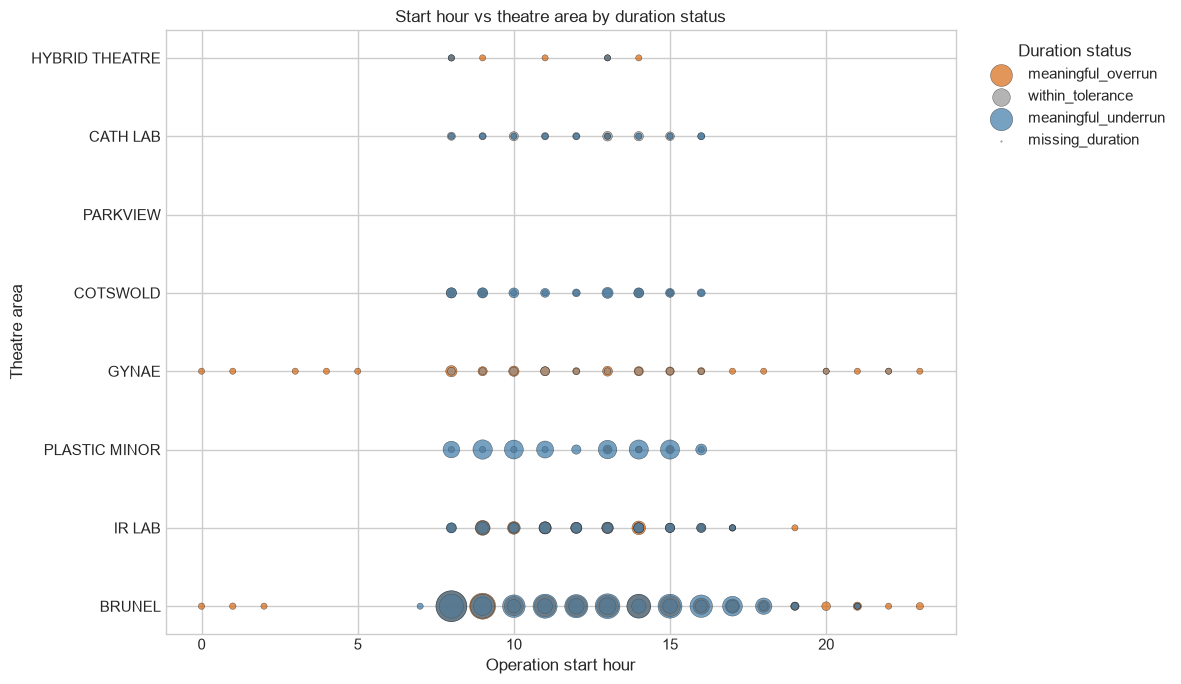

In [95]:
if "operation_start_hour" in bottleneck_eda_df.columns and "theatre_area" in bottleneck_eda_df.columns:
    hour_area_status_summary = (
        bottleneck_eda_df
        .dropna(subset=["operation_start_hour", "duration_error_mins", "theatre_area"])
        .assign(
            theatre_area=lambda df: df["theatre_area"].astype("string").fillna("Missing"),
            duration_status=lambda df: df["duration_status"].astype("string").fillna("missing_duration"),
        )
        .groupby(["operation_start_hour", "theatre_area", "duration_status"], dropna=False)
        .agg(
            cases=(target_column, "size"),
            median_duration_error=("duration_error_mins", "median"),
            median_occupancy=("theatre_occupancy_mins", "median"),
        )
        .reset_index()
    )
    hour_area_status_summary = hour_area_status_summary[hour_area_status_summary["cases"] >= 10]

    top_plot_areas = bottleneck_eda_df["theatre_area"].astype("string").fillna("Missing").value_counts().head(8).index
    hour_area_status_summary = hour_area_status_summary[hour_area_status_summary["theatre_area"].isin(top_plot_areas)]
    hour_area_status_summary["area_index"] = hour_area_status_summary["theatre_area"].map(
        {area: idx for idx, area in enumerate(top_plot_areas)}
    )

    fig, ax = plt.subplots(figsize=(12, 7))
    for status, colour in status_colors.items():
        subset = hour_area_status_summary[hour_area_status_summary["duration_status"] == status]
        ax.scatter(
            subset["operation_start_hour"],
            subset["area_index"],
            s=subset["cases"].clip(lower=20, upper=500),
            c=colour,
            alpha=0.65,
            label=status,
            edgecolor="black",
            linewidth=0.3,
        )

    ax.set_title("Start hour vs theatre area by duration status")
    ax.set_xlabel("Operation start hour")
    ax.set_ylabel("Theatre area")
    ax.set_yticks(range(len(top_plot_areas)))
    ax.set_yticklabels(top_plot_areas)
    ax.legend(title="Duration status", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()


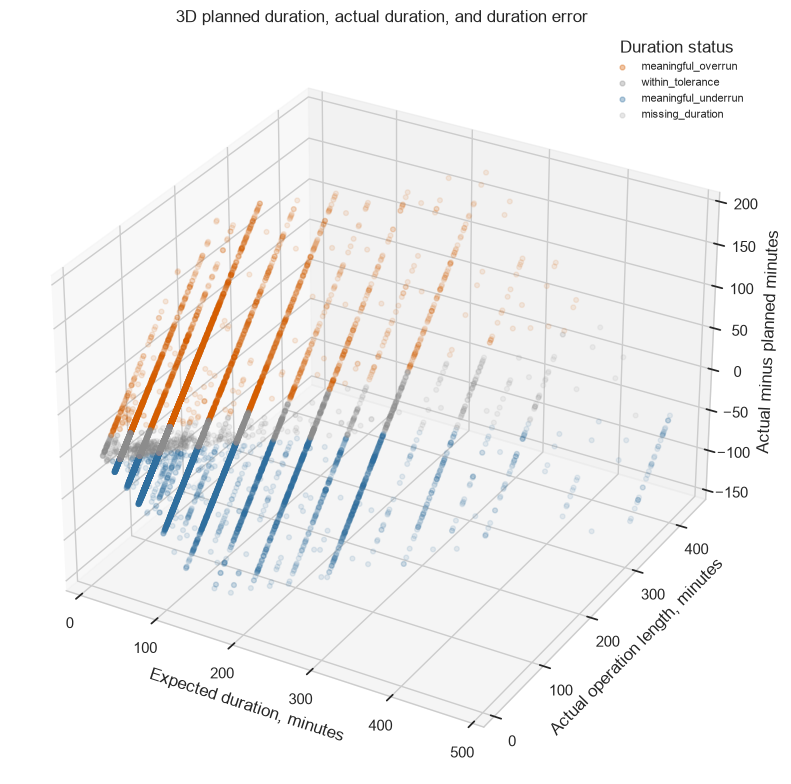

In [96]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

three_variable_df = bottleneck_eda_df.dropna(
    subset=["ExpectedDurationMins", "operation_length_mins", "duration_error_mins"]
).copy()
three_variable_df["duration_status"] = three_variable_df["duration_status"].astype("string").fillna("missing_duration")
three_variable_df = three_variable_df[three_variable_df["duration_status"].isin(status_colors)]

for column in ["ExpectedDurationMins", "operation_length_mins", "duration_error_mins"]:
    lower, upper = three_variable_df[column].quantile([0.01, 0.99])
    three_variable_df = three_variable_df[three_variable_df[column].between(lower, upper)]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

for status, colour in status_colors.items():
    subset = three_variable_df[three_variable_df["duration_status"] == status]
    ax.scatter(
        subset["ExpectedDurationMins"],
        subset["operation_length_mins"],
        subset["duration_error_mins"],
        s=12,
        alpha=0.35,
        c=colour,
        label=status,
    )

ax.set_title("3D planned duration, actual duration, and duration error")
ax.set_xlabel("Expected duration, minutes")
ax.set_ylabel("Actual operation length, minutes")
ax.set_zlabel("Actual minus planned minutes")
ax.legend(title="Duration status", fontsize=8)
plt.tight_layout()


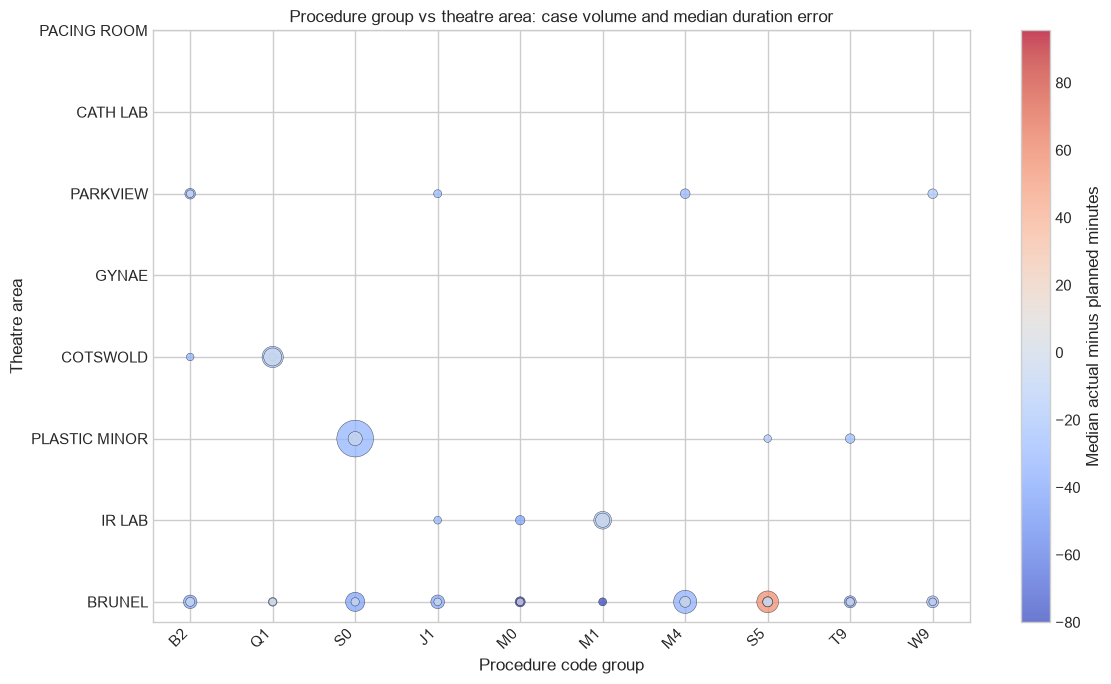

In [97]:
if "procedure_code_group" in bottleneck_eda_df.columns and "theatre_area" in bottleneck_eda_df.columns:
    procedure_area_status = (
        bottleneck_eda_df
        .assign(
            procedure_code_group=lambda df: df["procedure_code_group"].astype("string").fillna("Missing"),
            theatre_area=lambda df: df["theatre_area"].astype("string").fillna("Missing"),
            duration_status=lambda df: df["duration_status"].astype("string").fillna("missing_duration"),
        )
        .groupby(["procedure_code_group", "theatre_area", "duration_status"], dropna=False)
        .agg(
            cases=(target_column, "size"),
            median_duration_error=("duration_error_mins", "median"),
            median_operation_length=(target_column, "median"),
        )
        .reset_index()
    )
    procedure_area_status = procedure_area_status[procedure_area_status["cases"] >= 20]

    top_groups = procedure_area_status["procedure_code_group"].value_counts().head(10).index
    top_areas = procedure_area_status["theatre_area"].value_counts().head(8).index
    procedure_area_status = procedure_area_status[
        procedure_area_status["procedure_code_group"].isin(top_groups)
        & procedure_area_status["theatre_area"].isin(top_areas)
    ]
    procedure_area_status["group_index"] = procedure_area_status["procedure_code_group"].map(
        {value: idx for idx, value in enumerate(top_groups)}
    )
    procedure_area_status["area_index"] = procedure_area_status["theatre_area"].map(
        {value: idx for idx, value in enumerate(top_areas)}
    )

    fig, ax = plt.subplots(figsize=(12, 7))
    scatter = ax.scatter(
        procedure_area_status["group_index"],
        procedure_area_status["area_index"],
        s=procedure_area_status["cases"].clip(lower=30, upper=700),
        c=procedure_area_status["median_duration_error"],
        cmap="coolwarm",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.3,
    )

    ax.set_title("Procedure group vs theatre area: case volume and median duration error")
    ax.set_xlabel("Procedure code group")
    ax.set_ylabel("Theatre area")
    ax.set_xticks(range(len(top_groups)))
    ax.set_xticklabels(top_groups, rotation=45, ha="right")
    ax.set_yticks(range(len(top_areas)))
    ax.set_yticklabels(top_areas)
    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label("Median actual minus planned minutes")
    plt.tight_layout()


**Result interpretation:** These three-variable plots focus directly on overrun and underrun patterns. The planned-versus-actual scatter separates meaningful overruns from meaningful underruns while marker size reflects theatre occupancy, making it easier to see whether long occupied-theatre time is linked to planned-time failure. The start-hour and theatre-area plot shows whether overruns cluster at particular times and locations. The 3D view keeps expected duration, actual duration, and duration error visible at the same time, while the procedure-area bubble plot highlights combinations that have both volume and positive duration error. These are the most useful visual checks for deciding which bottlenecks should move into modelling or supervisor discussion.


### 10.11.5 Operational drilldowns: room, consultant, priority, and theatre-flow features

This subsection makes the bottleneck EDA more explicit. It focuses on the operational questions most relevant to scheduling:

- Which exact theatre rooms have high meaningful overrun rates?
- Which session consultants are linked with higher overrun or underrun patterns?
- Do priority groups behave differently?
- Do the engineered theatre-flow features explain where delay is happening?
- Which combinations of `TheatreRoom` and `session_consultant` should be reviewed carefully?

These checks are association-based. A high consultant or room overrun rate does not prove poor performance; it may reflect case complexity, specialty mix, emergency work, or data-quality differences. For this reason, each result includes case volume and should be interpreted only where the number of cases is adequate.


In [98]:
def operational_overrun_summary(df, category, min_cases=30, top_n=20):
    if category not in df.columns:
        return pd.DataFrame()

    temp = df.copy()
    temp[category] = temp[category].astype("string").fillna("Missing")

    summary = temp.groupby(category, dropna=False).agg(
        cases=(target_column, "size"),
        meaningful_overrun_rate=("meaningful_overrun_flag", "mean"),
        meaningful_underrun_rate=("meaningful_underrun_flag", "mean"),
        within_tolerance_rate=("duration_status", lambda s: (s.astype("string") == "within_tolerance").mean()),
        median_duration_error=("duration_error_mins", "median"),
        median_overrun_minutes=("overrun_minutes", "median"),
        total_overrun_minutes=("overrun_minutes", "sum"),
        median_underrun_minutes=("underrun_minutes", "median"),
        total_underrun_minutes=("underrun_minutes", "sum"),
        median_operation_length=(target_column, "median"),
        median_theatre_occupancy=("theatre_occupancy_mins", "median"),
        median_post_operation_time=("post_operation_theatre_time_mins", "median"),
    ).reset_index()

    for rate_column in ["meaningful_overrun_rate", "meaningful_underrun_rate", "within_tolerance_rate"]:
        summary[rate_column] = (summary[rate_column] * 100).round(2)

    summary = summary[summary["cases"] >= min_cases]
    return summary.sort_values(["meaningful_overrun_rate", "cases"], ascending=False).head(top_n)


def plot_operational_overrun_bar(summary, category, title):
    if summary.empty:
        print(f"No data available for {title}")
        return

    plot_df = summary.sort_values("meaningful_overrun_rate", ascending=True)
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=plot_df, x="meaningful_overrun_rate", y=category, ax=ax, color=highlight_color)
    ax.set_title(title)
    ax.set_xlabel("Meaningful overrun rate (%)")
    ax.set_ylabel(category)

    for _, row in plot_df.iterrows():
        ax.text(
            row["meaningful_overrun_rate"] + 0.5,
            row[category],
            f"n={int(row['cases'])}",
            va="center",
            fontsize=8,
        )

    plt.tight_layout()


room_overrun_summary = operational_overrun_summary(bottleneck_eda_df, "TheatreRoom", min_cases=30, top_n=20)
consultant_overrun_summary = operational_overrun_summary(bottleneck_eda_df, "session_consultant", min_cases=30, top_n=20)
priority_overrun_summary = operational_overrun_summary(bottleneck_eda_df, "priority_level_label", min_cases=20, top_n=10)

print("TheatreRoom overrun summary")
display(room_overrun_summary)
print("session_consultant overrun summary")
display(consultant_overrun_summary)
print("priority_level_label overrun summary")
display(priority_overrun_summary)


TheatreRoom overrun summary


,TheatreRoom,cases,meaningful_overrun_rate,meaningful_underrun_rate,within_tolerance_rate,median_duration_error,median_overrun_minutes,total_overrun_minutes,median_underrun_minutes,total_underrun_minutes,median_operation_length,median_theatre_occupancy,median_post_operation_time
2,BRUNEL TH 03,520,82.39,7.24,10.19,50.00,50.00,31471.00,0.00,1894.00,120.50,131.00,10.00
3,BRUNEL TH 04,332,72.05,14.91,12.65,48.50,48.50,26982.00,0.00,2008.00,138.00,151.00,10.00
5,BRUNEL TH 06,516,67.00,15.31,17.25,40.00,40.00,32501.00,0.00,2609.00,116.00,130.00,13.00
4,BRUNEL TH 05,706,61.13,17.20,21.25,22.00,22.00,29812.00,0.00,3647.00,81.00,97.00,11.00
1,BRUNEL TH 02,469,60.54,19.06,19.40,25.00,25.00,19832.00,0.00,2959.00,82.00,89.00,7.00
29,GYNAE TH 02,621,59.85,7.65,27.38,16.00,16.00,10526.00,0.00,2781.00,72.00,84.00,10.00
28,GYNAE TH 01,496,54.72,6.92,36.90,12.00,12.00,8460.00,0.00,1224.00,72.00,81.00,8.00
31,HYBRID THEATRE,216,47.69,34.72,17.59,12.00,12.00,11536.00,0.00,5109.00,167.50,180.00,10.00
35,IR LAB 3,317,45.25,32.79,21.14,5.00,5.00,8569.00,0.00,3818.00,78.00,90.00,10.00
0,BRUNEL TH 01,313,44.84,34.52,20.45,6.50,6.50,10323.00,0.00,5645.00,87.00,99.00,9.00


session_consultant overrun summary


,session_consultant,cases,meaningful_overrun_rate,meaningful_underrun_rate,within_tolerance_rate,median_duration_error,median_overrun_minutes,total_overrun_minutes,median_underrun_minutes,total_underrun_minutes,median_operation_length,median_theatre_occupancy,median_post_operation_time
522,T Consultant,824,81.11,9.38,9.34,52.00,52.00,59593.00,0.00,3893.00,130.50,142.00,10.00
38,A Consultant,1356,64.18,15.99,19.40,30.00,30.00,71343.00,0.00,6949.00,97.00,112.00,12.00
437,O Consultant,692,59.31,8.28,27.17,15.00,15.00,12241.00,0.00,2943.00,71.00,83.00,10.00
93,All Day / R Consultant,133,58.68,24.79,15.04,24.00,24.00,4645.00,0.00,1249.00,81.00,98.00,16.00
445,P Consultant FLEXI,73,54.29,25.71,19.18,13.50,13.50,1932.00,0.00,575.00,72.50,77.50,6.00
164,ELECTIVE O Consultant,363,54.19,6.15,39.12,12.00,12.00,5880.00,0.00,903.00,72.00,81.00,8.00
470,R Consultant Emergen,39,50.00,32.35,15.38,10.50,10.50,767.00,0.00,317.00,53.00,67.50,10.50
39,A Consultant FLEXI THEATRE,54,46.94,20.41,29.63,7.00,7.00,1762.00,0.00,1276.00,62.00,81.00,10.00
346,Midnight-/R Consultant,30,44.44,37.04,16.67,-1.00,0.00,833.00,1.00,446.00,73.00,102.00,15.00
115,Consultant,54,40.74,33.33,25.93,1.50,1.50,932.00,0.00,774.00,50.50,60.50,8.00


priority_level_label overrun summary


,priority_level_label,cases,meaningful_overrun_rate,meaningful_underrun_rate,within_tolerance_rate,median_duration_error,median_overrun_minutes,total_overrun_minutes,median_underrun_minutes,total_underrun_minutes,median_operation_length,median_theatre_occupancy,median_post_operation_time
0,Missing,8563,43.96,30.84,24.23,5.00,5.00,253987.00,0.00,119454.00,75.00,87.00,9.00
3,medium_priority,1521,15.92,62.48,21.50,-22.00,0.00,13080.00,22.00,45632.00,63.00,71.00,7.00
1,high_priority,3714,14.82,64.20,20.89,-24.00,0.00,31718.00,24.00,113545.00,52.00,57.00,6.00
4,routine_or_lower_priority,1119,14.25,66.67,19.03,-23.50,0.00,7910.00,23.50,35318.00,81.00,97.00,7.00


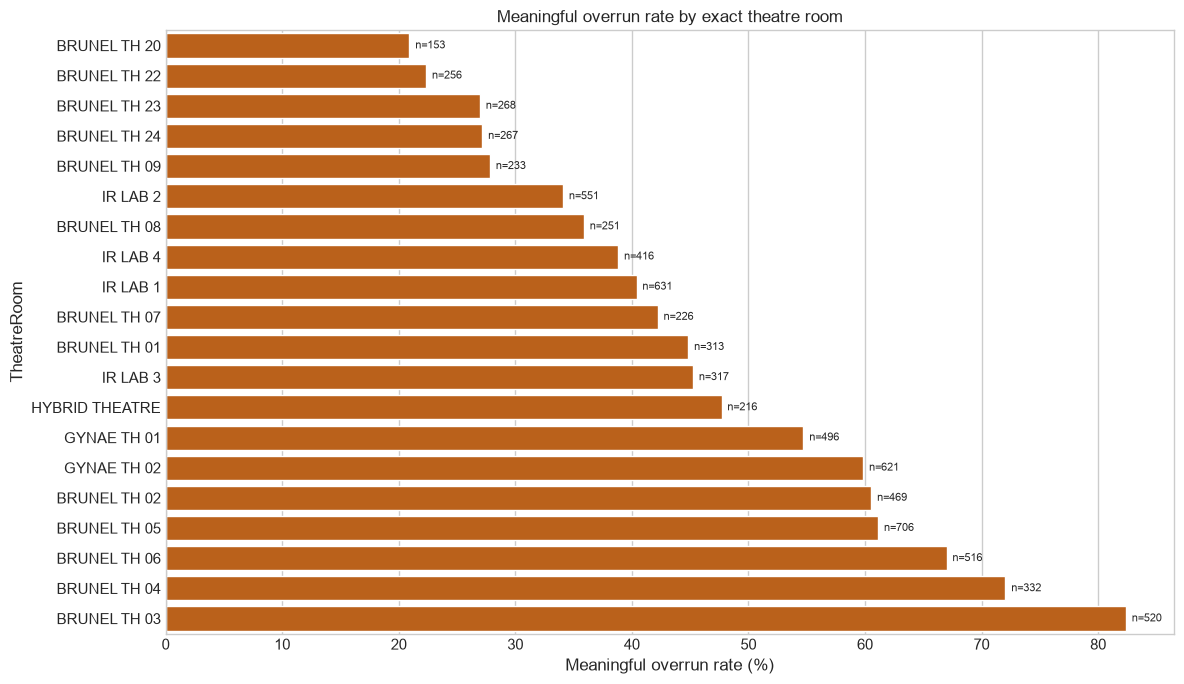

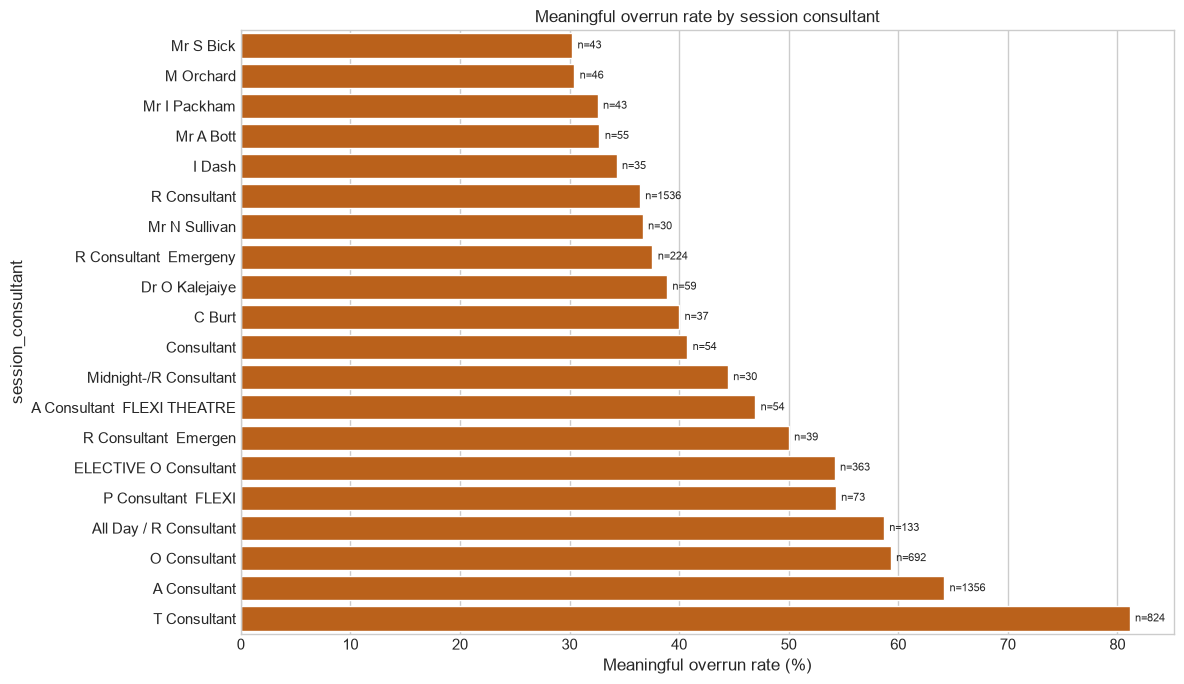

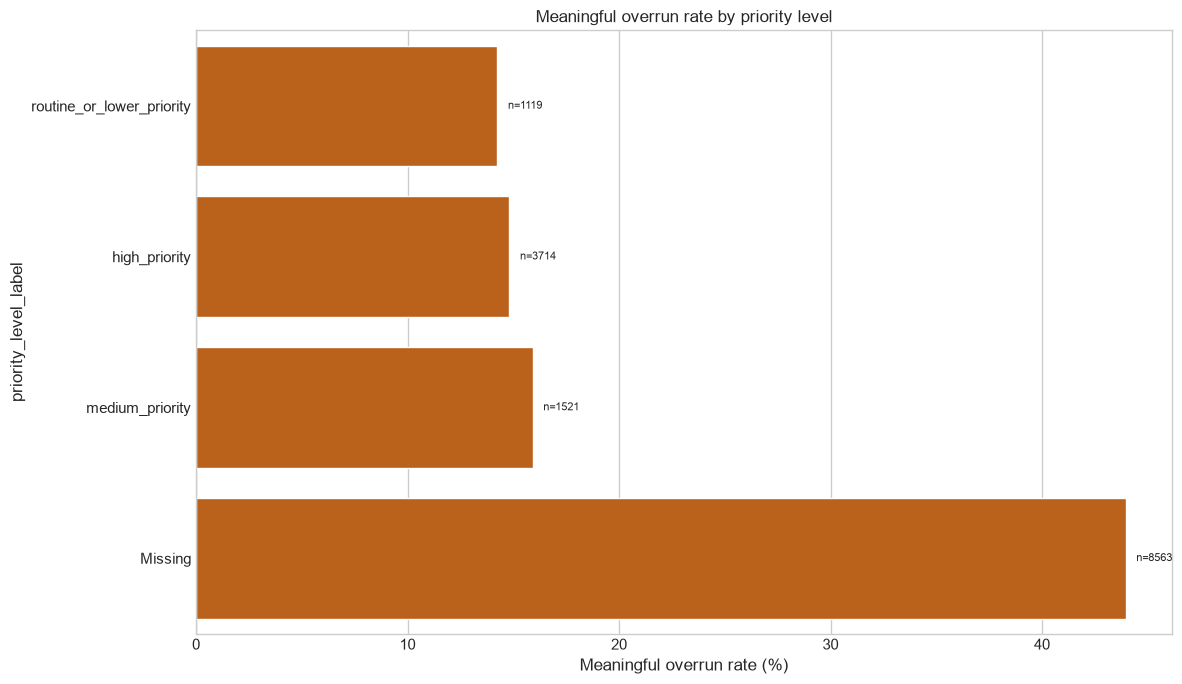

In [99]:
plot_operational_overrun_bar(
    room_overrun_summary,
    "TheatreRoom",
    "Meaningful overrun rate by exact theatre room",
)

plot_operational_overrun_bar(
    consultant_overrun_summary,
    "session_consultant",
    "Meaningful overrun rate by session consultant",
)

plot_operational_overrun_bar(
    priority_overrun_summary,
    "priority_level_label",
    "Meaningful overrun rate by priority level",
)


In [100]:
# TheatreRoom vs session_consultant: identify high-volume combinations with high meaningful overrun rate.
if {"TheatreRoom", "session_consultant"}.issubset(bottleneck_eda_df.columns):
    room_consultant_overrun = (
        bottleneck_eda_df
        .assign(
            TheatreRoom=lambda df: df["TheatreRoom"].astype("string").fillna("Missing"),
            session_consultant=lambda df: df["session_consultant"].astype("string").fillna("Missing"),
        )
        .groupby(["TheatreRoom", "session_consultant"], dropna=False)
        .agg(
            cases=(target_column, "size"),
            meaningful_overrun_rate=("meaningful_overrun_flag", "mean"),
            meaningful_underrun_rate=("meaningful_underrun_flag", "mean"),
            median_duration_error=("duration_error_mins", "median"),
            median_operation_length=(target_column, "median"),
            median_theatre_occupancy=("theatre_occupancy_mins", "median"),
            total_overrun_minutes=("overrun_minutes", "sum"),
        )
        .reset_index()
    )

    room_consultant_overrun["meaningful_overrun_rate"] = (
        room_consultant_overrun["meaningful_overrun_rate"] * 100
    ).round(2)
    room_consultant_overrun["meaningful_underrun_rate"] = (
        room_consultant_overrun["meaningful_underrun_rate"] * 100
    ).round(2)
    room_consultant_overrun = room_consultant_overrun[room_consultant_overrun["cases"] >= 20]
    room_consultant_overrun.sort_values(
        ["meaningful_overrun_rate", "cases"],
        ascending=False,
    ).head(25)


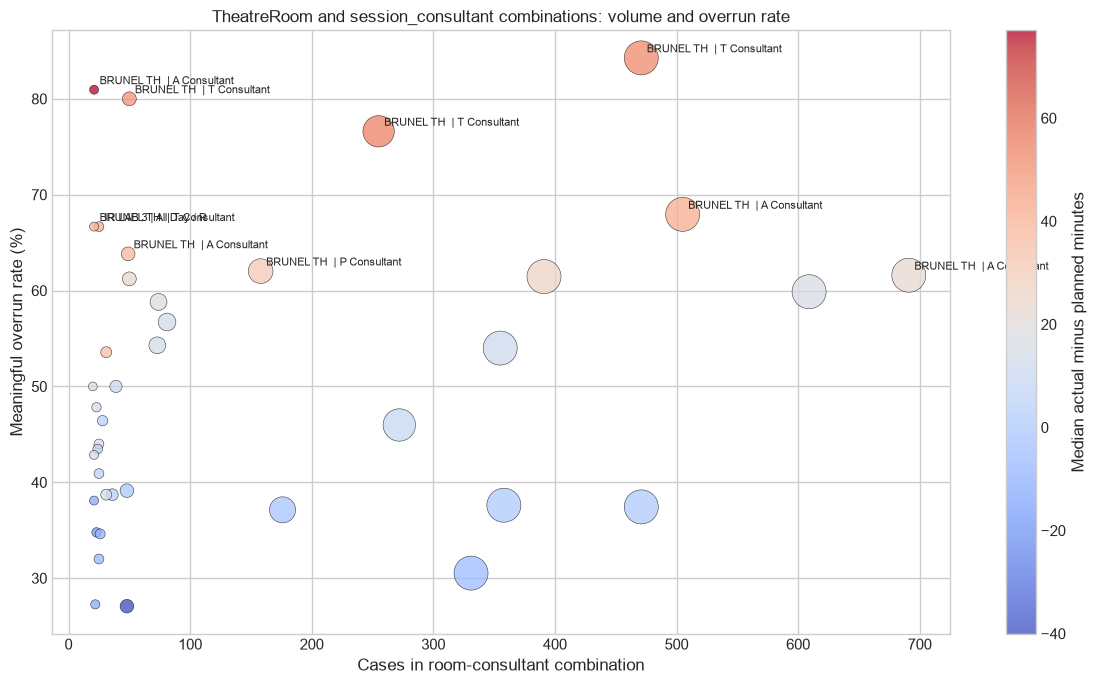

In [101]:
if "room_consultant_overrun" in globals() and not room_consultant_overrun.empty:
    plot_df = room_consultant_overrun.dropna(subset=["meaningful_overrun_rate", "median_duration_error"]).copy()
    plot_df = plot_df.sort_values(["meaningful_overrun_rate", "cases"], ascending=False).head(40)

    fig, ax = plt.subplots(figsize=(12, 7))
    marker_size = plot_df["cases"].clip(lower=20, upper=300) * 2
    scatter = ax.scatter(
        plot_df["cases"],
        plot_df["meaningful_overrun_rate"],
        s=marker_size,
        c=plot_df["median_duration_error"],
        cmap="coolwarm",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
    )

    for _, row in plot_df.head(10).iterrows():
        label = f"{str(row['TheatreRoom'])[:10]} | {str(row['session_consultant'])[:12]}"
        ax.annotate(label, (row["cases"], row["meaningful_overrun_rate"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

    ax.set_title("TheatreRoom and session_consultant combinations: volume and overrun rate")
    ax.set_xlabel("Cases in room-consultant combination")
    ax.set_ylabel("Meaningful overrun rate (%)")
    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label("Median actual minus planned minutes")
    plt.tight_layout()


In [102]:
# Use the engineered theatre-flow features to identify which process stage is linked with overruns.
flow_relationship_columns = available_columns(
    bottleneck_eda_df,
    [
        "theatre_occupancy_mins",
        "theatre_to_anaesthetic_start_mins",
        "anaesthetic_to_incision_mins",
        "incision_to_closure_mins",
        "closure_to_operation_end_mins",
        "post_operation_theatre_time_mins",
    ],
)

flow_overrun_summary = []
for column in flow_relationship_columns:
    temp = bottleneck_eda_df[[column, "duration_status"]].copy()
    temp[column] = pd.to_numeric(temp[column], errors="coerce")
    temp["duration_status"] = temp["duration_status"].astype("string").fillna("missing_duration")
    grouped = temp.groupby("duration_status")[column].agg(["count", "median", "mean", "std"]).reset_index()
    grouped.insert(0, "time_feature", column)
    flow_overrun_summary.append(grouped)

flow_overrun_summary = pd.concat(flow_overrun_summary, ignore_index=True) if flow_overrun_summary else pd.DataFrame()
flow_overrun_summary.round(2)


,time_feature,duration_status,count,median,mean,std
0,theatre_occupancy_mins,meaningful_overrun,4477,125.00,157.44,105.04
1,theatre_occupancy_mins,meaningful_underrun,6258,53.00,80.08,77.87
2,theatre_occupancy_mins,missing_duration,272,73.50,90.93,94.16
3,theatre_occupancy_mins,within_tolerance,3272,68.00,97.18,91.88
4,theatre_to_anaesthetic_start_mins,meaningful_overrun,4445,0.00,0.00,0.00
5,theatre_to_anaesthetic_start_mins,meaningful_underrun,6222,0.00,0.00,0.00
6,theatre_to_anaesthetic_start_mins,missing_duration,240,0.00,0.00,0.00
7,theatre_to_anaesthetic_start_mins,within_tolerance,3257,0.00,0.00,0.00
8,anaesthetic_to_incision_mins,meaningful_overrun,4445,32.00,31.47,14.91
9,anaesthetic_to_incision_mins,meaningful_underrun,6222,19.00,21.38,13.16


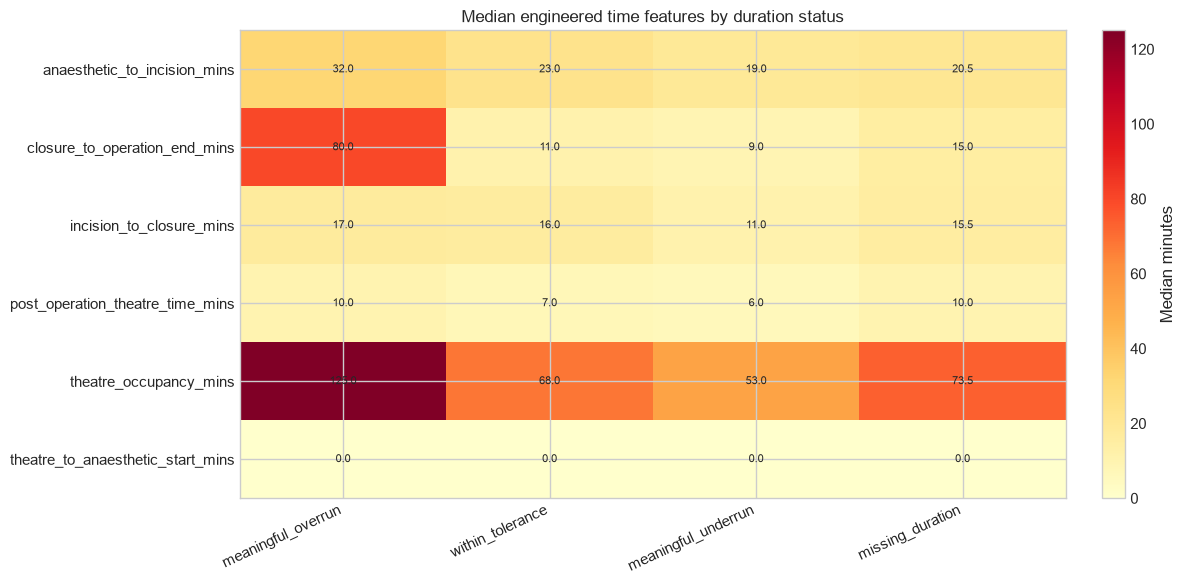

In [103]:
if not flow_overrun_summary.empty:
    flow_pivot = flow_overrun_summary.pivot_table(
        index="time_feature",
        columns="duration_status",
        values="median",
        aggfunc="first",
    ).reindex(columns=duration_status_order)

    fig, ax = plt.subplots(figsize=(12, 6))
    image = ax.imshow(flow_pivot.to_numpy(dtype=float), aspect="auto", cmap="YlOrRd")
    ax.set_title("Median engineered time features by duration status")
    ax.set_xticks(range(len(flow_pivot.columns)))
    ax.set_xticklabels(flow_pivot.columns, rotation=25, ha="right")
    ax.set_yticks(range(len(flow_pivot.index)))
    ax.set_yticklabels(flow_pivot.index)

    for row_idx in range(flow_pivot.shape[0]):
        for col_idx in range(flow_pivot.shape[1]):
            value = flow_pivot.iloc[row_idx, col_idx]
            if pd.notna(value):
                ax.text(col_idx, row_idx, f"{value:.1f}", ha="center", va="center", fontsize=8)

    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label("Median minutes")
    plt.tight_layout()


In [104]:
# Priority combined with theatre room and start time.
priority_combo_checks = [
    ("priority_level_label", "TheatreRoom"),
    ("priority_level_label", "operation_start_hour_band"),
    ("priority_level_label", "session_time_band"),
]

for left, right in priority_combo_checks:
    if left not in bottleneck_eda_df.columns or right not in bottleneck_eda_df.columns:
        continue

    temp = bottleneck_eda_df.copy()
    temp[left] = temp[left].astype("string").fillna("Missing")
    temp[right] = temp[right].astype("string").fillna("Missing")
    temp["priority_combination"] = temp[left] + " | " + temp[right]

    print(f"Priority drilldown: {left} + {right}")
    display(operational_overrun_summary(temp, "priority_combination", min_cases=20, top_n=15))


Priority drilldown: priority_level_label + TheatreRoom


,priority_combination,cases,meaningful_overrun_rate,meaningful_underrun_rate,within_tolerance_rate,median_duration_error,median_overrun_minutes,total_overrun_minutes,median_underrun_minutes,total_underrun_minutes,median_operation_length,median_theatre_occupancy,median_post_operation_time
2,Missing | BRUNEL TH 03,518,82.71,6.88,10.23,50.00,50.00,31471.00,0.00,1842.00,121.00,131.00,10.00
3,Missing | BRUNEL TH 04,330,72.50,14.37,12.73,49.00,49.00,26982.00,0.00,1924.00,138.00,151.00,10.00
5,Missing | BRUNEL TH 06,512,67.13,15.03,17.38,40.00,40.00,32367.00,0.00,2563.00,116.00,130.00,13.00
4,Missing | BRUNEL TH 05,706,61.13,17.20,21.25,22.00,22.00,29812.00,0.00,3647.00,81.00,97.00,11.00
1,Missing | BRUNEL TH 02,463,60.91,18.86,19.22,25.00,25.00,19738.00,0.00,2847.00,81.00,88.50,7.00
29,Missing | GYNAE TH 02,621,59.85,7.65,27.38,16.00,16.00,10526.00,0.00,2781.00,72.00,84.00,10.00
35,Missing | IR LAB 3,199,56.38,27.66,15.08,21.00,21.00,7390.00,0.00,1879.00,91.00,110.50,15.00
31,Missing | HYBRID THEATRE,152,55.92,28.29,15.79,23.50,23.50,10127.00,0.00,2407.00,161.00,172.00,10.00
28,Missing | GYNAE TH 01,496,54.72,6.92,36.90,12.00,12.00,8460.00,0.00,1224.00,72.00,81.00,8.00
0,Missing | BRUNEL TH 01,225,54.50,24.77,20.44,19.00,19.00,9313.00,0.00,3192.00,89.00,102.00,10.00


Priority drilldown: priority_level_label + operation_start_hour_band


,priority_combination,cases,meaningful_overrun_rate,meaningful_underrun_rate,within_tolerance_rate,median_duration_error,median_overrun_minutes,total_overrun_minutes,median_underrun_minutes,total_underrun_minutes,median_operation_length,median_theatre_occupancy,median_post_operation_time
1,Missing | 01:00-01:59,67,74.58,3.39,19.40,32.00,32.00,4243.00,0.00,88.00,92.00,104.00,12.00
0,Missing | 00:00-00:59,52,69.39,10.20,19.23,31.00,31.00,2325.00,0.00,132.00,87.00,103.50,14.00
23,Missing | 23:00-23:59,65,66.67,17.46,15.38,32.00,32.00,4286.00,0.00,1679.00,85.00,110.00,14.00
3,Missing | 03:00-03:59,39,66.67,12.12,17.95,26.00,26.00,1444.00,0.00,259.00,70.00,79.00,10.00
20,Missing | 20:00-20:59,102,60.20,21.43,17.65,20.00,20.00,4126.00,0.00,673.00,81.00,100.00,12.50
21,Missing | 21:00-21:59,111,59.22,18.45,20.72,22.00,22.00,4008.00,0.00,623.00,88.00,105.00,15.00
4,Missing | 04:00-04:59,42,58.54,17.07,23.81,20.00,20.00,1677.00,0.00,231.00,71.50,85.00,10.00
5,Missing | 05:00-05:59,38,58.33,22.22,18.42,16.50,16.50,1324.00,0.00,195.00,75.00,87.50,11.50
2,Missing | 02:00-02:59,51,57.14,28.57,13.73,19.00,19.00,3073.00,0.00,557.00,90.00,121.00,18.00
19,Missing | 19:00-19:59,115,51.38,21.10,26.09,11.00,11.00,3654.00,0.00,980.00,74.00,92.00,13.00


Priority drilldown: priority_level_label + session_time_band


,priority_combination,cases,meaningful_overrun_rate,meaningful_underrun_rate,within_tolerance_rate,median_duration_error,median_overrun_minutes,total_overrun_minutes,median_underrun_minutes,total_underrun_minutes,median_operation_length,median_theatre_occupancy,median_post_operation_time
2,Missing | Missing,6363,46.92,28.32,23.81,8.00,8.00,214575.00,0.00,89678.00,83.00,95.00,9.00
0,Missing | AM,957,38.81,32.00,28.21,3.00,3.00,19659.00,0.00,10798.00,62.00,71.00,7.00
3,Missing | PM,1211,33.51,41.62,23.78,-4.00,0.00,19726.00,4.00,17993.00,54.00,64.00,8.00
13,routine_or_lower_priority | AM,70,21.43,60.00,18.57,-20.50,0.00,656.00,20.50,1774.00,51.00,61.00,6.00
9,medium_priority | AM,387,17.36,61.40,21.19,-18.00,0.00,3067.00,18.00,7887.00,40.00,45.00,5.00
4,high_priority | AM,1198,15.97,62.27,21.62,-20.00,0.00,8171.00,20.00,28791.00,35.00,40.00,5.00
11,medium_priority | Missing,910,15.60,61.73,22.53,-25.50,0.00,8233.00,25.50,31597.00,95.00,106.00,7.00
6,high_priority | Missing,1770,15.52,63.08,21.36,-26.00,0.00,20143.00,26.00,63487.00,89.00,100.00,8.00
12,medium_priority | PM,205,14.63,66.34,19.02,-23.00,0.00,1665.00,23.00,5309.00,51.00,57.00,7.00
16,routine_or_lower_priority | PM,82,14.63,70.73,14.63,-20.50,0.00,1062.00,20.50,2197.00,75.50,89.00,8.00


**Result interpretation:** These drilldowns make the EDA more directly useful for scheduling. Exact theatre rooms and session consultants are compared using meaningful overrun rate, not only raw overrun counts, so high-volume groups are not unfairly penalised. The `TheatreRoom` by `session_consultant` view highlights combinations that may need review, but these should be interpreted with case mix and specialty context. Priority-level summaries show whether urgent or routine categories are associated with different planned-time reliability. The engineered time-feature heatmap helps identify whether meaningful overruns are linked mainly to longer core operation time, wider theatre occupancy, or post-operation theatre-flow delay.


### 10.11.6 Overrun and underrun dashboard by time and case type

This subsection looks at overrun and underrun together. This is important because scheduling problems are not only about cases that take longer than planned. A high underrun rate can also show that planned times may be too generous, which creates unused theatre capacity.

The analysis compares meaningful overrun and meaningful underrun patterns across time, theatre, procedure, anaesthetic, priority, and session factors. This gives a fairer view than raw overrun counts because it uses rates, medians, and case-volume thresholds.


In [105]:
def overrun_underrun_summary(df, category, min_cases=30, top_n=15, sort_by="meaningful_overrun_rate"):
    if category not in df.columns:
        return pd.DataFrame()

    temp = df.copy()
    temp[category] = temp[category].astype("string").fillna("Missing")

    summary = temp.groupby(category, dropna=False).agg(
        cases=(target_column, "size"),
        meaningful_overrun_rate=("meaningful_overrun_flag", "mean"),
        meaningful_underrun_rate=("meaningful_underrun_flag", "mean"),
        median_duration_error=("duration_error_mins", "median"),
        median_overrun_minutes=("overrun_minutes", "median"),
        median_underrun_minutes=("underrun_minutes", "median"),
        total_overrun_minutes=("overrun_minutes", "sum"),
        total_underrun_minutes=("underrun_minutes", "sum"),
        median_operation_length=(target_column, "median"),
        median_expected_duration=("ExpectedDurationMins", "median"),
        median_theatre_occupancy=("theatre_occupancy_mins", "median"),
    ).reset_index()

    summary["meaningful_overrun_rate"] = (summary["meaningful_overrun_rate"] * 100).round(2)
    summary["meaningful_underrun_rate"] = (summary["meaningful_underrun_rate"] * 100).round(2)
    summary = summary[summary["cases"] >= min_cases]
    return summary.sort_values([sort_by, "cases"], ascending=False).head(top_n)


def plot_overrun_underrun_rates(summary, category, title):
    if summary.empty:
        print(f"No data available for {title}")
        return

    plot_df = summary[[category, "cases", "meaningful_overrun_rate", "meaningful_underrun_rate"]].copy()
    plot_df = plot_df.sort_values("meaningful_overrun_rate", ascending=False)
    plot_long = plot_df.melt(
        id_vars=[category, "cases"],
        value_vars=["meaningful_overrun_rate", "meaningful_underrun_rate"],
        var_name="duration_direction",
        value_name="rate_pct",
    )

    fig, ax = plt.subplots(figsize=(13, 7))
    sns.barplot(
        data=plot_long,
        x="rate_pct",
        y=category,
        hue="duration_direction",
        palette={
            "meaningful_overrun_rate": highlight_color,
            "meaningful_underrun_rate": plot_color,
        },
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Cases (%)")
    ax.set_ylabel(category)
    ax.legend(title="Direction")
    plt.tight_layout()


,operation_start_hour_band,cases,meaningful_overrun_rate,meaningful_underrun_rate,median_duration_error,median_overrun_minutes,median_underrun_minutes,total_overrun_minutes,total_underrun_minutes,median_operation_length,median_expected_duration,median_theatre_occupancy
1,01:00-01:59,67,74.58,3.39,32.00,32.00,0.00,4243.00,88.00,92.00,60.00,104.00
2,02:00-02:59,51,57.14,28.57,19.00,19.00,0.00,3073.00,557.00,90.00,60.00,121.00
3,03:00-03:59,39,66.67,12.12,26.00,26.00,0.00,1444.00,259.00,70.00,60.00,79.00
4,04:00-04:59,42,58.54,17.07,20.00,20.00,0.00,1677.00,231.00,71.50,60.00,85.00
5,05:00-05:59,38,58.33,22.22,16.50,16.50,0.00,1324.00,195.00,75.00,60.00,87.50
6,06:00-06:59,40,44.74,21.05,6.00,6.00,0.00,1269.00,191.00,80.00,60.00,90.50
7,07:00-07:59,44,35.14,43.24,-5.00,0.00,5.00,734.00,761.00,71.00,90.00,89.00
8,08:00-08:59,2113,30.05,45.67,-10.00,0.00,10.00,51909.00,57286.00,100.00,90.00,112.00
9,09:00-09:59,1668,34.19,42.23,-6.00,0.00,6.00,48070.00,34303.00,71.00,60.00,80.00
10,10:00-10:59,1268,29.14,48.28,-10.00,0.00,10.00,22847.00,27239.00,61.00,60.00,70.00


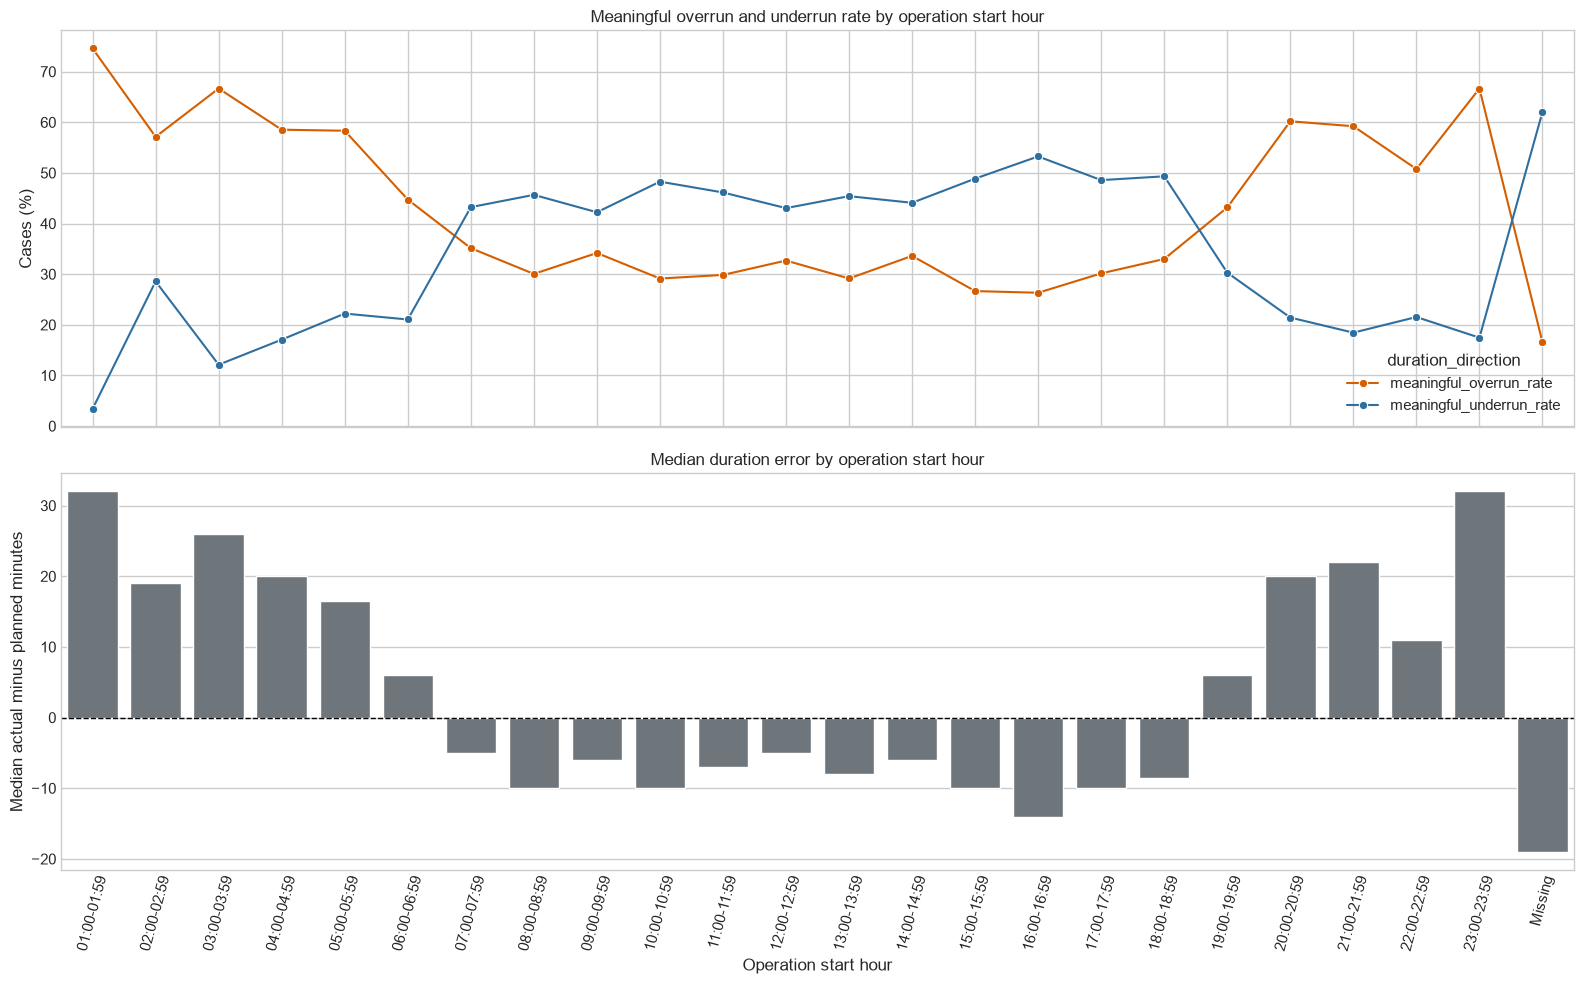

In [106]:
# Time-of-day overrun and underrun profile.
time_direction_summary = overrun_underrun_summary(
    bottleneck_eda_df,
    "operation_start_hour_band",
    min_cases=20,
    top_n=24,
    sort_by="operation_start_hour_band",
).sort_values("operation_start_hour_band")

time_direction_long = time_direction_summary.melt(
    id_vars=["operation_start_hour_band", "cases", "median_duration_error"],
    value_vars=["meaningful_overrun_rate", "meaningful_underrun_rate"],
    var_name="duration_direction",
    value_name="rate_pct",
)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

sns.lineplot(
    data=time_direction_long,
    x="operation_start_hour_band",
    y="rate_pct",
    hue="duration_direction",
    marker="o",
    palette={
        "meaningful_overrun_rate": highlight_color,
        "meaningful_underrun_rate": plot_color,
    },
    ax=axes[0],
)
axes[0].set_title("Meaningful overrun and underrun rate by operation start hour")
axes[0].set_ylabel("Cases (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=75)

sns.barplot(
    data=time_direction_summary,
    x="operation_start_hour_band",
    y="median_duration_error",
    ax=axes[1],
    color=neutral_color,
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Median duration error by operation start hour")
axes[1].set_ylabel("Median actual minus planned minutes")
axes[1].set_xlabel("Operation start hour")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()

time_direction_summary


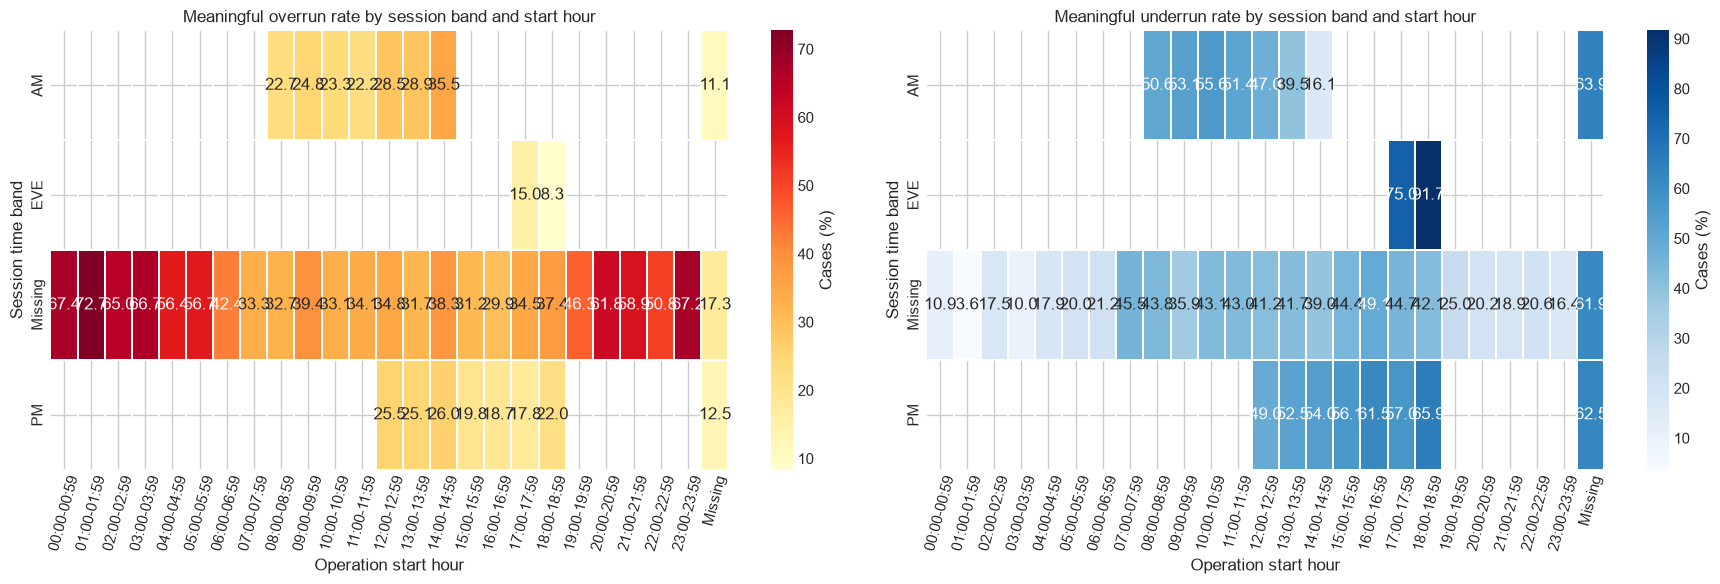

In [107]:
# Session-time and start-hour interaction: where do overrun and underrun patterns cluster?
if {"session_time_band", "operation_start_hour_band"}.issubset(bottleneck_eda_df.columns):
    time_session_df = bottleneck_eda_df.copy()
    time_session_df["session_time_band"] = time_session_df["session_time_band"].astype("string").fillna("Missing")
    time_session_df["operation_start_hour_band"] = time_session_df["operation_start_hour_band"].astype("string").fillna("Missing")

    time_session_volume = (
        time_session_df.groupby(["session_time_band", "operation_start_hour_band"])
        .size()
        .reset_index(name="cases")
    )
    valid_time_session = time_session_volume.query("cases >= 20")

    time_session_rates = (
        time_session_df.merge(valid_time_session[["session_time_band", "operation_start_hour_band"]], on=["session_time_band", "operation_start_hour_band"], how="inner")
        .groupby(["session_time_band", "operation_start_hour_band"])
        .agg(
            meaningful_overrun_rate=("meaningful_overrun_flag", "mean"),
            meaningful_underrun_rate=("meaningful_underrun_flag", "mean"),
            median_duration_error=("duration_error_mins", "median"),
        )
        .reset_index()
    )
    time_session_rates["meaningful_overrun_rate"] *= 100
    time_session_rates["meaningful_underrun_rate"] *= 100

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    for ax, metric, title, cmap in [
        (axes[0], "meaningful_overrun_rate", "Meaningful overrun rate by session band and start hour", "YlOrRd"),
        (axes[1], "meaningful_underrun_rate", "Meaningful underrun rate by session band and start hour", "Blues"),
    ]:
        table = time_session_rates.pivot_table(
            index="session_time_band",
            columns="operation_start_hour_band",
            values=metric,
            aggfunc="median",
        ).apply(pd.to_numeric, errors="coerce").astype(float)
        sns.heatmap(table, ax=ax, cmap=cmap, annot=True, fmt=".1f", linewidths=0.3, cbar_kws={"label": "Cases (%)"})
        ax.set_title(title)
        ax.set_xlabel("Operation start hour")
        ax.set_ylabel("Session time band")
        ax.tick_params(axis="x", rotation=75)

    plt.tight_layout()


In [108]:
# Case-type drilldowns: procedure, anaesthetic, priority, theatre, and session factors.
type_drilldown_columns = available_columns(
    bottleneck_eda_df,
    [
        "procedure_code_group",
        "ProcedureDescription",
        "anaesthetic_desc",
        "priority_level_label",
        "session_time_band",
        "session_list_type",
        "theatre_area",
        "TheatreRoom",
    ],
)

type_direction_summaries = {}
for column in type_drilldown_columns:
    min_cases = 50 if column == "ProcedureDescription" else 30
    top_n = 12 if column in ["ProcedureDescription", "TheatreRoom"] else 15
    summary = overrun_underrun_summary(
        bottleneck_eda_df,
        column,
        min_cases=min_cases,
        top_n=top_n,
    )
    type_direction_summaries[column] = summary
    print(f"Overrun and underrun summary by {column}")
    display(summary)


Overrun and underrun summary by procedure_code_group


,procedure_code_group,cases,meaningful_overrun_rate,meaningful_underrun_rate,median_duration_error,median_overrun_minutes,median_underrun_minutes,total_overrun_minutes,total_underrun_minutes,median_operation_length,median_expected_duration,median_theatre_occupancy
83,R3,52,84.62,3.85,25.00,25.00,0.00,1467.00,62.00,70.00,45.00,77.00
133,Y5,81,82.50,8.75,82.00,82.00,0.00,6969.00,312.00,142.00,60.00,167.00
50,L5,36,77.78,13.89,78.00,78.00,0.00,3728.00,512.00,275.50,150.00,290.00
82,R2,159,76.47,3.92,26.00,26.00,0.00,1596.00,93.00,65.00,30.00,78.00
54,L9,98,73.96,5.21,38.00,38.00,0.00,4974.00,291.00,74.00,30.00,90.50
122,X0,61,72.13,18.03,37.00,37.00,0.00,2966.00,463.00,125.00,90.00,131.50
144,Z7,184,70.49,14.21,39.00,39.00,0.00,10126.00,1536.00,120.00,60.00,127.00
87,S3,31,67.74,9.68,22.00,22.00,0.00,1360.00,106.00,95.00,60.00,106.00
114,W2,503,66.67,19.96,42.00,42.00,0.00,27457.00,5183.00,126.00,90.00,140.00
89,S5,429,66.12,19.29,30.00,30.00,0.00,21582.00,3907.00,75.00,45.00,87.00


Overrun and underrun summary by ProcedureDescription


,ProcedureDescription,cases,meaningful_overrun_rate,meaningful_underrun_rate,median_duration_error,median_overrun_minutes,median_underrun_minutes,total_overrun_minutes,total_underrun_minutes,median_operation_length,median_expected_duration,median_theatre_occupancy
681,Primary prosthetic replacement of head of femur NEC,88,96.59,3.41,75.00,75.00,0.00,6468.00,156.00,121.00,45.00,131.00
668,Primary open reduction of fracture of ankle and extramedullary fixation NEC,67,92.54,2.99,63.00,63.00,0.00,5604.00,52.00,131.00,60.00,142.00
389,Laparotomy approach NEC,68,91.04,5.97,95.00,95.00,0.00,6696.00,87.00,155.00,60.00,186.00
536,Other specified other operations on subcutaneous tissue,52,88.24,1.96,26.00,26.00,0.00,2233.00,81.00,44.00,15.00,58.50
108,Closed reduction of fracture of bone and fixation using nail or screw,128,88.10,3.17,46.00,46.00,0.00,7802.00,147.00,135.00,90.00,145.50
435,Neck of femur,56,82.14,3.57,42.00,42.00,0.00,2550.00,30.00,118.00,60.00,128.00
251,Evacuation of subdural haematoma,57,80.70,7.02,57.00,57.00,0.00,3914.00,151.00,118.00,60.00,134.00
619,Percutaneous transluminal embolisation of artery,52,70.59,9.80,40.00,40.00,0.00,2181.00,184.00,127.00,90.00,150.00
925,Unspecified exploration of other skin of other site,116,65.49,29.20,40.00,40.00,0.00,6771.00,1353.00,82.00,60.00,97.00
147,Debridement of skin NEC,215,65.42,14.95,24.50,24.50,0.00,10117.00,1048.00,69.00,30.00,76.00


Overrun and underrun summary by anaesthetic_desc


...

,session_list_type,cases,meaningful_overrun_rate,meaningful_underrun_rate,median_duration_error,median_overrun_minutes,median_underrun_minutes,total_overrun_minutes,total_underrun_minutes,median_operation_length,median_expected_duration,median_theatre_occupancy
4,Missing,3317,47.18,21.01,8.00,8.00,0.00,98917.00,27340.00,72.00,60.00,84.00
0,2SD,3775,33.29,46.16,-9.00,0.00,9.00,97866.00,82431.00,85.00,90.00,98.00
5,PM,1913,24.99,52.72,-13.00,0.00,13.00,21849.00,34982.00,45.00,60.00,54.00
2,AM,2611,24.55,51.17,-13.00,0.00,13.00,31553.00,49187.00,44.00,60.00,50.00
1,3SD,2912,24.23,57.66,-23.00,0.00,23.00,52458.00,106127.00,112.00,120.00,122.00
6,PM/EVE,320,15.36,65.83,-24.00,0.00,24.00,3981.00,11248.00,70.00,90.00,82.50
3,EVE,70,8.57,81.43,-30.00,0.00,30.00,169.00,2634.00,37.50,60.00,42.50


Overrun and underrun summary by theatre_area


,theatre_area,cases,meaningful_overrun_rate,meaningful_underrun_rate,median_duration_error,median_overrun_minutes,median_underrun_minutes,total_overrun_minutes,total_underrun_minutes,median_operation_length,median_expected_duration,median_theatre_occupancy
4,GYNAE,1132,57.27,7.22,14.00,14.00,0.00,19213.00,4007.00,72.00,60.00,82.00
5,HYBRID THEATRE,216,47.69,34.72,12.00,12.00,0.00,11536.00,5109.00,167.50,120.00,180.00
7,IR LAB,1915,39.06,34.03,1.00,1.00,0.00,37541.00,20656.00,56.00,60.00,65.00
0,BRUNEL,7846,36.39,44.60,-7.00,0.00,7.00,224683.00,195410.00,100.00,90.00,111.00
6,IF FLUORO,135,17.04,41.48,-7.00,0.00,7.00,785.00,1755.00,26.00,30.00,30.00
10,PARKVIEW,535,16.14,63.04,-19.00,0.00,19.00,3182.00,12868.00,73.00,90.00,NaN
9,PACING ROOM,160,15.48,36.77,-8.00,0.00,8.00,844.00,2369.00,39.00,45.00,46.00
2,COTSWOLD,808,11.63,54.08,-13.00,0.00,13.00,4397.00,15743.00,42.00,60.00,48.00
1,CATH LAB,524,10.17,28.41,-6.00,0.00,6.00,2094.00,4899.00,61.00,64.00,69.00
11,PLASTIC MINOR,1629,4.76,83.36,-30.00,0.00,30.00,2123.00,50889.00,30.00,60.00,35.00


Overrun and underrun summary by TheatreRoom


,TheatreRoom,cases,meaningful_overrun_rate,meaningful_underrun_rate,median_duration_error,median_overrun_minutes,median_underrun_minutes,total_overrun_minutes,total_underrun_minutes,median_operation_length,median_expected_duration,median_theatre_occupancy
2,BRUNEL TH 03,520,82.39,7.24,50.00,50.00,0.00,31471.00,1894.00,120.50,60.00,131.00
3,BRUNEL TH 04,332,72.05,14.91,48.50,48.50,0.00,26982.00,2008.00,138.00,60.00,151.00
5,BRUNEL TH 06,516,67.00,15.31,40.00,40.00,0.00,32501.00,2609.00,116.00,60.00,130.00
4,BRUNEL TH 05,706,61.13,17.20,22.00,22.00,0.00,29812.00,3647.00,81.00,60.00,97.00
1,BRUNEL TH 02,469,60.54,19.06,25.00,25.00,0.00,19832.00,2959.00,82.00,60.00,89.00
29,GYNAE TH 02,621,59.85,7.65,16.00,16.00,0.00,10526.00,2781.00,72.00,60.00,84.00
28,GYNAE TH 01,496,54.72,6.92,12.00,12.00,0.00,8460.00,1224.00,72.00,60.00,81.00
31,HYBRID THEATRE,216,47.69,34.72,12.00,12.00,0.00,11536.00,5109.00,167.50,120.00,180.00
35,IR LAB 3,317,45.25,32.79,5.00,5.00,0.00,8569.00,3818.00,78.00,60.00,90.00
0,BRUNEL TH 01,313,44.84,34.52,6.50,6.50,0.00,10323.00,5645.00,87.00,60.00,99.00


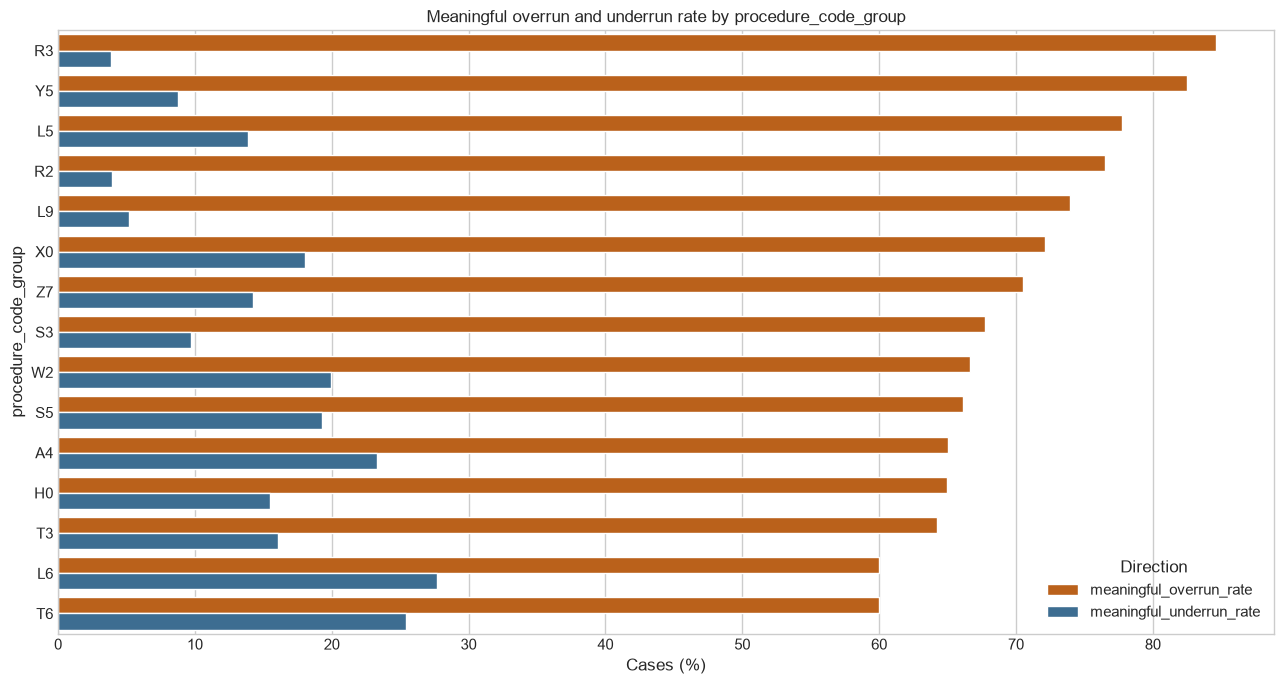

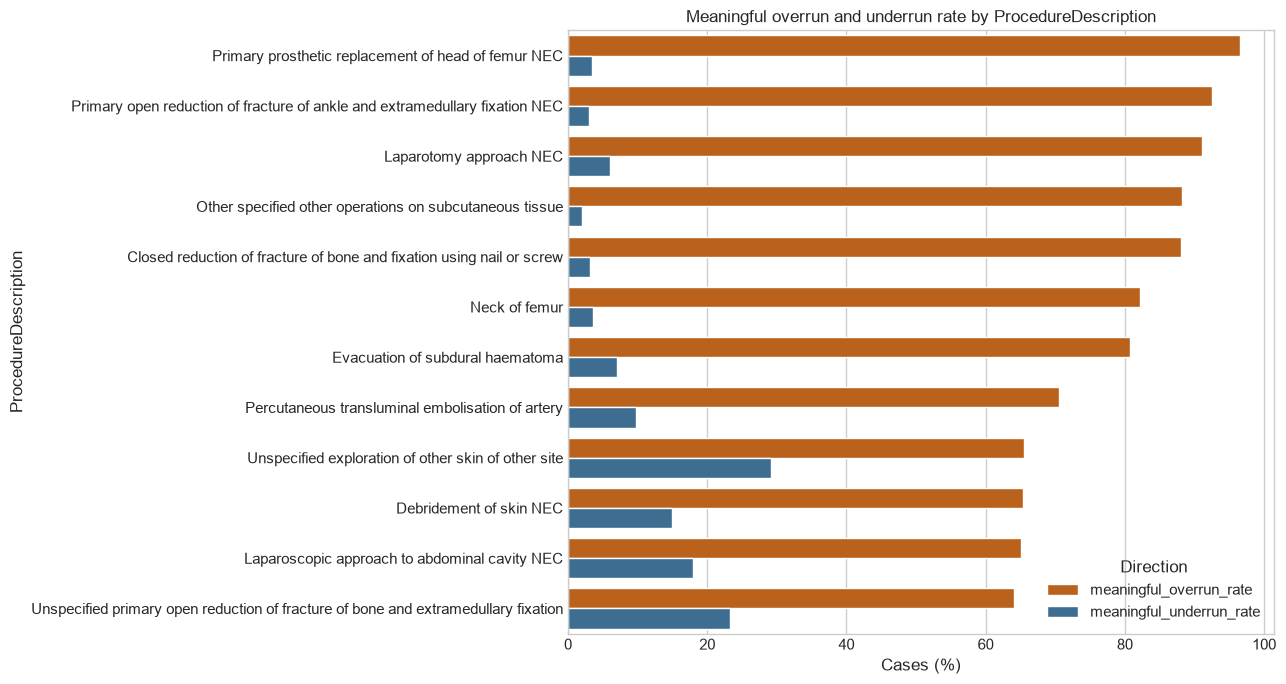

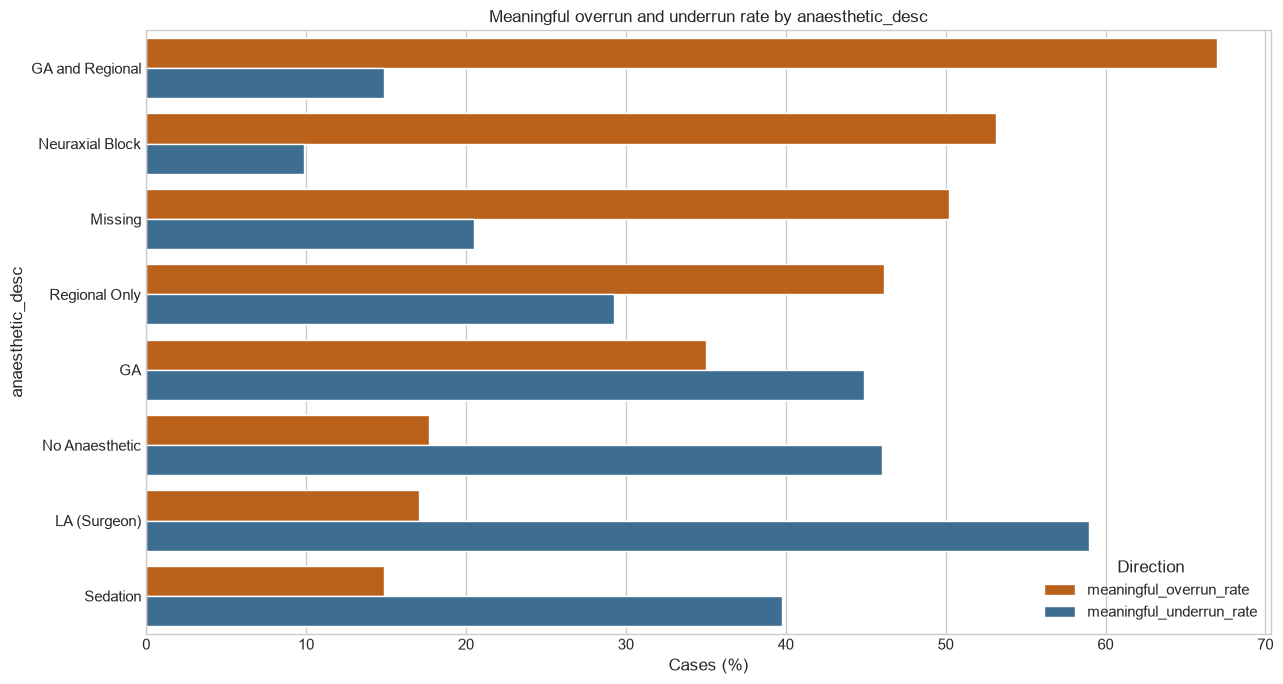

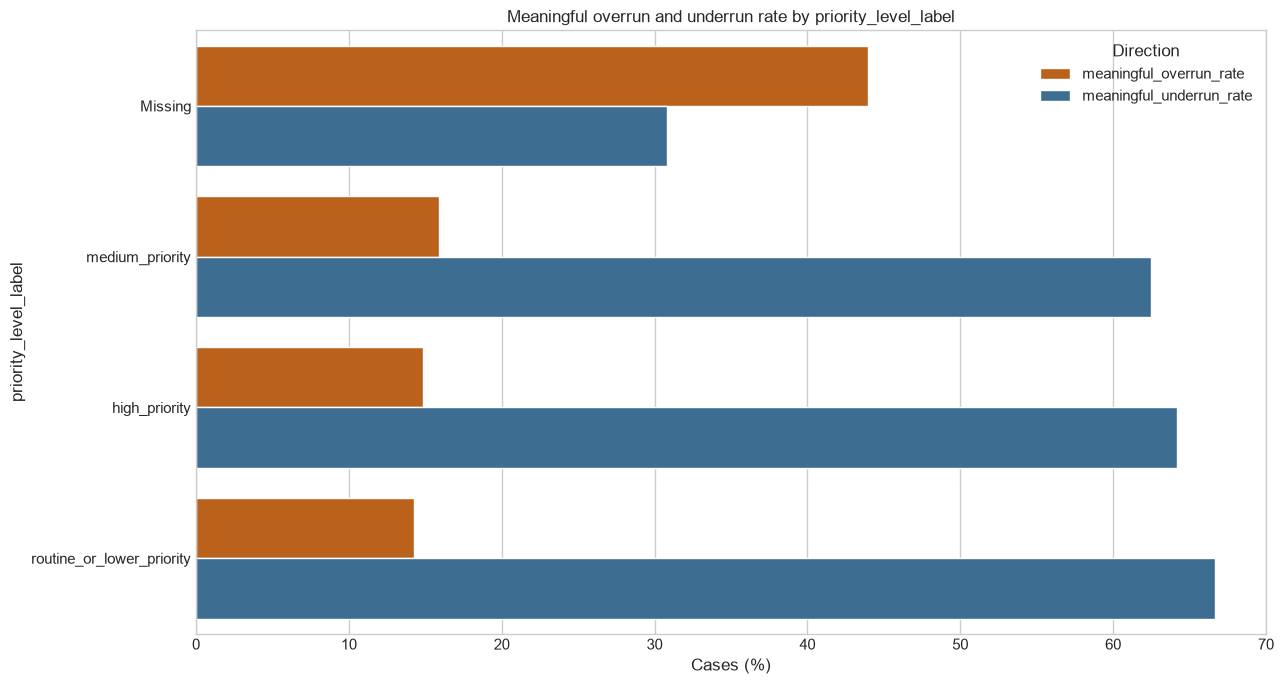

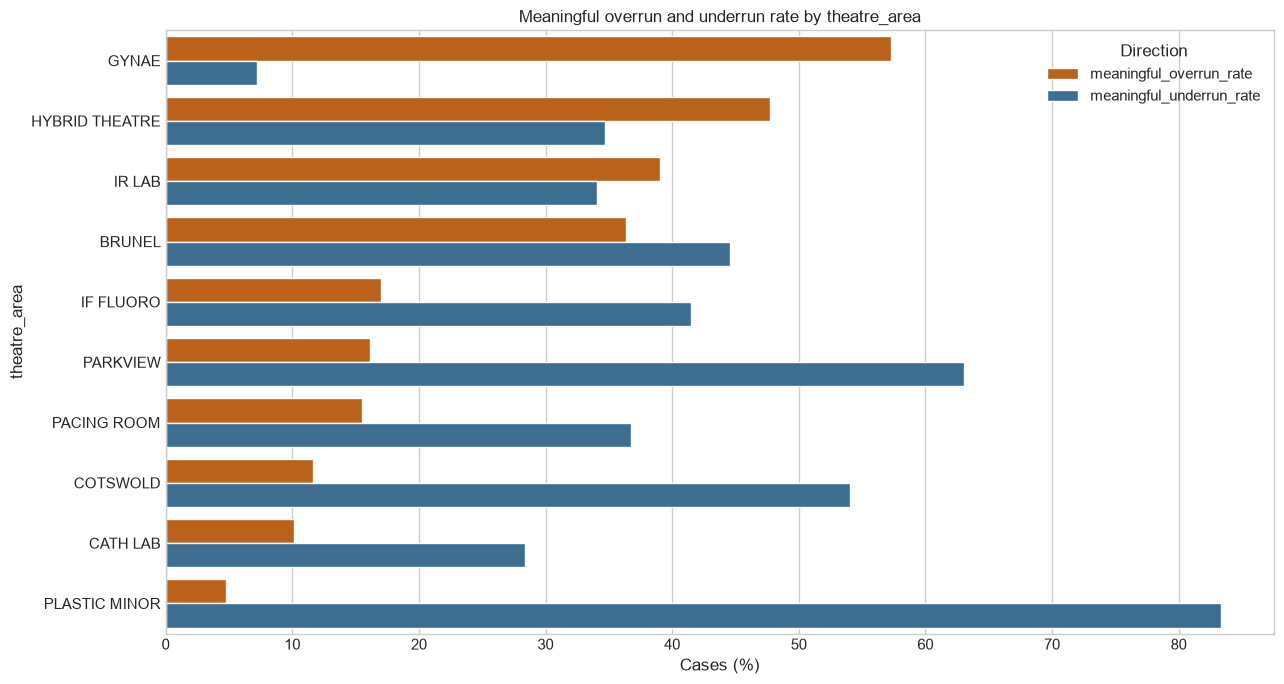

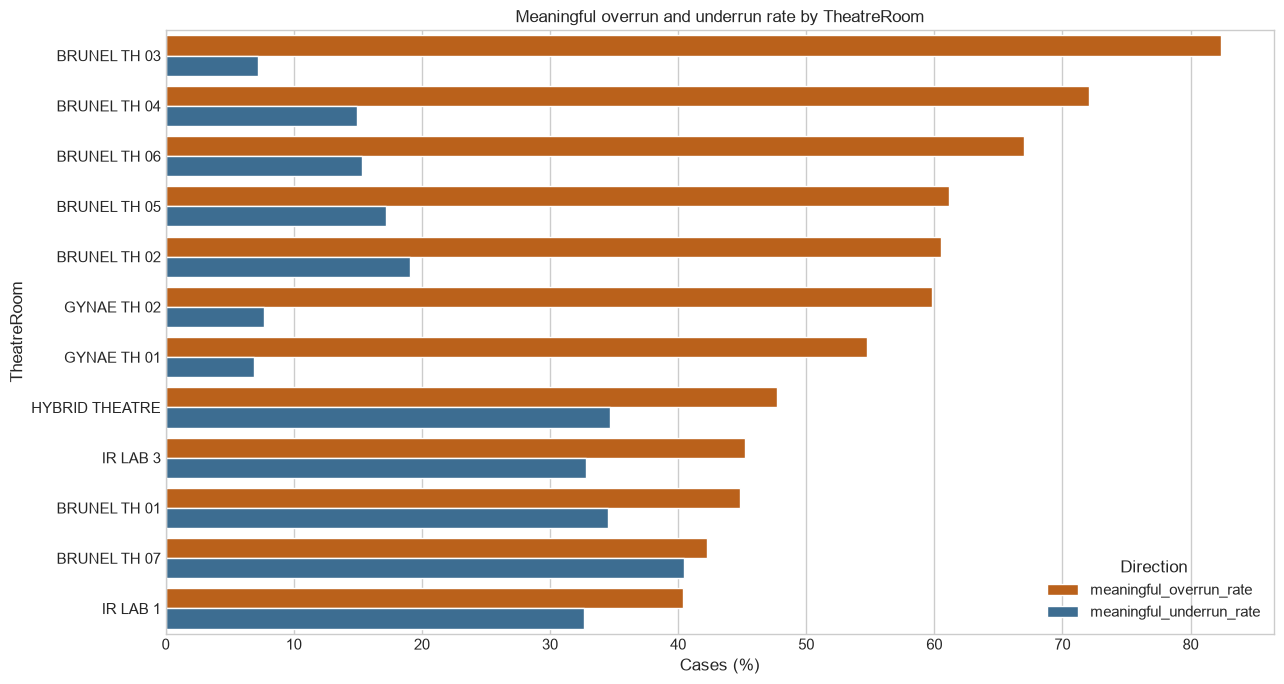

In [109]:
for column in ["procedure_code_group", "ProcedureDescription", "anaesthetic_desc", "priority_level_label", "theatre_area", "TheatreRoom"]:
    summary = type_direction_summaries.get(column, pd.DataFrame())
    if summary.empty:
        continue
    plot_overrun_underrun_rates(
        summary,
        column,
        f"Meaningful overrun and underrun rate by {column}",
    )


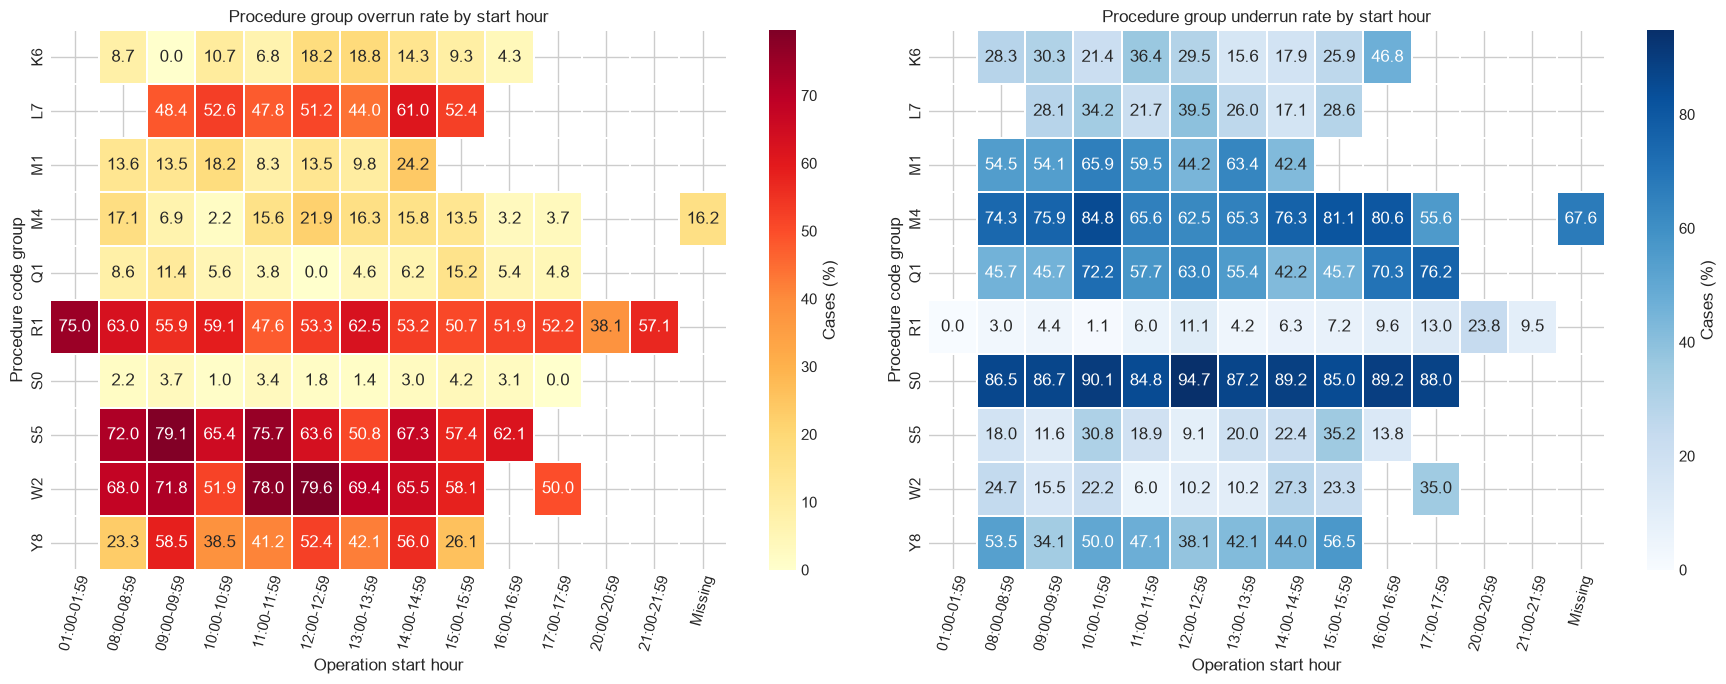

In [110]:
# Procedure type by start time: compare overrun and underrun together.
if {"procedure_code_group", "operation_start_hour_band"}.issubset(bottleneck_eda_df.columns):
    procedure_time_df = bottleneck_eda_df.copy()
    procedure_time_df["procedure_code_group"] = procedure_time_df["procedure_code_group"].astype("string").fillna("Missing")
    procedure_time_df["operation_start_hour_band"] = procedure_time_df["operation_start_hour_band"].astype("string").fillna("Missing")

    top_groups = procedure_time_df["procedure_code_group"].value_counts().head(10).index
    procedure_time_df = procedure_time_df[procedure_time_df["procedure_code_group"].isin(top_groups)]

    group_hour_counts = (
        procedure_time_df.groupby(["procedure_code_group", "operation_start_hour_band"])
        .size()
        .reset_index(name="cases")
    )
    valid_group_hour = group_hour_counts.query("cases >= 20")

    procedure_time_rates = (
        procedure_time_df.merge(valid_group_hour[["procedure_code_group", "operation_start_hour_band"]], on=["procedure_code_group", "operation_start_hour_band"], how="inner")
        .groupby(["procedure_code_group", "operation_start_hour_band"])
        .agg(
            meaningful_overrun_rate=("meaningful_overrun_flag", "mean"),
            meaningful_underrun_rate=("meaningful_underrun_flag", "mean"),
            median_duration_error=("duration_error_mins", "median"),
        )
        .reset_index()
    )
    procedure_time_rates["meaningful_overrun_rate"] *= 100
    procedure_time_rates["meaningful_underrun_rate"] *= 100

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, metric, title, cmap in [
        (axes[0], "meaningful_overrun_rate", "Procedure group overrun rate by start hour", "YlOrRd"),
        (axes[1], "meaningful_underrun_rate", "Procedure group underrun rate by start hour", "Blues"),
    ]:
        table = procedure_time_rates.pivot_table(
            index="procedure_code_group",
            columns="operation_start_hour_band",
            values=metric,
            aggfunc="median",
        ).apply(pd.to_numeric, errors="coerce").astype(float)
        sns.heatmap(table, ax=ax, cmap=cmap, annot=True, fmt=".1f", linewidths=0.3, cbar_kws={"label": "Cases (%)"})
        ax.set_title(title)
        ax.set_xlabel("Operation start hour")
        ax.set_ylabel("Procedure code group")
        ax.tick_params(axis="x", rotation=75)

    plt.tight_layout()


**Result interpretation:** This dashboard separates overrun and underrun behaviour by time and case type. Start-hour plots show whether schedule pressure changes during the day, while the session-time and procedure-time heatmaps show where overrun or underrun rates cluster. Type-level charts make it easier to compare procedure groups, exact procedures, anaesthetic types, priority groups, theatre areas, and rooms using rates rather than raw counts. Operationally, categories with high meaningful overrun rates may need longer planned durations or workflow review, while categories with high meaningful underrun rates may indicate over-estimated planned time or under-used capacity.


### 10.12 Data-quality impact checks

This part checks whether data-quality flags or missing important fields are associated with different operation lengths. This is useful because missingness or invalid time rows may not be random.





In [111]:
quality_analysis_df = analysis_df.copy()

if "PriorityLevelCode" in quality_analysis_df:
    quality_analysis_df["priority_level_missing"] = quality_analysis_df["PriorityLevelCode"].isna()
if "theat_anae_1_national_code" in quality_analysis_df:
    quality_analysis_df["anaesthetist_code_missing"] = quality_analysis_df["theat_anae_1_national_code"].isna()
if "recovery_time" in quality_analysis_df:
    quality_analysis_df["recovery_time_missing"] = quality_analysis_df["recovery_time"].isna()

quality_check_columns = available_columns(
    quality_analysis_df,
    [
        "operation_length_rule_valid",
        "time_sequence_valid",
        "priority_level_missing",
        "anaesthetist_code_missing",
        "recovery_time_missing",
    ],
)

for column in quality_check_columns:
    print(f"Operation length by {column}")
    display(duration_summary_by_category(quality_analysis_df, column, min_cases=1, top_n=10))


Operation length by operation_length_rule_valid


,operation_length_rule_valid,cases,missing_operation_length,median_operation_length,mean_operation_length,q1_operation_length,q3_operation_length,median_expected_duration,median_duration_error
0,False,639,82,71.00,78.35,44.00,103.00,90.00,-19.00
1,True,14279,0,70.00,98.71,39.00,125.00,60.00,-7.00


Operation length by time_sequence_valid


,time_sequence_valid,cases,missing_operation_length,median_operation_length,mean_operation_length,q1_operation_length,q3_operation_length,median_expected_duration,median_duration_error
1,True,14164,0,70.00,99.12,39.00,125.00,60.00,-7.00
0,False,754,82,66.00,73.30,40.00,97.00,90.00,-17.00


Operation length by priority_level_missing


,priority_level_missing,cases,missing_operation_length,median_operation_length,mean_operation_length,q1_operation_length,q3_operation_length,median_expected_duration,median_duration_error
1,True,8563,72,75.00,102.76,45.00,125.00,60.00,5.00
0,False,6355,10,60.00,91.51,32.00,122.00,90.00,-23.00


Operation length by anaesthetist_code_missing


,anaesthetist_code_missing,cases,missing_operation_length,median_operation_length,mean_operation_length,q1_operation_length,q3_operation_length,median_expected_duration,median_duration_error
0,False,9512,38,95.00,123.72,58.00,155.00,90.00,-3.00
1,True,5406,44,41.00,52.42,26.00,67.00,60.00,-13.00


Operation length by recovery_time_missing


,recovery_time_missing,cases,missing_operation_length,median_operation_length,mean_operation_length,q1_operation_length,q3_operation_length,median_expected_duration,median_duration_error
1,True,13150,77,78.00,106.53,46.00,134.00,60.00,-4.00
0,False,1768,5,29.00,34.27,21.00,43.00,60.00,-29.00


**Result interpretation:** Data-quality impact checks assess whether missing or invalid fields are associated with different operation lengths. If flagged rows show distinct duration patterns, later modelling should include sensitivity analyses or missingness indicators.


### 10.13 Outlier and overrun review

This part identifies individual cases with very long operation lengths or large overruns. These rows should be reviewed before modelling because they may be valid complex cases, data-entry issues, or cases affected by unusual operational delays.





In [112]:
review_columns = available_columns(
    analysis_df,
    [
        "TheatreRoom",
        "theatre_area",
        "theatre_room_prefix",
        "ProcedureDescription",
        "anaesthetic_desc",
        "ExpectedDurationMins",
        "operation_length_mins",
        "duration_error_mins",
        "operation_length_rule_valid",
        "time_sequence_valid",
    ],
)

longest_operations = (
    analysis_df[review_columns]
    .dropna(subset=["operation_length_mins"])
    .sort_values("operation_length_mins", ascending=False)
    .head(15)
)

longest_operations


,TheatreRoom,theatre_area,theatre_room_prefix,ProcedureDescription,anaesthetic_desc,ExpectedDurationMins,operation_length_mins,duration_error_mins,operation_length_rule_valid,time_sequence_valid
8103,BRUNEL TH 06,BRUNEL,TH,Unspecified opening of cranium,GA,150.00,1017.00,867.00,True,True
9121,BRUNEL TH 07,BRUNEL,TH,Posterior fusion of joint of cervical spine NEC,GA,180.00,971.00,791.00,True,True
5582,IR LAB 3,IR LAB,IR LAB,Open embolectomy of cerebral artery,GA,NaN,970.00,NaN,True,True
9138,BRUNEL TH 19,BRUNEL,TH,Other specified extirpation of lesion of meninges of brain,GA,690.00,922.00,232.00,True,True
11604,BRUNEL TH 10,BRUNEL,TH,Excision of lesion of tissue of cerebellum,GA,690.00,869.00,179.00,True,True
5800,BRUNEL TH 09,BRUNEL,TH,Other specified general anaesthetic,GA,929.00,853.00,-76.00,True,True
4930,BRUNEL TH 10,BRUNEL,TH,Excision of lesion of acoustic nerve (viii),GA,929.00,838.00,-91.00,True,True
2957,BRUNEL TH 12,BRUNEL,TH,Other specified excision of lesion of tissue of brain,GA,929.00,823.00,-106.00,True,True
13945,BRUNEL TH 10,BRUNEL,TH,Other specified extirpation of lesion of meninges of brain,GA,690.00,815.00,125.00,True,True
3640,BRUNEL TH 22,BRUNEL,TH,Secondary open reduction of fracture of bone and extramedullary fixation HFQ,GA,690.00,807.00,117.00,True,True


In [113]:
largest_overruns = (
    analysis_df[review_columns]
    .dropna(subset=["duration_error_mins"])
    .sort_values("duration_error_mins", ascending=False)
    .head(15)
)

largest_overruns


,TheatreRoom,theatre_area,theatre_room_prefix,ProcedureDescription,anaesthetic_desc,ExpectedDurationMins,operation_length_mins,duration_error_mins,operation_length_rule_valid,time_sequence_valid
8103,BRUNEL TH 06,BRUNEL,TH,Unspecified opening of cranium,GA,150.00,1017.00,867.00,True,True
9121,BRUNEL TH 07,BRUNEL,TH,Posterior fusion of joint of cervical spine NEC,GA,180.00,971.00,791.00,True,True
8273,GYNAE TH 01,GYNAE,TH,Elective lower uterine segment caesarean delivery,Neuraxial Block,60.00,790.00,730.00,True,True
2317,BRUNEL TH 06,BRUNEL,TH,Other specified extirpation of lesion of meninges of brain,GA,150.00,779.00,629.00,True,True
6969,BRUNEL TH 01,BRUNEL,TH,Debridement of burnt skin of head or neck,GA,60.00,680.00,620.00,True,True
9522,BRUNEL TH 04,BRUNEL,TH,Shaft of tibia NEC,GA,90.00,655.00,565.00,True,True
13037,BRUNEL TH 04,BRUNEL,TH,Left sided operation,GA and Regional,60.00,586.00,526.00,True,True
13448,BRUNEL TH 09,BRUNEL,TH,Primary total prosthetic replacement of hip joint using cement,Regional Only,120.00,642.00,522.00,True,True
13504,BRUNEL TH 09,BRUNEL,TH,Primary total prosthetic replacement of hip joint using cement,Regional Only,120.00,642.00,522.00,True,True
1151,BRUNEL TH 05,BRUNEL,TH,Right sided operation,NaN,60.00,566.00,506.00,True,True


**Result interpretation:** Outlier review separates potentially valid complex cases from possible timing or recording issues. Extreme durations should not be removed automatically; modelling should compare results with and without flagged or extreme records where appropriate.


### 10.14 Numeric correlation checks

Correlation is useful only for numeric variables. Many important predictors in this dataset are categorical, so correlation should be treated as a limited check rather than the main analysis.





In [114]:
correlation_columns = available_columns(
    analysis_df,
    [
        "ExpectedDurationMins",
        "operation_length_mins",
        "duration_error_mins",
        "overrun_minutes",
        "underrun_minutes",
        "age_at_operation",
    ],
)

correlation_matrix = analysis_df[correlation_columns].corr()
correlation_matrix


,ExpectedDurationMins,operation_length_mins,duration_error_mins,overrun_minutes,underrun_minutes,age_at_operation
ExpectedDurationMins,1.00,0.72,-0.33,-0.01,0.57,0.03
operation_length_mins,0.72,1.00,0.43,0.61,0.01,-0.01
duration_error_mins,-0.33,0.43,1.00,0.84,-0.73,-0.06
overrun_minutes,-0.01,0.61,0.84,1.00,-0.25,-0.05
underrun_minutes,0.57,0.01,-0.73,-0.25,1.00,0.05
age_at_operation,0.03,-0.01,-0.06,-0.05,0.05,1.00


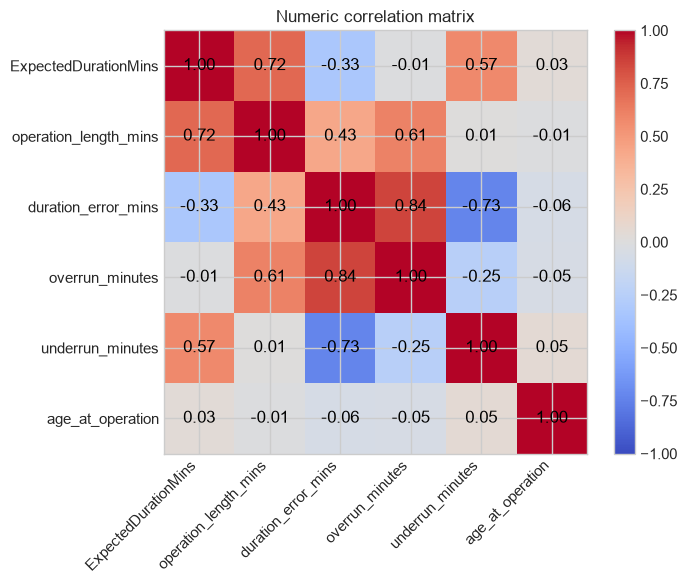

In [115]:
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_matrix.index)
ax.set_title("Numeric correlation matrix")

for row_idx, row_name in enumerate(correlation_matrix.index):
    for col_idx, col_name in enumerate(correlation_matrix.columns):
        value = correlation_matrix.loc[row_name, col_name]
        ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", color="black")

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()


**Result interpretation:** Numeric correlation is most informative for relationships between continuous variables, particularly expected and actual duration. Many key operational predictors are categorical, so grouped summaries and modelling methods that handle categories are required alongside correlation analysis.


### 10.15 EDA summary before modelling

Section 10 brings together duration, timing, theatre location, procedure, specialty, staff-code, anaesthetic, and patient-complexity variables to identify candidate bottlenecks. The strongest scheduling features for the next modelling stage are likely to include planned duration, procedure group, theatre area or room, start-hour band, anaesthetic type, ASA score, specialty, and the validated theatre-flow stage durations.

The EDA also shows why overrun analysis should not rely on simple overrun counts alone. Case volume differs by hour, room, procedure, and specialty, so meaningful overrun rate, median duration error, total occupied theatre time, and stage-level duration patterns provide a fairer operational view.

The next stage should convert the main EDA findings into modelling-ready features and target definitions. The preferred target depends on the project question: predicting `operation_length_mins` supports case-duration forecasting, predicting `theatre_occupancy_mins` supports theatre-capacity planning, and predicting `duration_status` or `meaningful_overrun_flag` supports overrun-risk classification.


**Result interpretation:** Section 10 identifies the variables and relationships most relevant for the next modelling or reporting stage. The findings should be treated as evidence for feature selection, sensitivity checks, and supervisor discussion rather than final causal conclusions.


## 11. Initial findings to investigate

- The dataset has 14,918 rows and 24 columns.
- `recovery_time` is mostly missing, so it may not be reliable unless recovery data is optional or captured elsewhere.
- `PriorityLevelCode` and `theat_anae_1_national_code` also have high missingness.
- There are a few exact duplicate rows that should be reviewed before modeling.
- Some duration fields include zeros and very large values, so outlier checks are important.
- Time columns are stored as objects, so they should be converted carefully before time-based feature engineering.
- `theatre_notes` can contain useful information, but it is free text and should be cleaned separately from structured columns.


## 12. Recommended next steps

1. Decide the project target: prediction, cleaning/reporting, delay analysis, theatre utilization, or case-duration modeling.
2. Create a cleaned copy of the dataframe instead of overwriting the raw dataframe.
3. Standardize column names to snake_case.
4. Convert categorical code columns to string/category types.
5. Convert time columns using `pd.to_timedelta` and document how overnight cases should be handled.
6. Decide how to handle missing values column by column.
7. Review duplicate rows and impossible/suspicious duration values before removing anything.


## References

Bartek, M.A., Saxena, R.C., Solomon, S., Fong, C.T., Behara, L.D., Venigandla, R., Velagapudi, K., Lang, J.D. and Nair, B.G. (2019) 'Improving operating room efficiency: machine learning approach to predict case-time duration', *Journal of the American College of Surgeons*, 229(4), pp. 346-354.e3. Available at: https://pmc.ncbi.nlm.nih.gov/articles/PMC7077507/ (Accessed: 1 August 2026).

Fixler, T. and Wright, J.G. (2013) 'Identification and use of operating room efficiency indicators: the problem of definition', *Canadian Journal of Surgery*, 56(4), pp. 224-226. Available at: https://pmc.ncbi.nlm.nih.gov/articles/PMC3728239/ (Accessed: 1 August 2026).

NHS England (2025) *Theatres, surgery and perioperative care*. Available at: https://www.england.nhs.uk/long-read/theatres-surgery-and-perioperative-care/ (Accessed: 1 August 2026).

NHS Data Dictionary (2005) *Intended Management*. Available at: https://v2.datadictionary.nhs.uk/data_dictionary/data_field_notes/i/intended_management_de.asp%40shownav%3D1.html (Accessed: 27 July 2026).

NHS Data Dictionary (2014) *Person Stated Gender Code*. Available at: https://archive.datadictionary.nhs.uk/DD%20Release%20November%202014/data_dictionary/attributes/p/person/person_stated_gender_code_de.asp%40shownav%3D1.html (Accessed: 27 July 2026).

NHS Data Dictionary (2024) *ASA Physical Status Classification System Code*. Available at: https://archive.datadictionary.nhs.uk/DD%20Release%20May%202024/attributes/asa_physical_status_classification_system_code.html (Accessed: 27 July 2026).

NHS Data Dictionary (2025) *Method of Admission*. Available at: https://v3.datadictionary.nhs.uk/data_dictionary/attributes/m/meta/method_of_admission_de.asp%40shownav%3D1.html (Accessed: 27 July 2026).

NHS England (n.d.a) *National Elective Access Policy*. Available at: https://www.england.nhs.uk/long-read/national-elective-access-policy/ (Accessed: 27 July 2026).

NHS England (n.d.b) *NHS Classifications OPCS-4*. Available at: https://isd.digital.nhs.uk/trud/users/guest/filters/0/categories/10 (Accessed: 31 July 2026).

NHS England Digital (n.d.) *Clinical classifications*. Available at: https://digital.nhs.uk/services/terminology-and-classifications/clinical-classifications (Accessed: 27 July 2026).
